# ScribblePrompt-UNet (zero-shot then fine-tuned) - FracAtlas

Single file, two parts, run top to bottom:
- **Part A**: official pretrained ScribblePrompt-UNet weights, box prompt
  only, no fine-tuning - zero-shot reference number.
- **Part B**: fine-tunes the whole model (it is a small UNet, not a
  ViT/SAM-style encoder-decoder, so full fine-tuning is cheap; the official
  repo's own configs fine-tune from the pretrained ScribblePrompt-UNet
  weights the same way), model-selects on the validation split under the
  off-center condition (matching every other model in this article), then
  re-tests the best checkpoint the same way as Part A.

Both parts use the exact same box protocol as every other model in this
article (`_center_zoom_bbox` = covering, `_center_shift_bbox` = off-center),
reused directly from `PromptSegmentationDataset` in the PGA-UNet codebase, and
report the same six metrics (Dice, IoU, Precision, Recall, HD95, CBL).

In [1]:
# -- Setup -----------------------------------------------------------------
%cd /kaggle/working
import os, gdown, torch

print("CUDA:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

# PGA-UNet repo: only needed for its dataset.py (box protocol + polygon listing).
if not os.path.exists('PGA_Unet2D'):
    !git clone --branch main --single-branch https://github.com/ThongLuc2k3/PGA_Unet2D.git
PGA_PATH = '/kaggle/working/PGA_Unet2D/Source/Prompt-Guided-XRay-Segmentation'

# ScribblePrompt repo (official halleewong implementation) + its checkpoints
if not os.path.exists('ScribblePrompt'):
    !git clone --branch main --single-branch https://github.com/halleewong/ScribblePrompt.git
%cd /kaggle/working/ScribblePrompt
!pip install -q -e .
# checkpoints/download.sh points at Dropbox *preview* links (?dl=0 -> HTML, not
# the weights) and is unreliable on Kaggle. The weights live in the model's
# HuggingFace Space under checkpoints/; pull from there, with a direct resolve
# URL and a fixed (dl=1) Dropbox link as fallbacks.
os.makedirs('checkpoints', exist_ok=True)
SP_CKPT_FILE = 'ScribblePrompt_unet_v1_nf192_res128.pt'
SP_CKPT_PATH = f'checkpoints/{SP_CKPT_FILE}'
def _sp_ckpt_ok():
    return os.path.exists(SP_CKPT_PATH) and os.path.getsize(SP_CKPT_PATH) > 5_000_000

if not _sp_ckpt_ok():
    try:
        from huggingface_hub import hf_hub_download
        import shutil
        _p = hf_hub_download(repo_id='halleewong/ScribblePrompt', repo_type='space',
                             filename=f'checkpoints/{SP_CKPT_FILE}')
        shutil.copy(_p, SP_CKPT_PATH)
    except Exception as _e:
        print('hf_hub_download (space) failed:', _e)
if not _sp_ckpt_ok():
    !wget -q -O {SP_CKPT_PATH} "https://huggingface.co/spaces/halleewong/ScribblePrompt/resolve/main/checkpoints/ScribblePrompt_unet_v1_nf192_res128.pt"
if not _sp_ckpt_ok():
    !wget -q -O {SP_CKPT_PATH} "https://www.dropbox.com/scl/fi/pnw88n05irnv5z1snlklr/ScribblePrompt_unet_v1_nf192_res128.pt?rlkey=dr8xvkf0wj2r082h1zzpcmz5o&dl=1"
assert _sp_ckpt_ok(), f'{SP_CKPT_PATH} missing or too small - see download logs above'
print('checkpoints:', os.listdir('checkpoints'), '|', os.path.getsize(SP_CKPT_PATH) // 1024, 'KB')

DATASET_ID   = '1sfMPFQvADmZLCPJC3xPyYDrblnFZ4kQv'
DATASET_ROOT = 'dataset_FracAtlas'
if not os.path.exists(f'{PGA_PATH}/{DATASET_ROOT}'):
    gdown.download(f'https://drive.google.com/uc?id={DATASET_ID}',
                   f'/kaggle/working/{DATASET_ROOT}.zip', quiet=False)
    !unzip -oq /kaggle/working/{DATASET_ROOT}.zip -d {PGA_PATH}/
TRAIN_IMG  = f'{PGA_PATH}/{DATASET_ROOT}/train/images'
TRAIN_JSON = f'{PGA_PATH}/{DATASET_ROOT}/train/annotations'
VAL_IMG    = f'{PGA_PATH}/{DATASET_ROOT}/val/images'
VAL_JSON   = f'{PGA_PATH}/{DATASET_ROOT}/val/annotations'
print(f'\nSetup complete | dataset=FracAtlas')

/kaggle/working
CUDA: True
GPU: Tesla T4
Cloning into 'PGA_Unet2D'...
remote: Enumerating objects: 4770, done.
remote: Counting objects: 100% (552/552), done.
remote: Compressing objects: 100% (171/171), done.
remote: Total 4770 (delta 415), reused 447 (delta 381), pack-reused 4218 (from 1)
Receiving objects: 100% (4770/4770), 1.22 GiB | 39.75 MiB/s, done.
Resolving deltas: 100% (2939/2939), done.
Cloning into 'ScribblePrompt'...
remote: Enumerating objects: 709, done.
remote: Counting objects: 100% (204/204), done.
remote: Compressing objects: 100% (161/161), done.
remote: Total 709 (delta 83), reused 111 (delta 38), pack-reused 505 (from 1)
Receiving objects: 100% (709/709), 37.25 MiB | 27.17 MiB/s, done.
Resolving deltas: 100% (394/394), done.
/kaggle/working/ScribblePrompt
  Preparing metadata (setup.py) ... done


checkpoints/ScribblePrompt_unet_v1_nf192(…):   0%|          | 0.00/16.0M [00:00<?, ?B/s]

checkpoints: ['README.md', 'ScribblePrompt_unet_v1_nf192_res128.pt', 'download.sh'] | 15603 KB


Downloading...
From (original): https://drive.google.com/uc?id=1sfMPFQvADmZLCPJC3xPyYDrblnFZ4kQv
From (redirected): https://drive.google.com/uc?id=1sfMPFQvADmZLCPJC3xPyYDrblnFZ4kQv&confirm=t&uuid=e8fa3e0e-6f00-4c8f-86f9-4a2bd63bd064
To: /kaggle/working/dataset_FracAtlas.zip
100%|██████████| 231M/231M [00:02<00:00, 86.2MB/s]



Setup complete | dataset=FracAtlas


In [2]:
# -- Model + shared helpers -------------------------------------------------
import sys, csv, json as _json
import numpy as np
import cv2
import torch
from scipy.ndimage import binary_erosion, distance_transform_edt

if PGA_PATH not in sys.path:
    sys.path.insert(0, PGA_PATH)
from dataset import PromptSegmentationDataset

from scribbleprompt import ScribblePromptUNet

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
DS_NAME = 'FracAtlas'
SP_SIZE = 128   # native ScribblePrompt-UNet resolution
TEST_IMG  = f'{PGA_PATH}/{DATASET_ROOT}/test/images'
TEST_JSON = f'{PGA_PATH}/{DATASET_ROOT}/test/annotations'
RESULT_DIR = f'{PGA_PATH}/results'
os.makedirs(RESULT_DIR, exist_ok=True)

# ScribblePromptUNet is a thin wrapper, NOT an nn.Module: its .to() returns None
# and .train/.eval/.parameters/.state_dict live on sp_model.model. Pass the device
# to the constructor instead of calling .to().
sp_model = ScribblePromptUNet(device=DEVICE)
sp_model.model.eval()

box_ds = PromptSegmentationDataset(TEST_IMG, TEST_JSON, is_train=False, prompt_mode='center_zoom')
print(f'{DS_NAME}: {len(box_ds.all_samples)} (image, polygon) test samples')

def resize_and_pad(arr, size, interp, pad=0):
    h, w = arr.shape[:2]
    sc = min(size / w, size / h)
    nw, nh = max(1, round(w * sc)), max(1, round(h * sc))
    r = cv2.resize(arr, (nw, nh), interpolation=interp)
    out = np.full((size, size), pad, dtype=r.dtype)
    pl, pt = (size - nw) // 2, (size - nh) // 2
    out[pt:pt + nh, pl:pl + nw] = r
    return out, sc, pl, pt, nw, nh

@torch.no_grad()
def scribbleprompt_predict_prob(img_gray, box_xyxy, H, W):
    # img_gray: HxW uint8 at ORIGINAL resolution. box_xyxy: [x0,y0,x1,y1] in
    # ORIGINAL pixel coordinates. Returns a float32 probability map at (H, W).
    canvas, sc, pl, pt, nw, nh = resize_and_pad(img_gray, SP_SIZE, cv2.INTER_LINEAR, 0)
    canvas = canvas.astype(np.float32)
    canvas = (canvas - canvas.min()) / np.clip(canvas.max() - canvas.min(), 1e-8, None)
    img_t = torch.from_numpy(canvas).float().unsqueeze(0).unsqueeze(0).to(DEVICE)

    x0, y0, x1, y1 = box_xyxy
    box_128 = [x0 * sc + pl, y0 * sc + pt, x1 * sc + pl, y1 * sc + pt]
    box_t = torch.as_tensor([[box_128]], dtype=torch.float32, device=DEVICE)   # (B=1, n=1, 4)

    out = sp_model.predict(img_t, None, None, None, box_t, None)   # (1, 1, 128, 128)
    prob_128 = out.squeeze().float().cpu().numpy()

    # Undo pad+resize: crop the valid (non-padded) region, then resize back to (H, W).
    crop = prob_128[pt:pt + nh, pl:pl + nw]
    prob_full = cv2.resize(crop, (W, H), interpolation=cv2.INTER_LINEAR)
    return prob_full

# -- Metrics: identical formulas to the rest of the article --
def calc_hd95(pred, gt):
    p, g = pred.astype(bool), gt.astype(bool)
    if not p.any() and not g.any():
        return 0.0
    S = max(pred.shape)
    if not p.any() or not g.any():
        return float(S)
    pe = p ^ binary_erosion(p); ge = g ^ binary_erosion(g)
    d1 = distance_transform_edt(~ge)[pe]; d2 = distance_transform_edt(~pe)[ge]
    return float(S) if not len(d1) or not len(d2) else float(max(np.percentile(d1, 95), np.percentile(d2, 95)))

def calc_metrics_img(pred_bin, gt_bin, eps=1e-6):
    pm, gm = pred_bin.astype(np.float32), gt_bin.astype(np.float32)
    tp = (pm * gm).sum(); fp = (pm * (1 - gm)).sum(); fn = ((1 - pm) * gm).sum()
    hd95 = calc_hd95(pm, gm)
    if gm.sum() == 0 or pm.sum() == 0:
        cbl = 0.0
    else:
        ys, xs = np.where(gm > 0.5); yp, xp = np.where(pm > 0.5)
        diag = np.sqrt((ys.max() - ys.min()) ** 2 + (xs.max() - xs.min()) ** 2) + eps
        cbl = float(np.clip(1. - np.sqrt((xp.mean() - xs.mean()) ** 2 + (yp.mean() - ys.mean()) ** 2) / diag, 0, 1))
    return dict(dice=float((2*tp+eps)/(2*tp+fp+fn+eps)), iou=float((tp+eps)/(tp+fp+fn+eps)),
                precision=float(tp/(tp+fp+eps)), recall=float(tp/(tp+fn+eps)), hd95=hd95, cbl=cbl)

print('helpers ready | device', DEVICE)
def run_test(tag):
    # Shared by Part A (zero-shot) and Part B (post-fine-tune): uses
    # sp_model's LIVE weights, so this automatically reflects whatever
    # fine-tuning Part B has done by the time it is called a second time.
    by_image = {}
    names = sorted(set(n for n, _ in box_ds.all_samples))
    for n_done, img_name in enumerate(names):
        base = os.path.splitext(img_name)[0]
        img_gray = cv2.imread(os.path.join(TEST_IMG, img_name), cv2.IMREAD_GRAYSCALE)
        H, W = img_gray.shape
        with open(os.path.join(TEST_JSON, base + '.json'), encoding='utf-8') as f:
            data = _json.load(f)
        pred_zoom  = np.zeros((H, W), dtype=np.float32)
        pred_shift = np.zeros((H, W), dtype=np.float32)
        gt_union   = np.zeros((H, W), dtype=np.uint8)
        poly_idxs = [i for i, s in enumerate(data.get('shapes', [])) if s.get('shape_type') == 'polygon']
        for shape_idx in poly_idxs:
            points = np.array(data['shapes'][shape_idx]['points'])
            cv2.fillPoly(gt_union, [points.astype(np.int32)], 1)
            x_min, y_min = points.min(axis=0)
            x_max, y_max = points.max(axis=0)
            sample_idx = box_ds.all_samples.index((img_name, shape_idx))
            bz = box_ds._center_zoom_bbox(x_min, x_max, y_min, y_max, H, W)
            bs = box_ds._center_shift_bbox(x_min, x_max, y_min, y_max, H, W, seed_idx=sample_idx)
            box_zoom  = [bz[0], bz[2], bz[1], bz[3]]
            box_shift = [bs[0], bs[2], bs[1], bs[3]]
            prob_zoom  = scribbleprompt_predict_prob(img_gray, box_zoom, H, W)
            prob_shift = scribbleprompt_predict_prob(img_gray, box_shift, H, W)
            pred_zoom  = np.maximum(pred_zoom, prob_zoom)
            pred_shift = np.maximum(pred_shift, prob_shift)
        by_image[img_name] = dict(pred_zoom=pred_zoom, pred_shift=pred_shift, gt=gt_union)
        if (n_done + 1) % 25 == 0:
            print(f'  {n_done + 1}/{len(names)} images')
    rows = []
    for mode, key in [('covering', 'pred_zoom'), ('off-center', 'pred_shift')]:
        per_image = []
        for img_name, rec in by_image.items():
            pred_bin = (rec[key] > 0.5).astype(np.uint8)
            m = calc_metrics_img(pred_bin, rec['gt'])
            m['image'] = img_name
            per_image.append(m)
        agg = {k: float(np.mean([r[k] for r in per_image])) for k in ('dice', 'iou', 'precision', 'recall', 'hd95', 'cbl')}
        rows.append(dict(dataset=DS_NAME, model=f'ScribblePrompt-UNet ({tag})', prompt=mode, **agg))
        with open(f'{RESULT_DIR}/scribbleprompt_{tag.replace(chr(45),chr(95))}_{DS_NAME.lower()}_{mode.replace(chr(45),chr(95))}_per_image.csv',
                  'w', newline='') as f:
            w = csv.DictWriter(f, fieldnames=list(per_image[0].keys())); w.writeheader(); w.writerows(per_image)
    print(f'\n{DS_NAME}: ScribblePrompt-UNet {tag}, image-level merged\n')
    print(f'{"prompt":<12}{"Dice":>8}{"IoU":>8}{"Prec":>8}{"Recall":>8}{"HD95":>8}{"CBL":>8}')
    print('-' * 60)
    for r in rows:
        print(f'{r["prompt"]:<12}{r["dice"]:>8.3f}{r["iou"]:>8.3f}{r["precision"]:>8.3f}'
              f'{r["recall"]:>8.3f}{r["hd95"]:>8.1f}{r["cbl"]:>8.3f}')
    with open(f'{RESULT_DIR}/scribbleprompt_{tag.replace(chr(45),chr(95))}_{DS_NAME.lower()}_summary.csv', 'w', newline='') as f:
        w = csv.DictWriter(f, fieldnames=list(rows[0].keys())); w.writeheader(); w.writerows(rows)
    return rows, by_image

# -- Qualitative visualization: same 5-column style as
# Finetune_SAMMed2D_test_robust.ipynb (Input / Prompt / Prediction / GT / TP-FP-FN),
# 10 shared stems, one PNG + one export_qualitative_rows call per stem.
def visualize_qualitative(by_image_vis, img_dir, box_ds_vis, model_label, prefix_tag):
    import sys as _sys
    from pathlib import Path as _Path
    import matplotlib.pyplot as plt
    from matplotlib.patches import Rectangle
    if str(_Path(PGA_PATH)) not in _sys.path:
        _sys.path.insert(0, str(_Path(PGA_PATH)))
    from qualitative_visualization import export_qualitative_rows, select_shared_stems

    modes = [('covering', 'pred_zoom', 'limegreen'), ('off-center', 'pred_shift', 'tomato')]
    selection_records = [dict(img_name=n) for n in by_image_vis.keys()]
    vis_images = select_shared_stems(selection_records, n_multi=5, n_single=5)

    for vis_name in vis_images:
        if vis_name not in by_image_vis:
            continue
        rec = by_image_vis[vis_name]
        img_gray = cv2.imread(os.path.join(img_dir, vis_name), cv2.IMREAD_GRAYSCALE)
        H, W = img_gray.shape
        rgb = cv2.cvtColor(img_gray, cv2.COLOR_GRAY2RGB)
        gt = rec['gt']
        ys, xs = np.where(gt > 0)
        gt_ov = rgb.copy()
        gt_ov[gt > 0] = np.clip(rgb[gt > 0] * 0.4 + np.array([0, 200, 0]) * 0.6, 0, 255)

        fig, axes = plt.subplots(len(modes), 5, figsize=(20, 4 * len(modes)))
        fig.suptitle(f'{model_label}: {vis_name}', fontsize=13, fontweight='bold', y=1.01)
        mode_records = []
        for row, (mode, key, color) in enumerate(modes):
            pred = (rec[key] > 0.5).astype(np.uint8)   # rec[key] is a float prob map; threshold before overlays
            pr_ov = rgb.copy()
            pr_ov[pred > 0] = np.clip(rgb[pred > 0] * 0.4 + np.array([220, 60, 60]) * 0.6, 0, 255)
            diff = rgb.copy()
            diff[gt > 0] = [0, 200, 0]
            diff[pred > 0] = [200, 60, 60]
            diff[(gt > 0) & (pred > 0)] = [220, 200, 0]

            axes[row, 0].imshow(img_gray, cmap='gray')
            axes[row, 0].set_ylabel(mode, fontsize=11, fontweight='bold', color=color,
                                    rotation=0, labelpad=65, va='center')
            axes[row, 1].imshow(img_gray, cmap='gray')
            if len(xs) > 0:
                x0, x1, y0, y1 = xs.min(), xs.max(), ys.min(), ys.max()
                if mode == 'covering':
                    bx0, bx1, by0, by1 = box_ds_vis._center_zoom_bbox(x0, x1, y0, y1, H, W)
                else:
                    bx0, bx1, by0, by1 = box_ds_vis._center_shift_bbox(x0, x1, y0, y1, H, W, seed_idx=row)
                axes[row, 1].add_patch(Rectangle((bx0, by0), bx1 - bx0, by1 - by0,
                                                  linewidth=2.5, edgecolor=color, facecolor='none'))
            axes[row, 2].imshow(pr_ov)
            axes[row, 3].imshow(gt_ov)
            axes[row, 4].imshow(diff)
            mode_records.append(dict(img_name=f'{vis_name}_{mode}', gt=gt.copy(), pred=pred.copy()))
            for ax in axes[row]:
                ax.axis('off')

        plt.tight_layout()
        out = f'{prefix_tag}_{os.path.splitext(vis_name)[0]}.png'
        plt.savefig(out, dpi=120, bbox_inches='tight')
        export_qualitative_rows(fig, axes, mode_records, prefix=f'{prefix_tag}_{vis_name}')
        print(f'saved {out}')


FracAtlas: 92 (image, polygon) test samples
helpers ready | device cuda


## Part A - zero-shot test (no fine-tuning)

Official pretrained weights as downloaded, box prompt only, both prompt
conditions, image-level merged.

  25/72 images
  50/72 images

FracAtlas: ScribblePrompt-UNet zero-shot, image-level merged

prompt          Dice     IoU    Prec  Recall    HD95     CBL
------------------------------------------------------------
covering       0.432   0.290   0.401   0.557    34.2   0.832
off-center     0.431   0.290   0.391   0.559    34.0   0.803


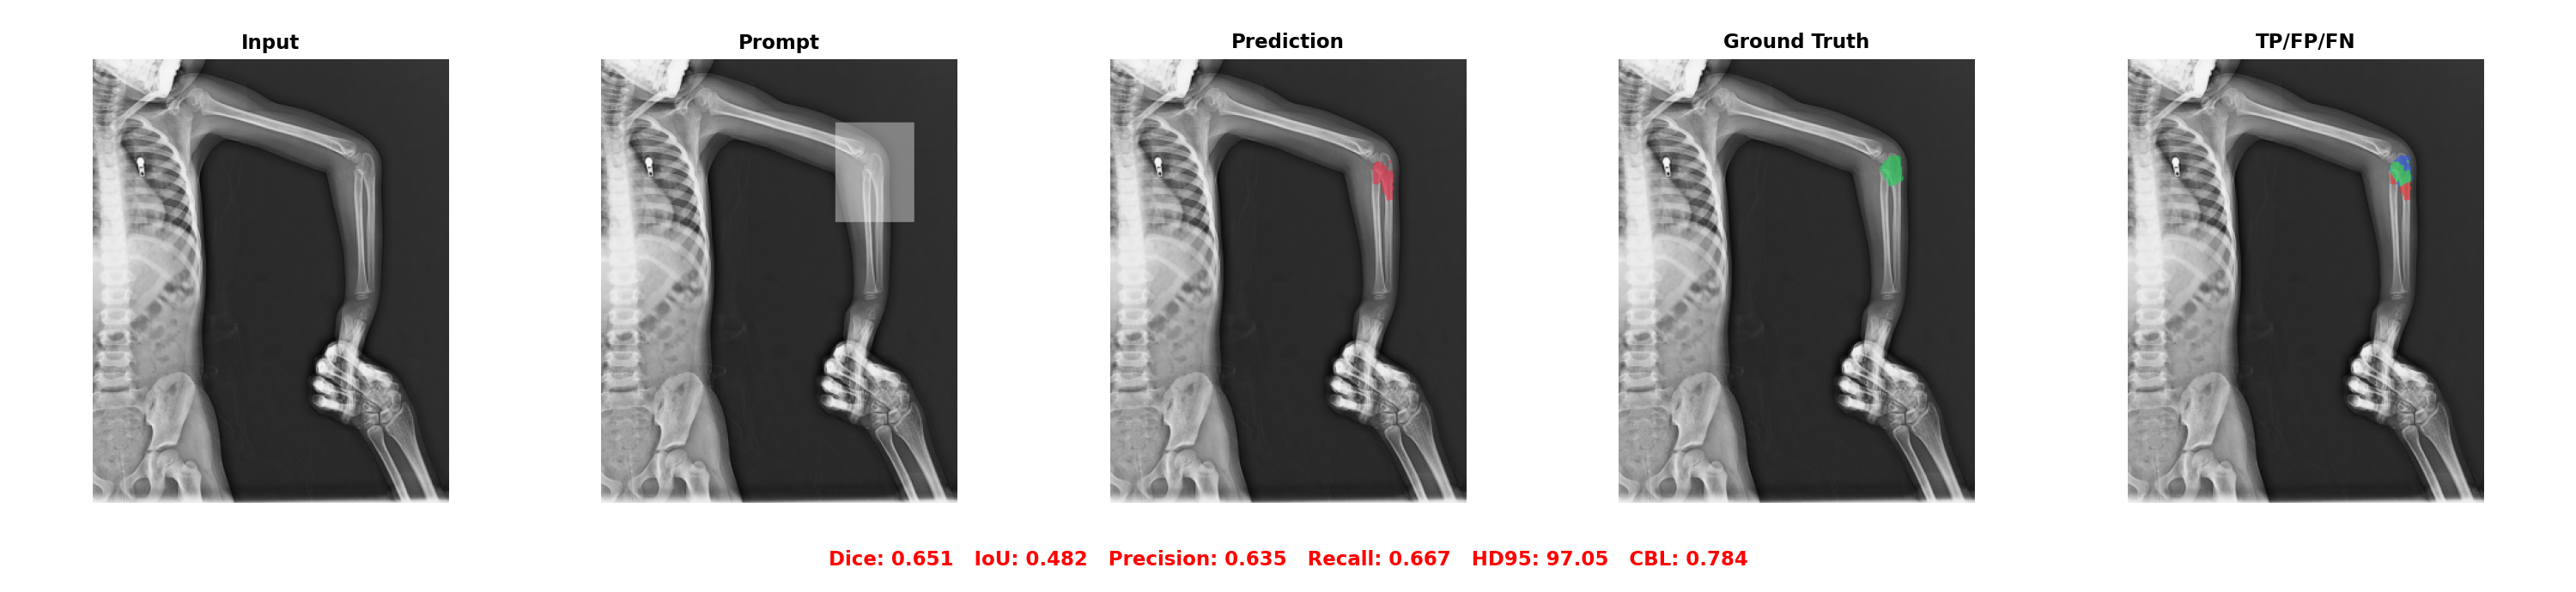

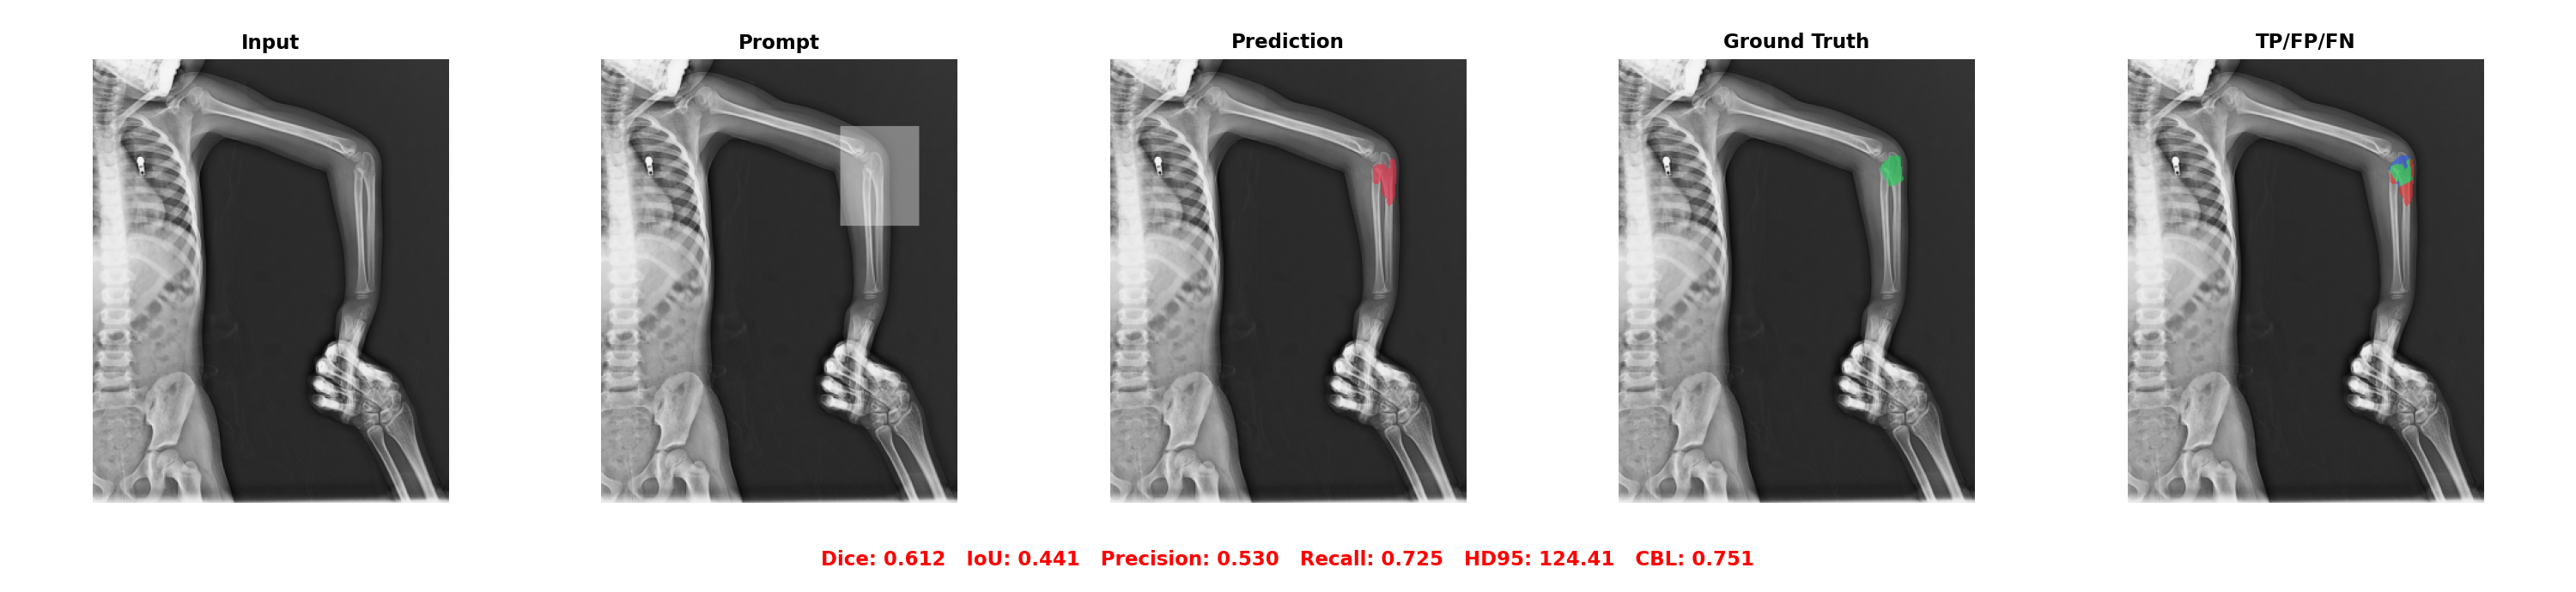

saved scribbleprompt_zeroshot_fracatlas_IMG0000144.png


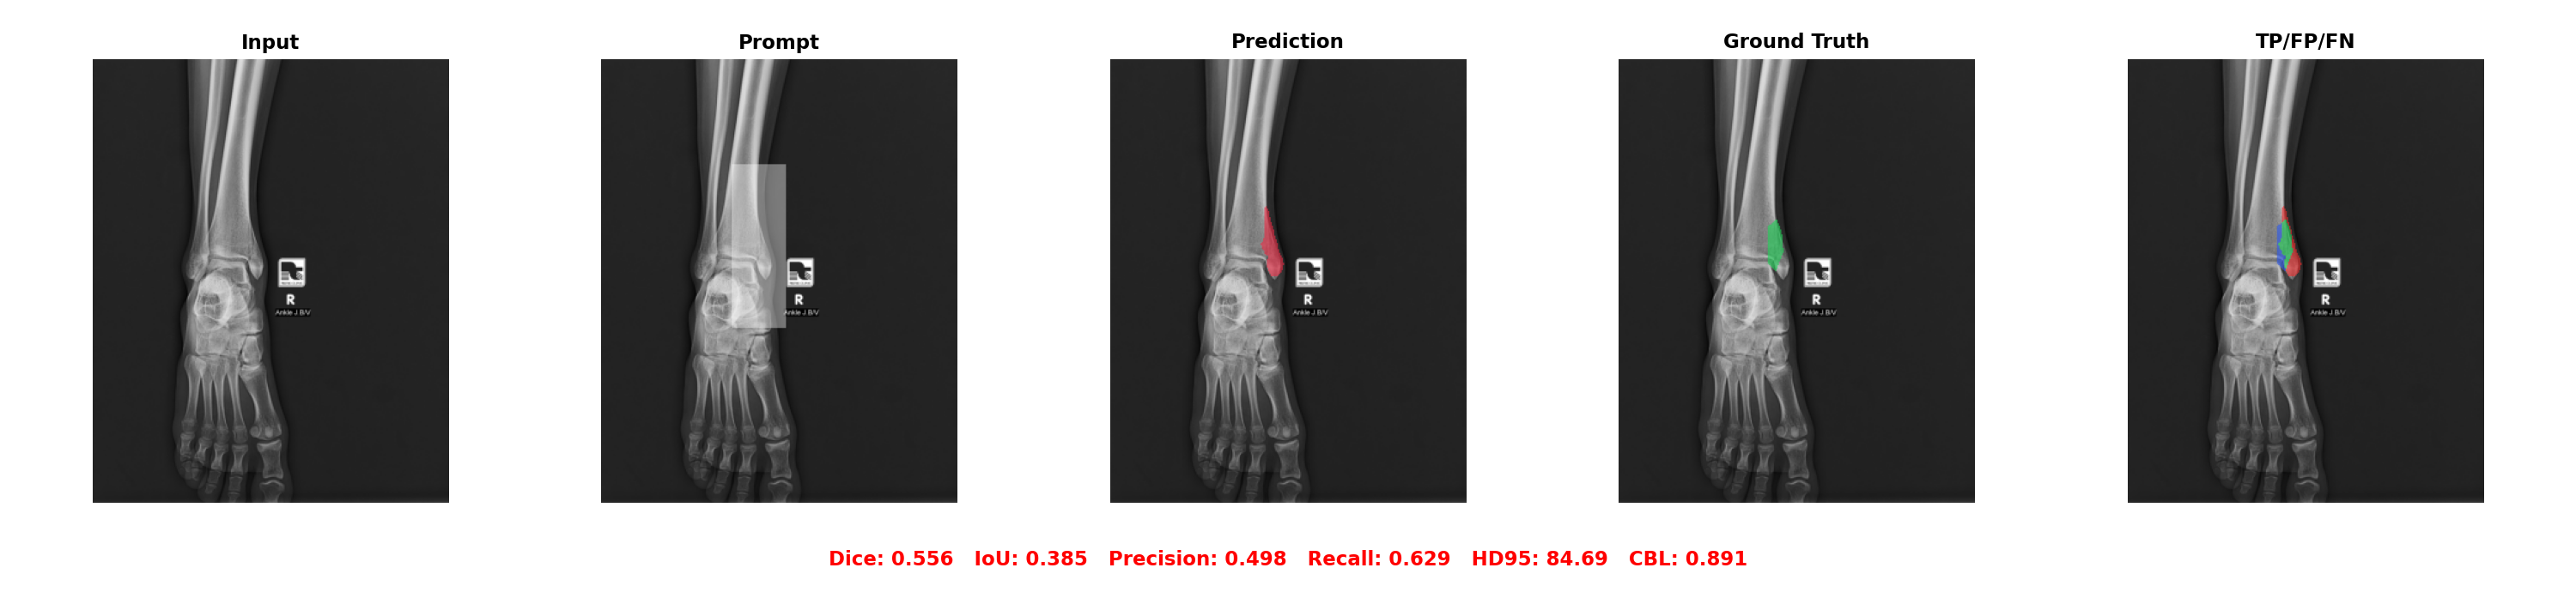

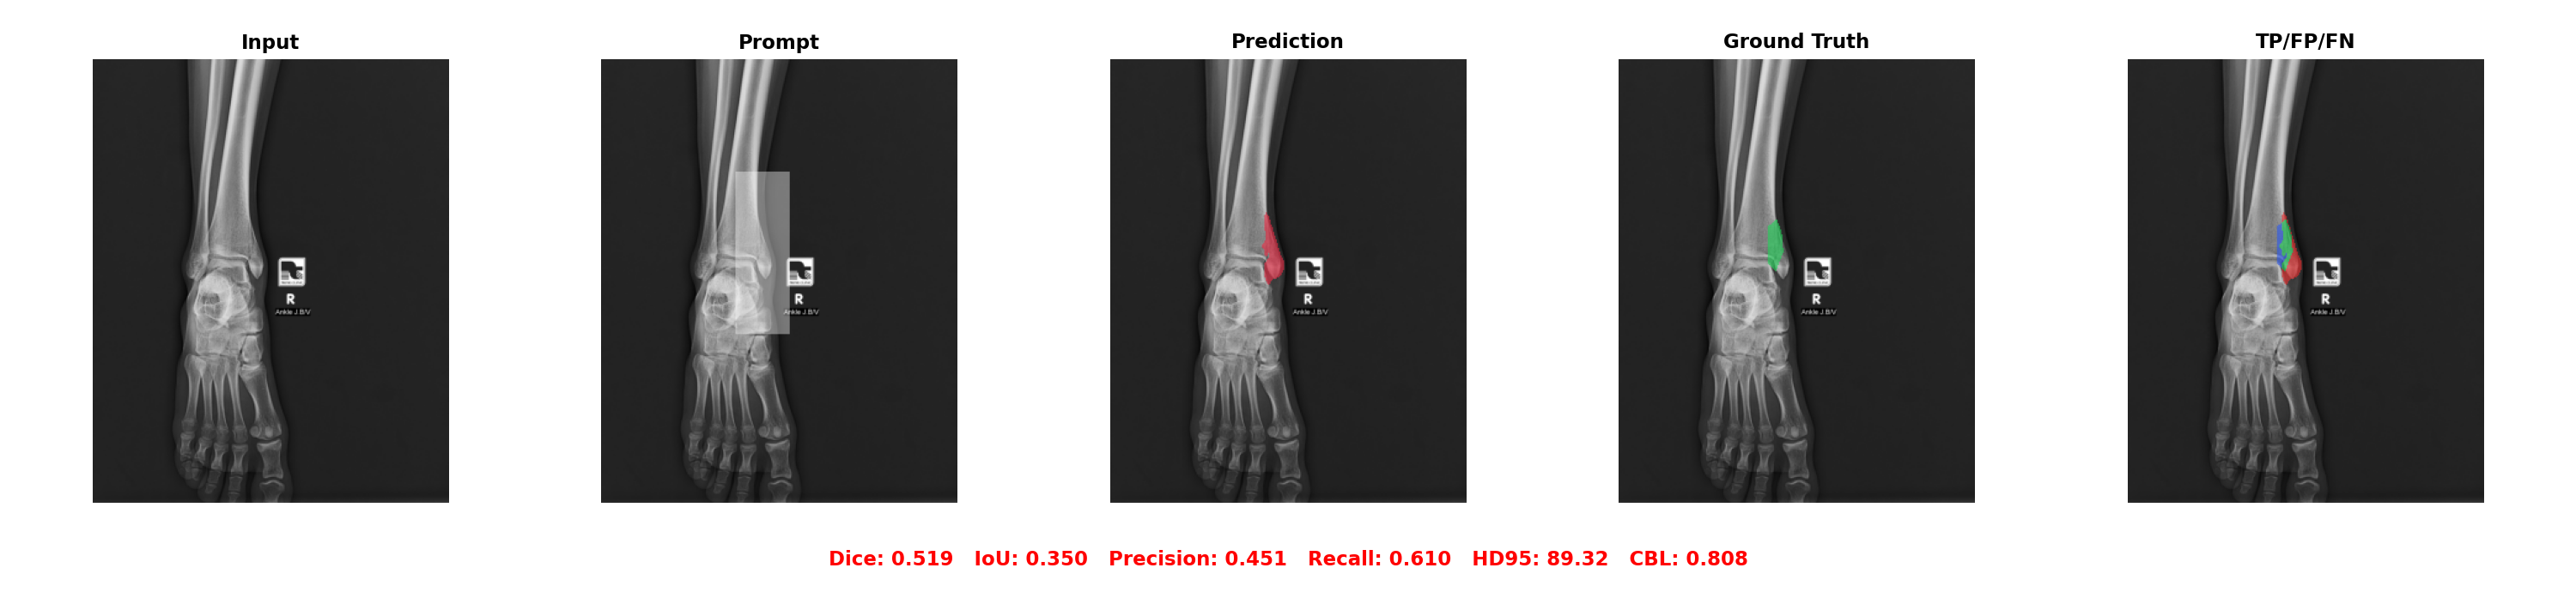

saved scribbleprompt_zeroshot_fracatlas_IMG0000151.png


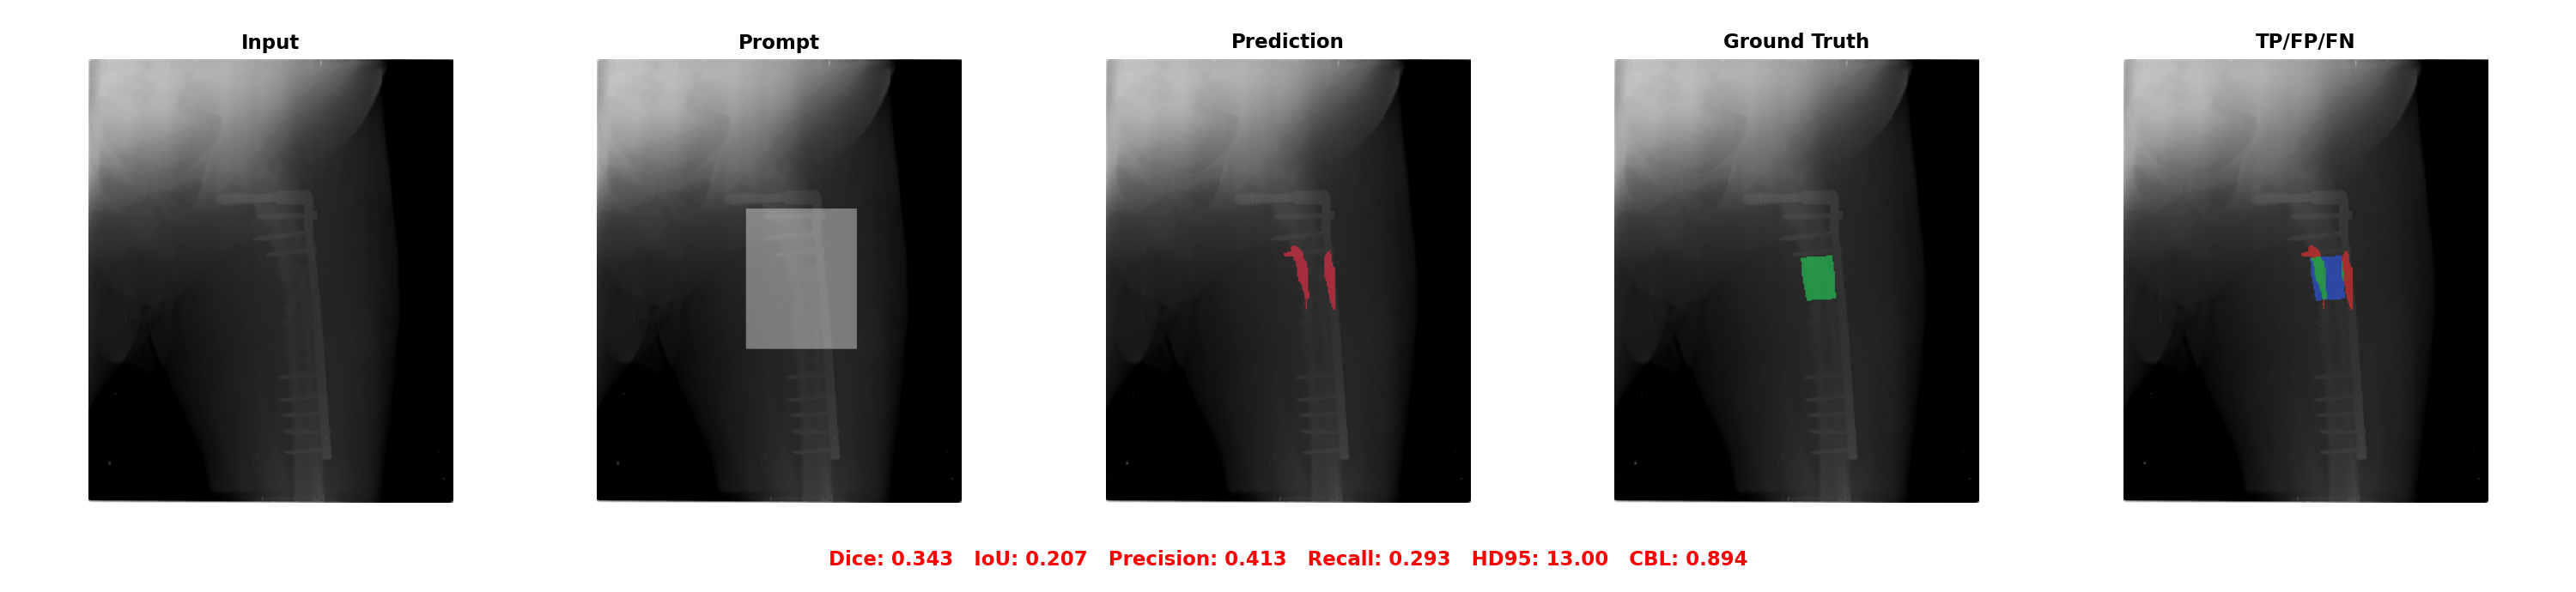

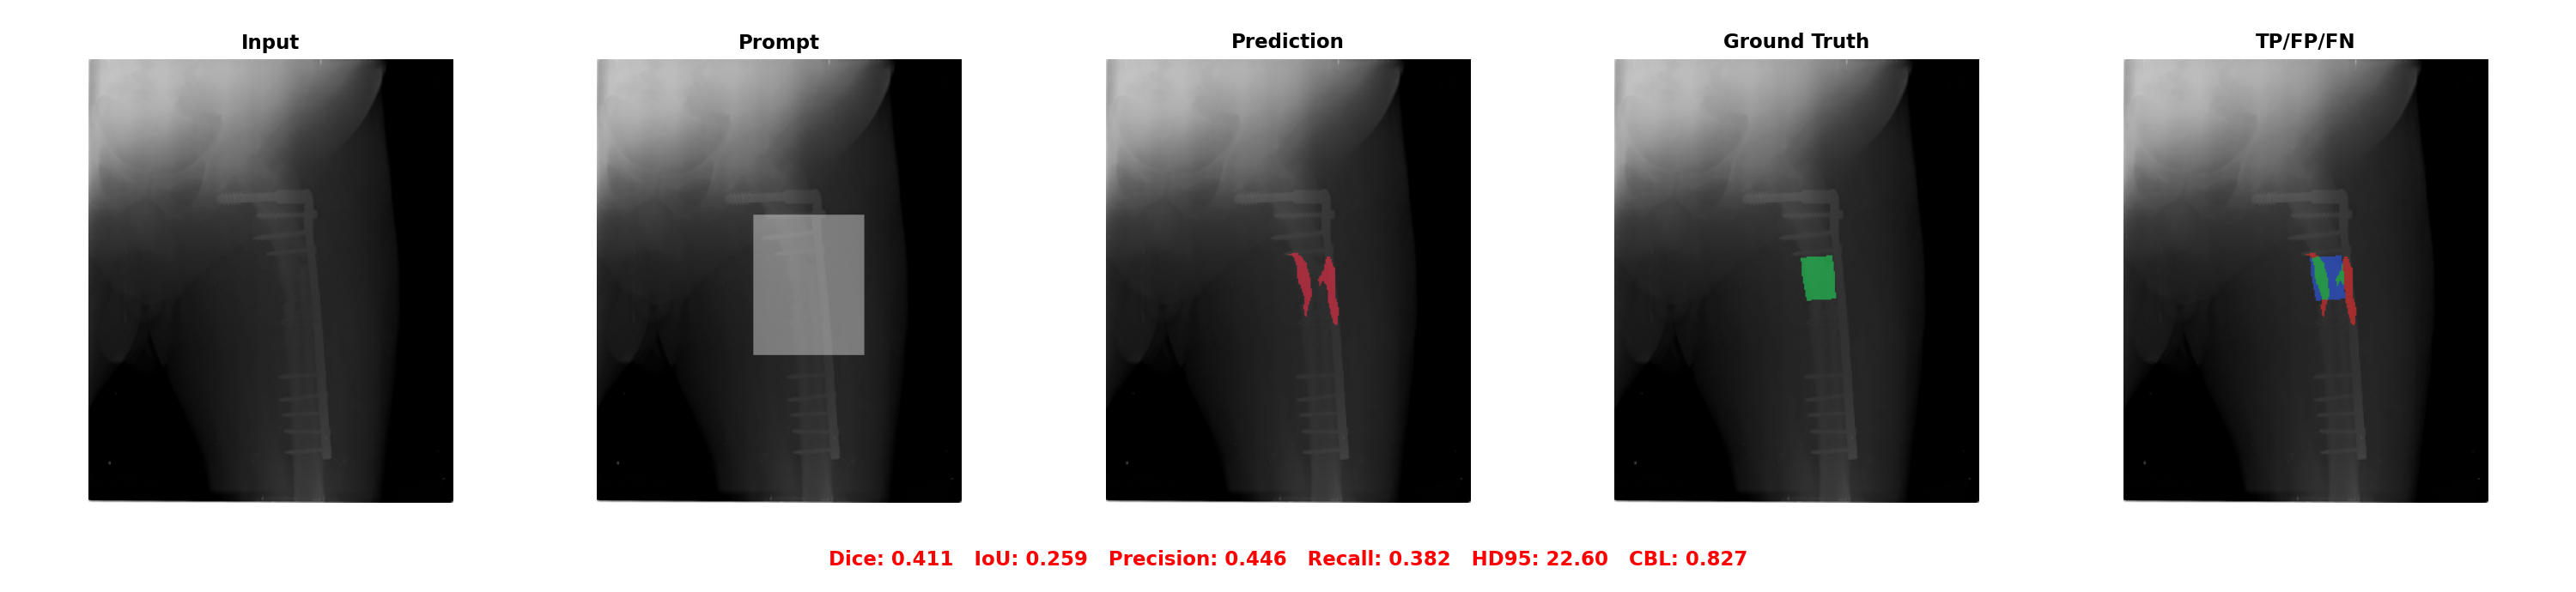

saved scribbleprompt_zeroshot_fracatlas_IMG0000453.png


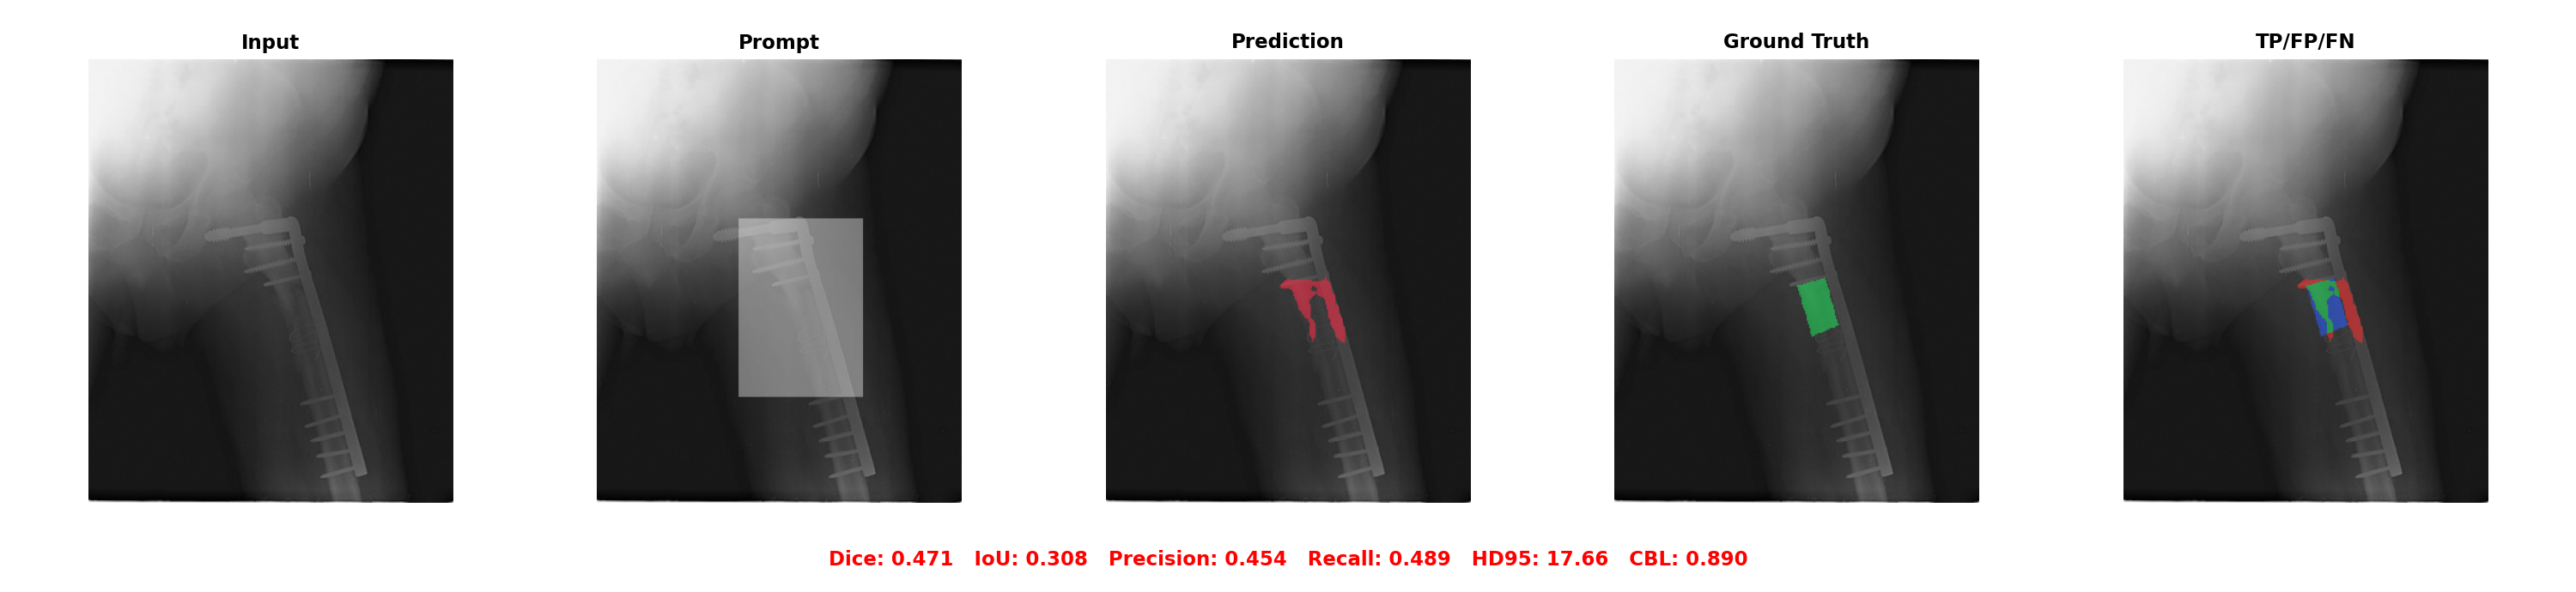

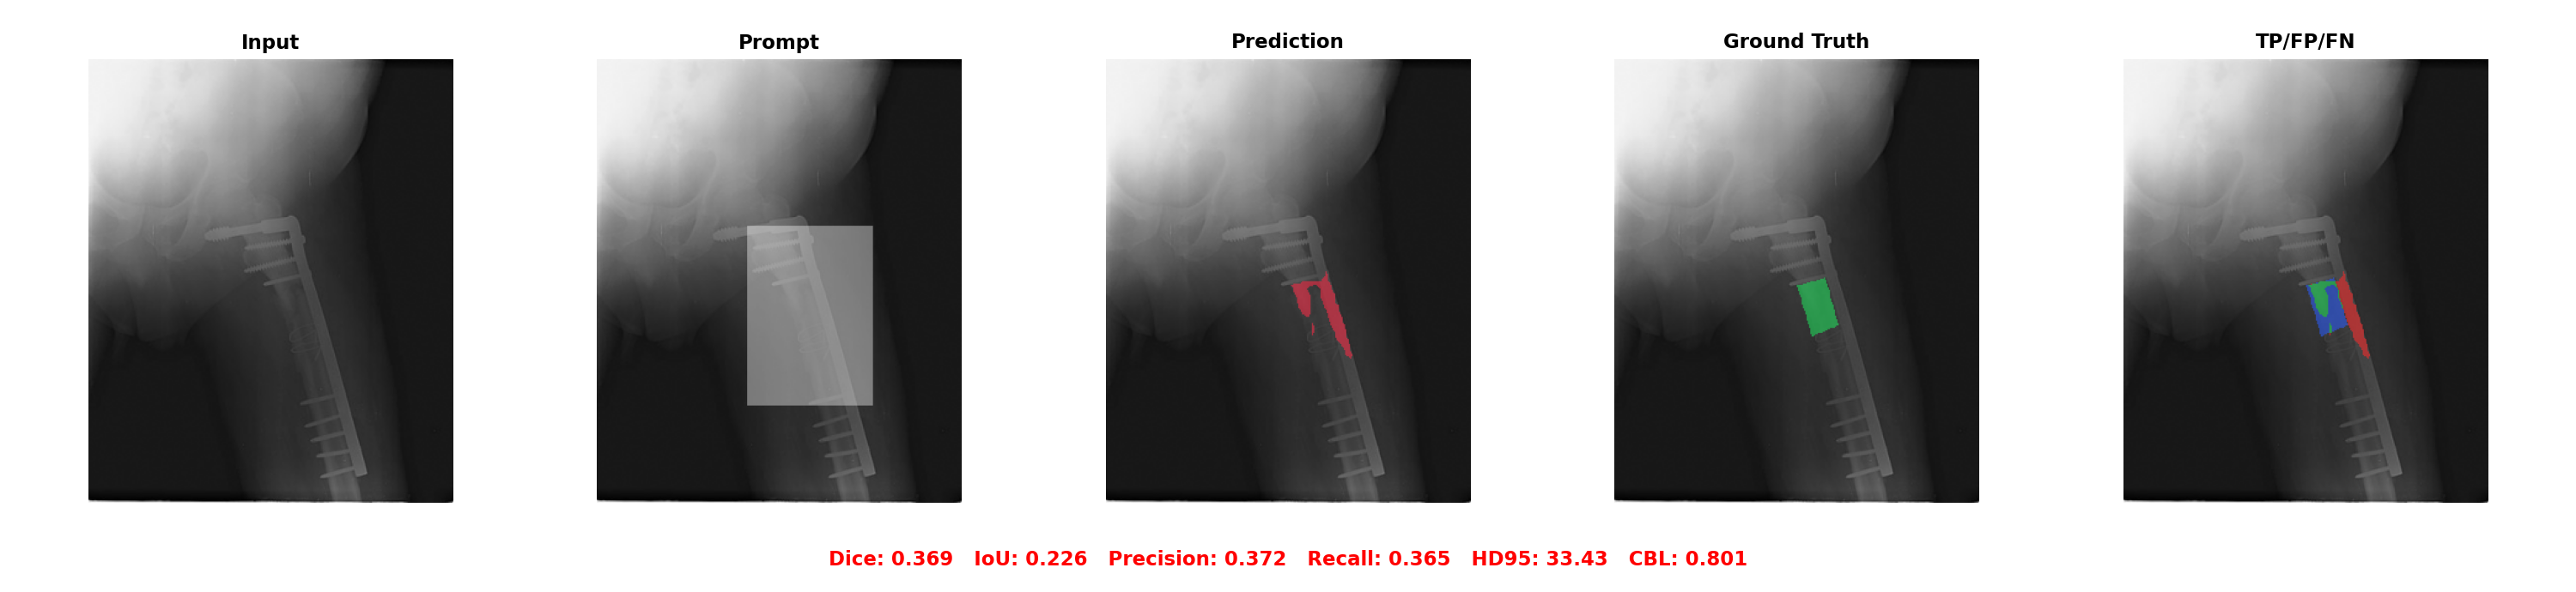

saved scribbleprompt_zeroshot_fracatlas_IMG0000454.png


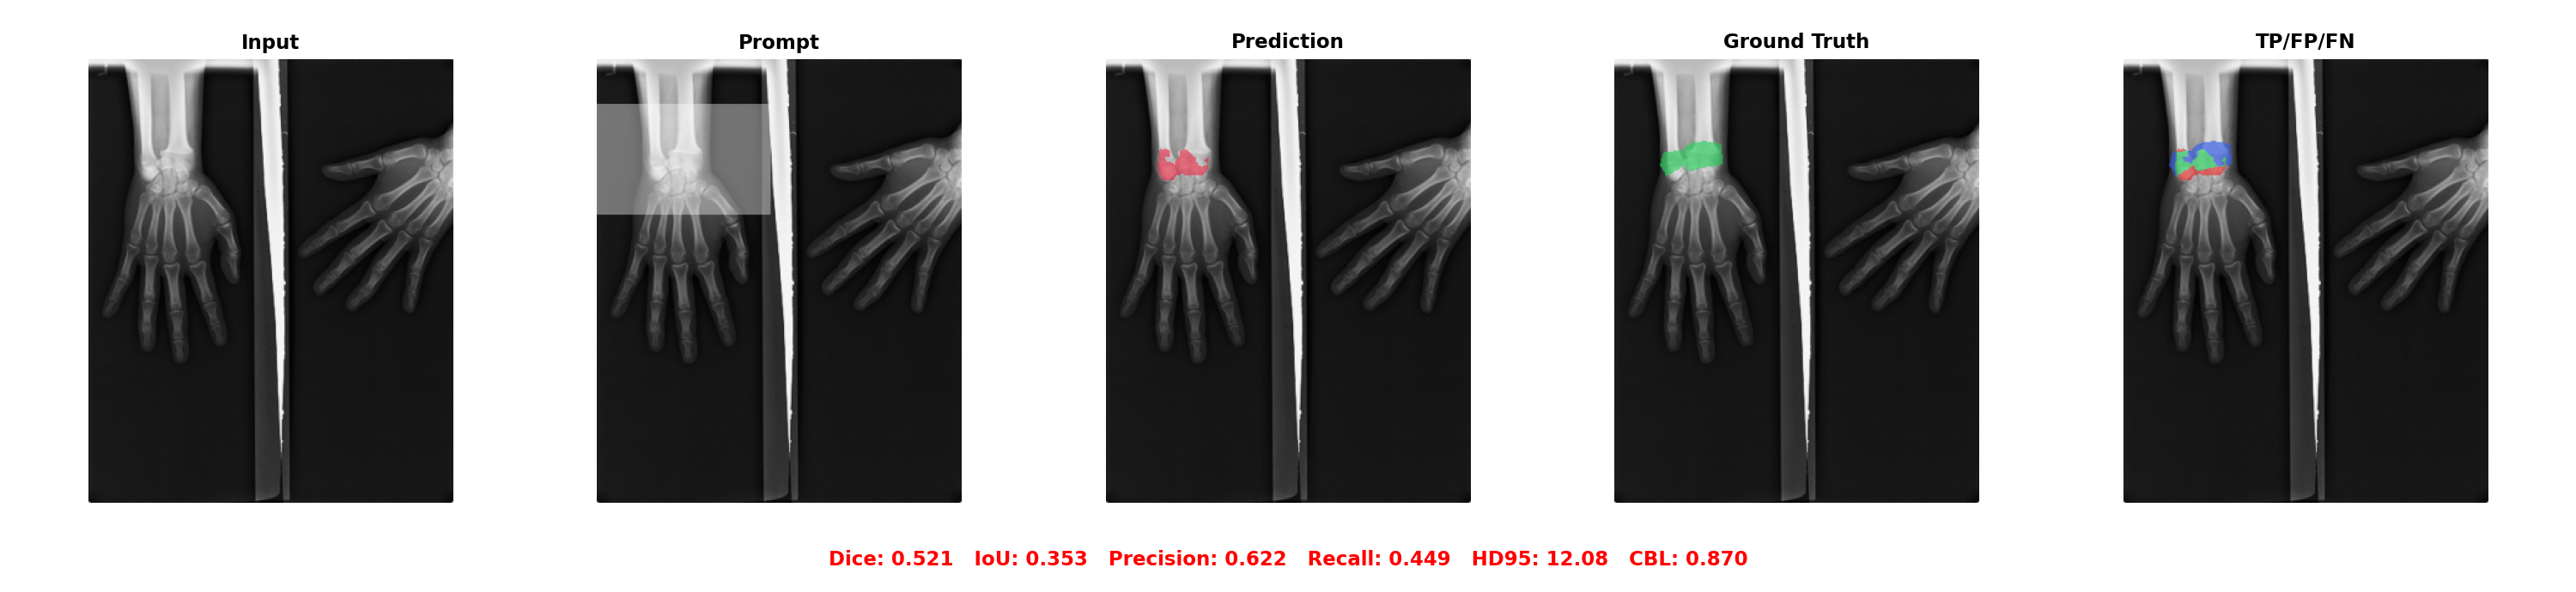

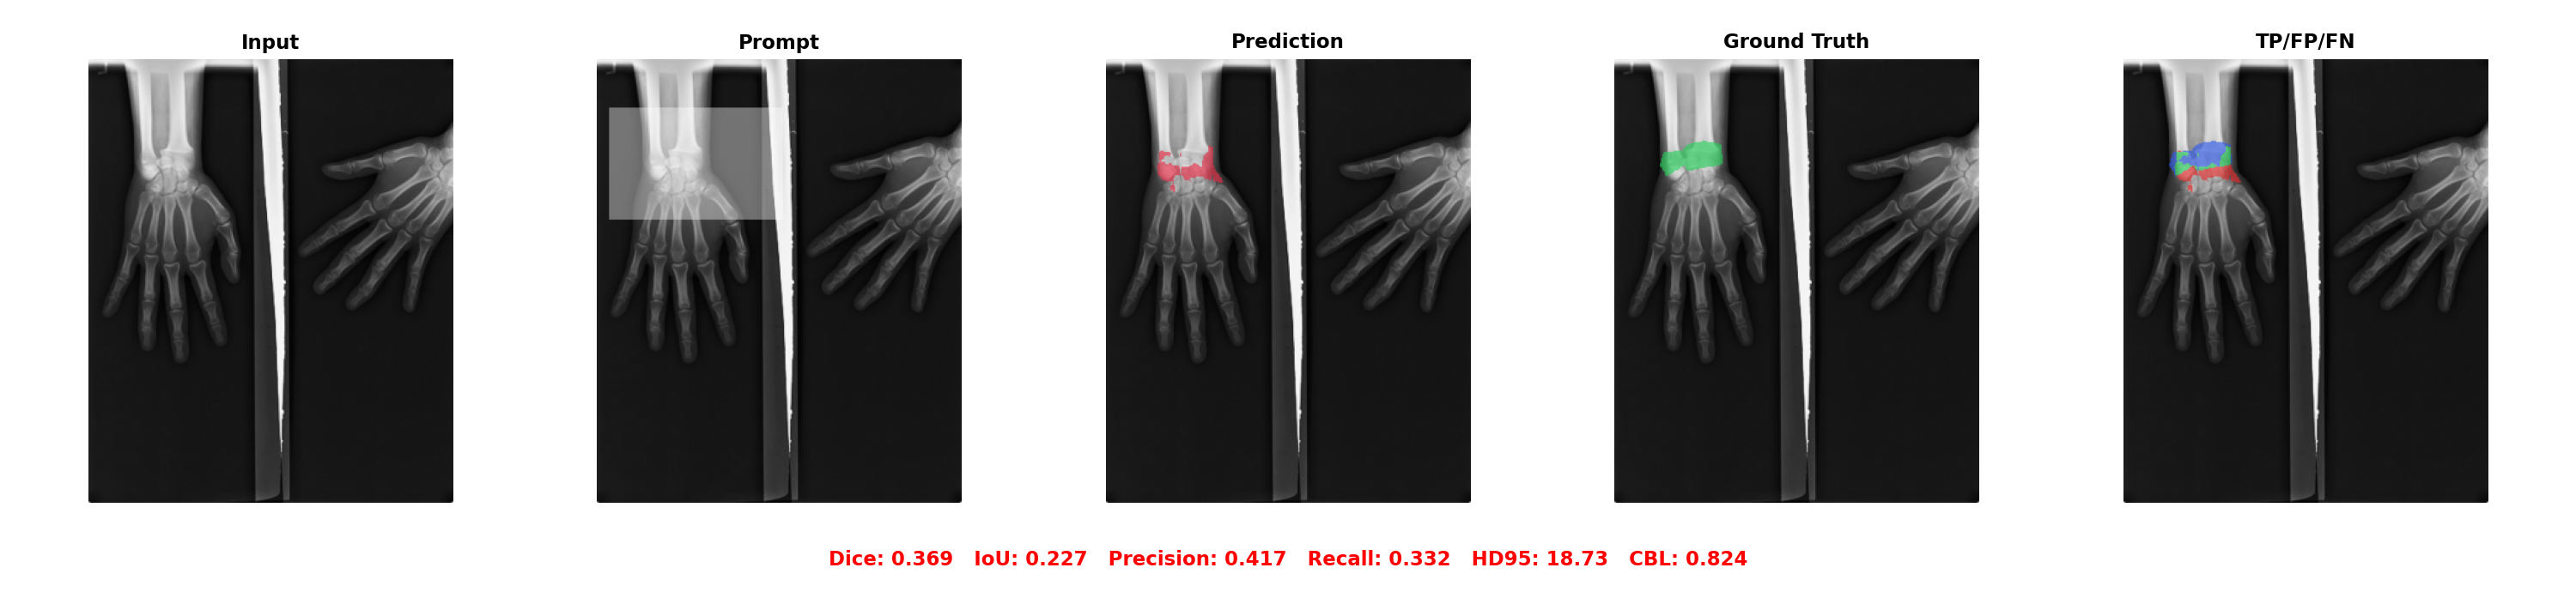

saved scribbleprompt_zeroshot_fracatlas_IMG0001123.png


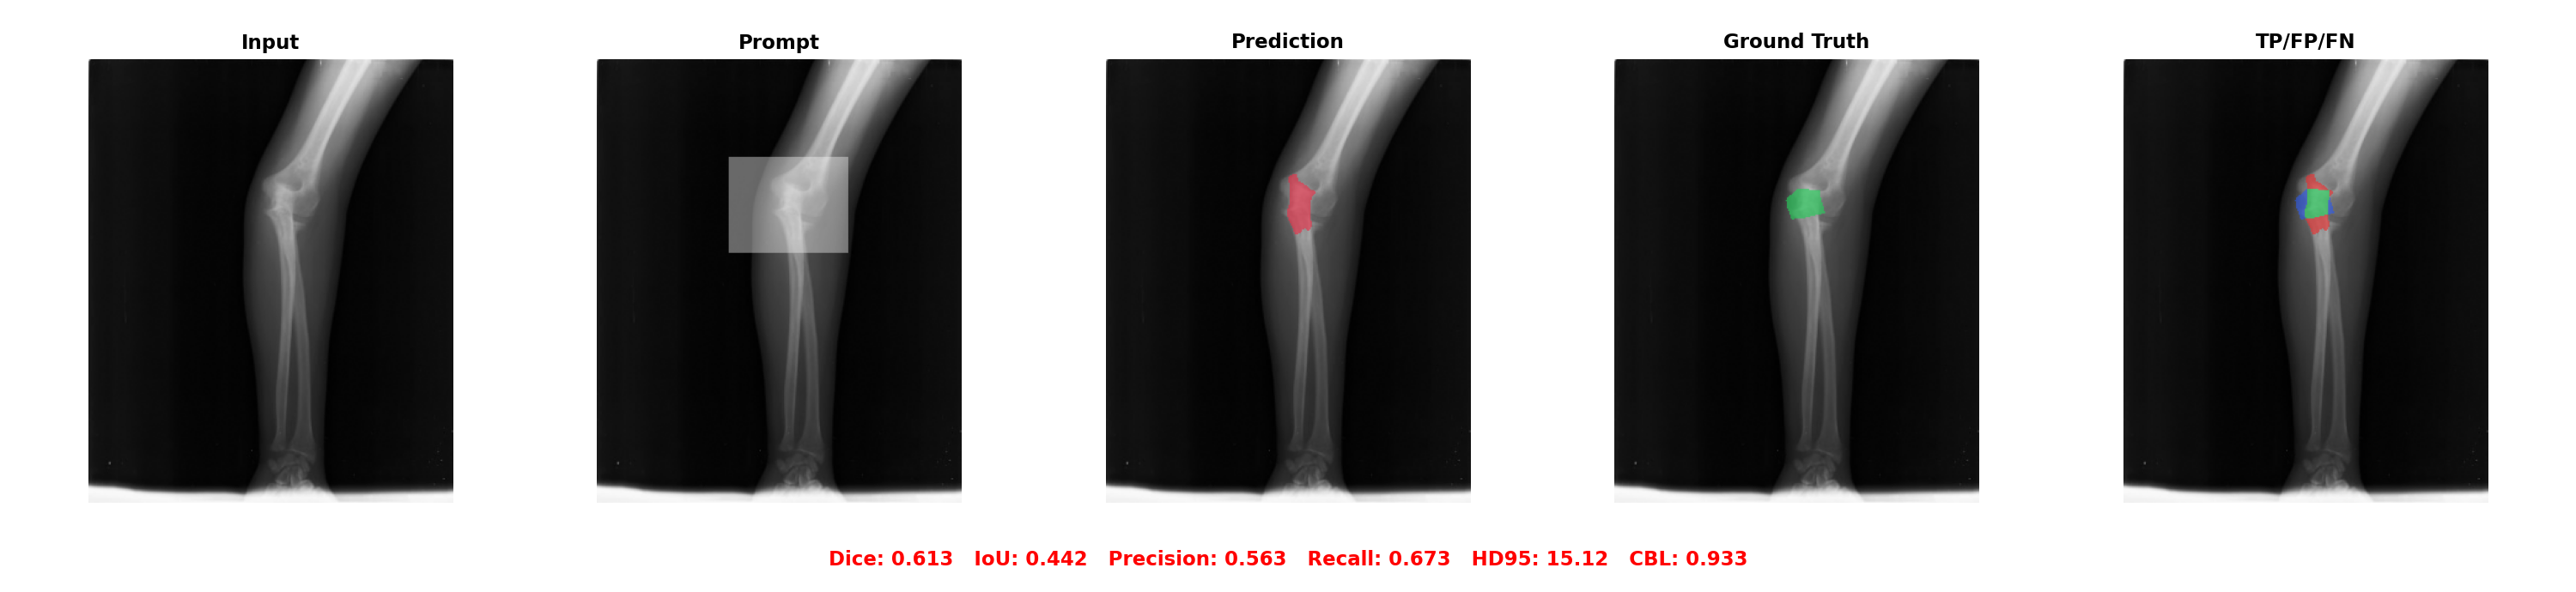

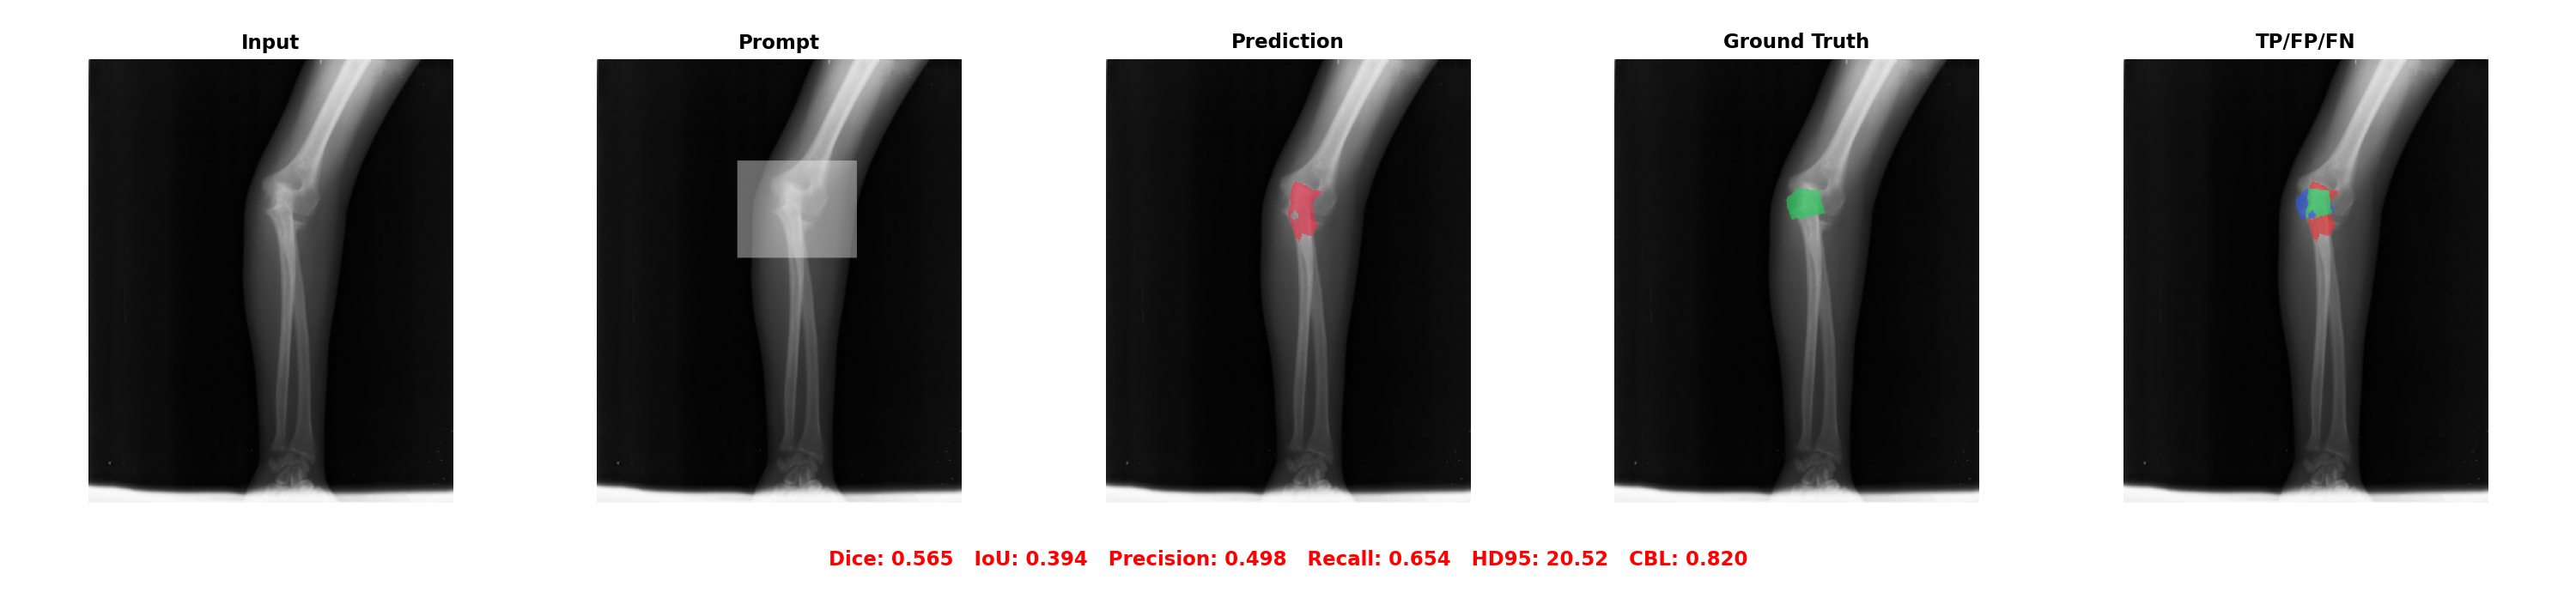

saved scribbleprompt_zeroshot_fracatlas_IMG0001360.png


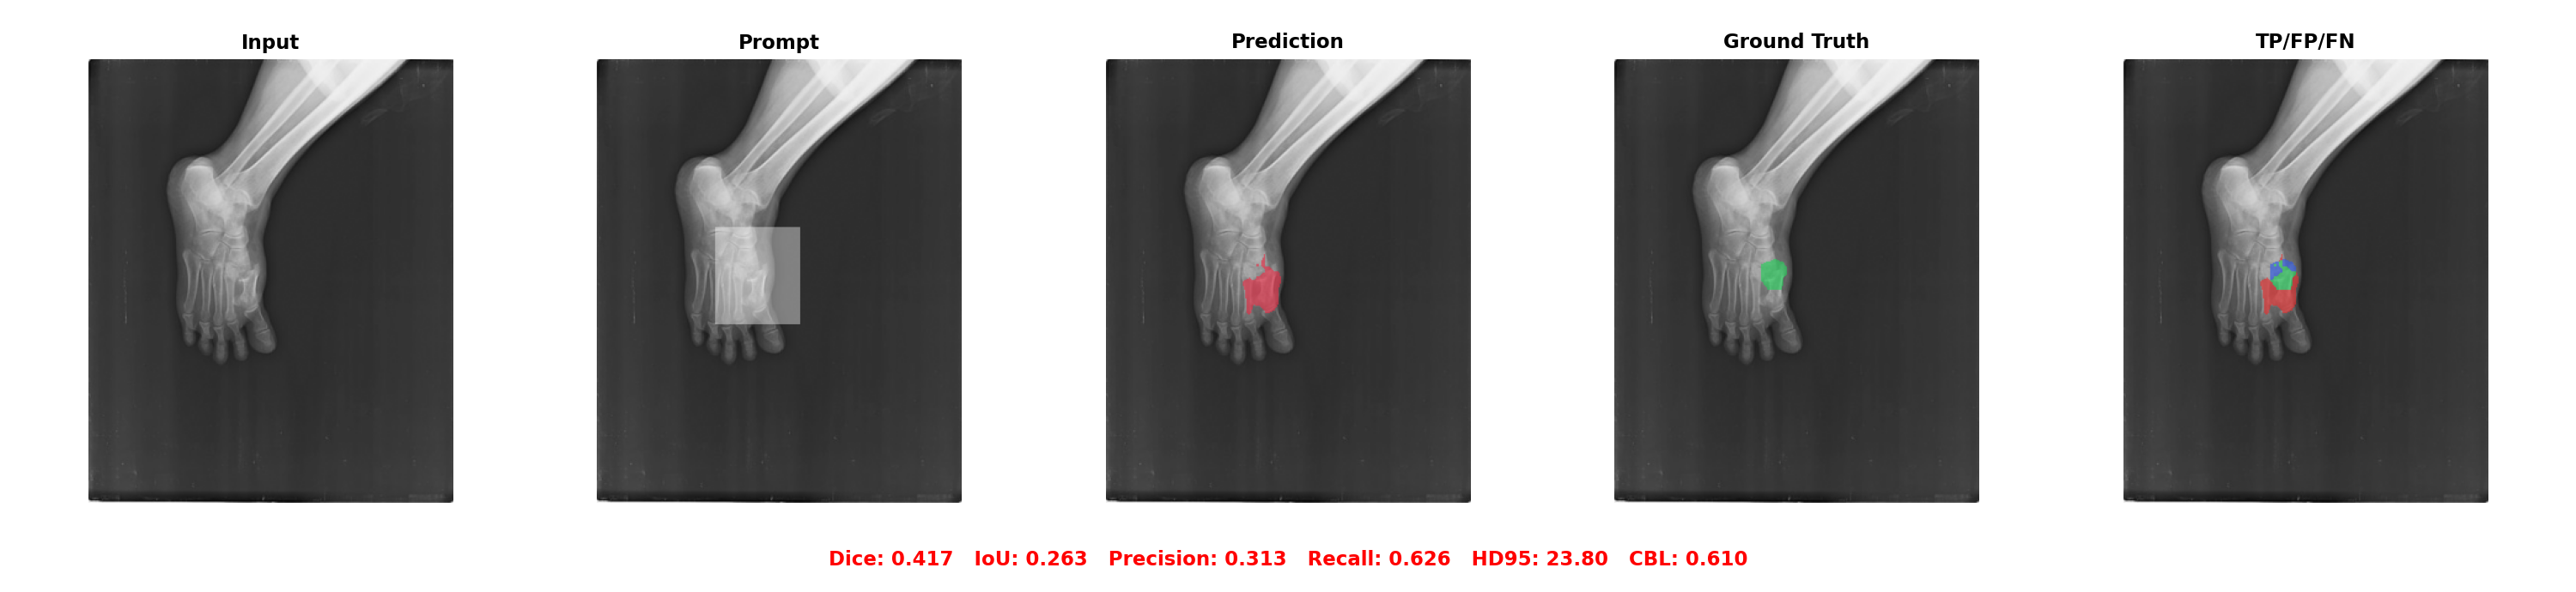

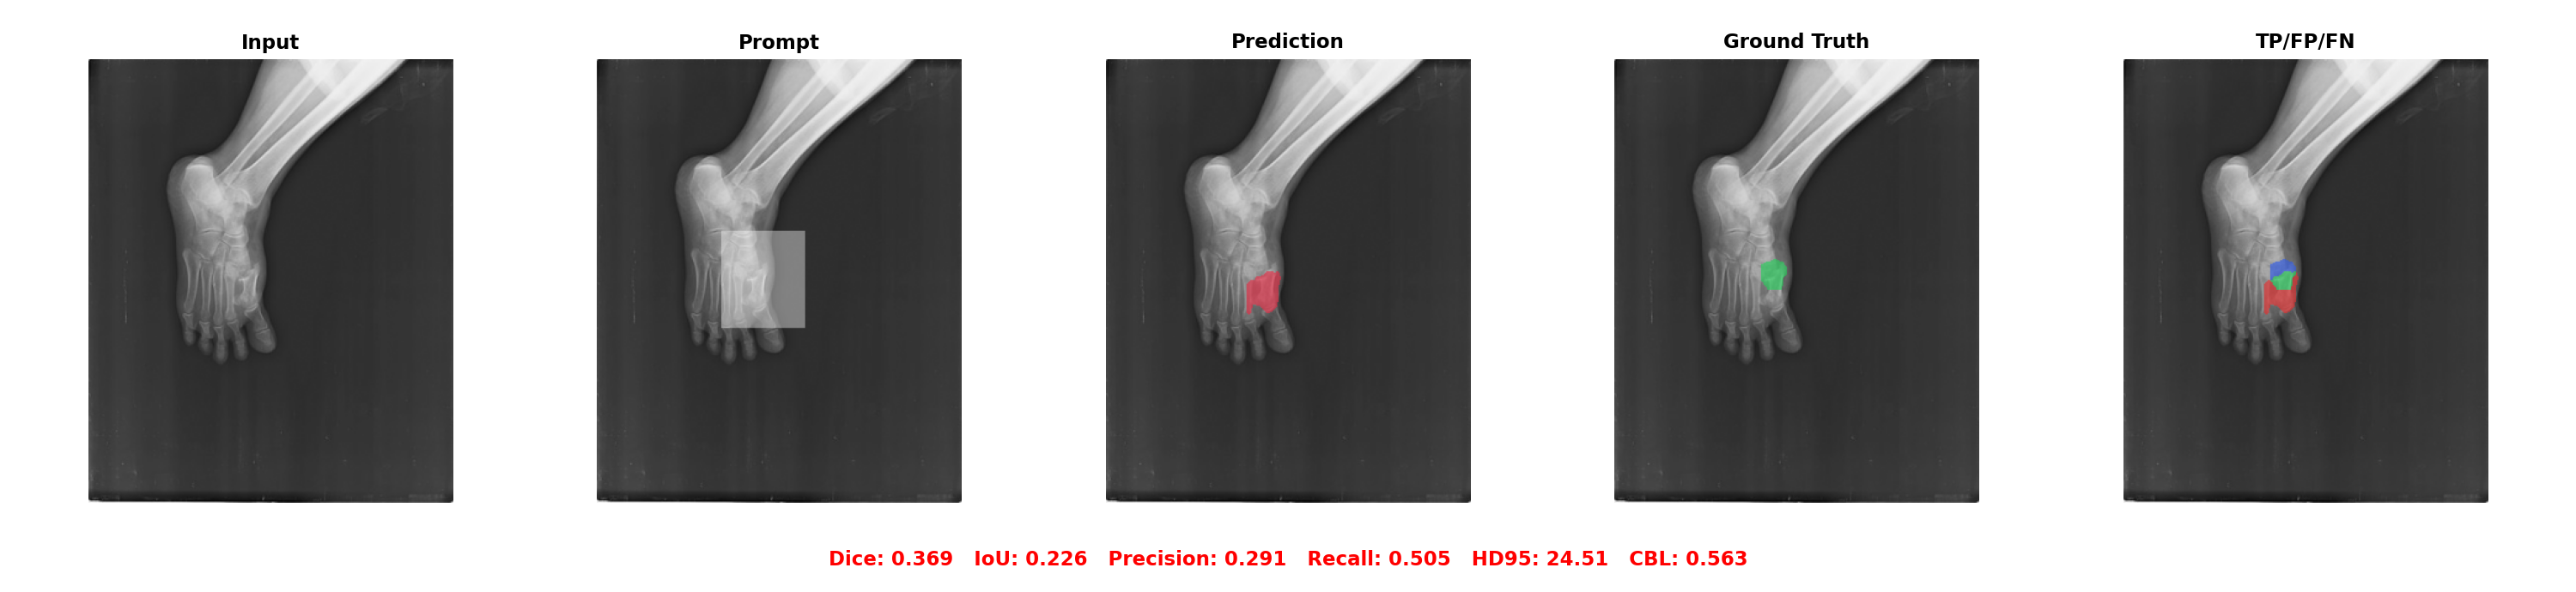

saved scribbleprompt_zeroshot_fracatlas_IMG0001980.png


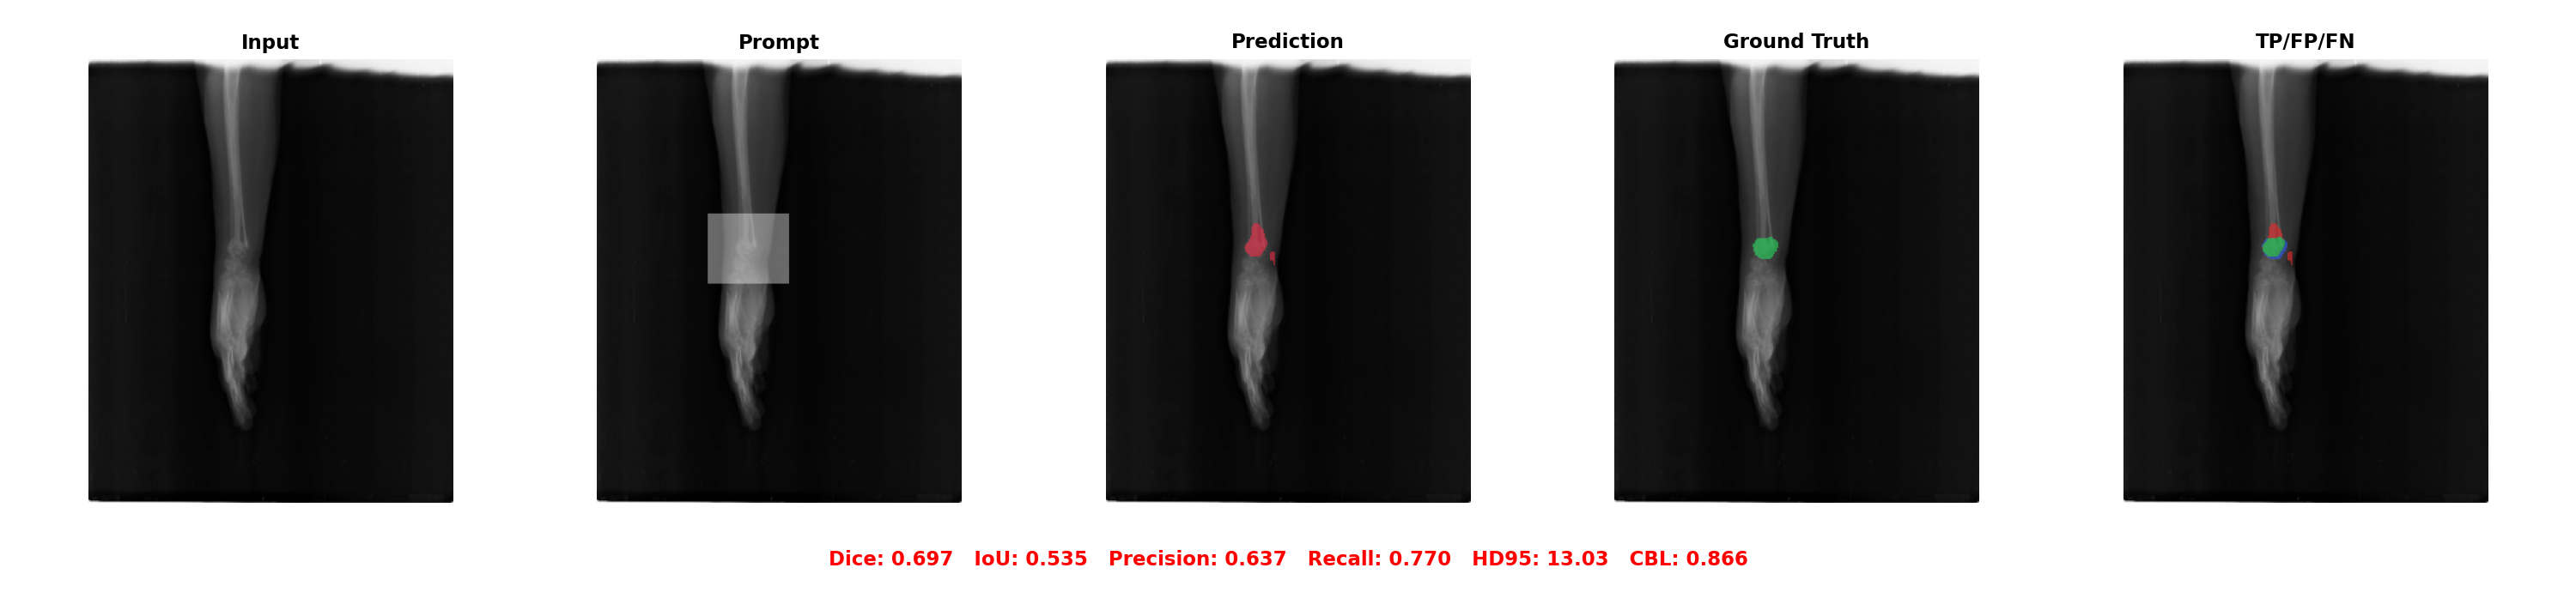

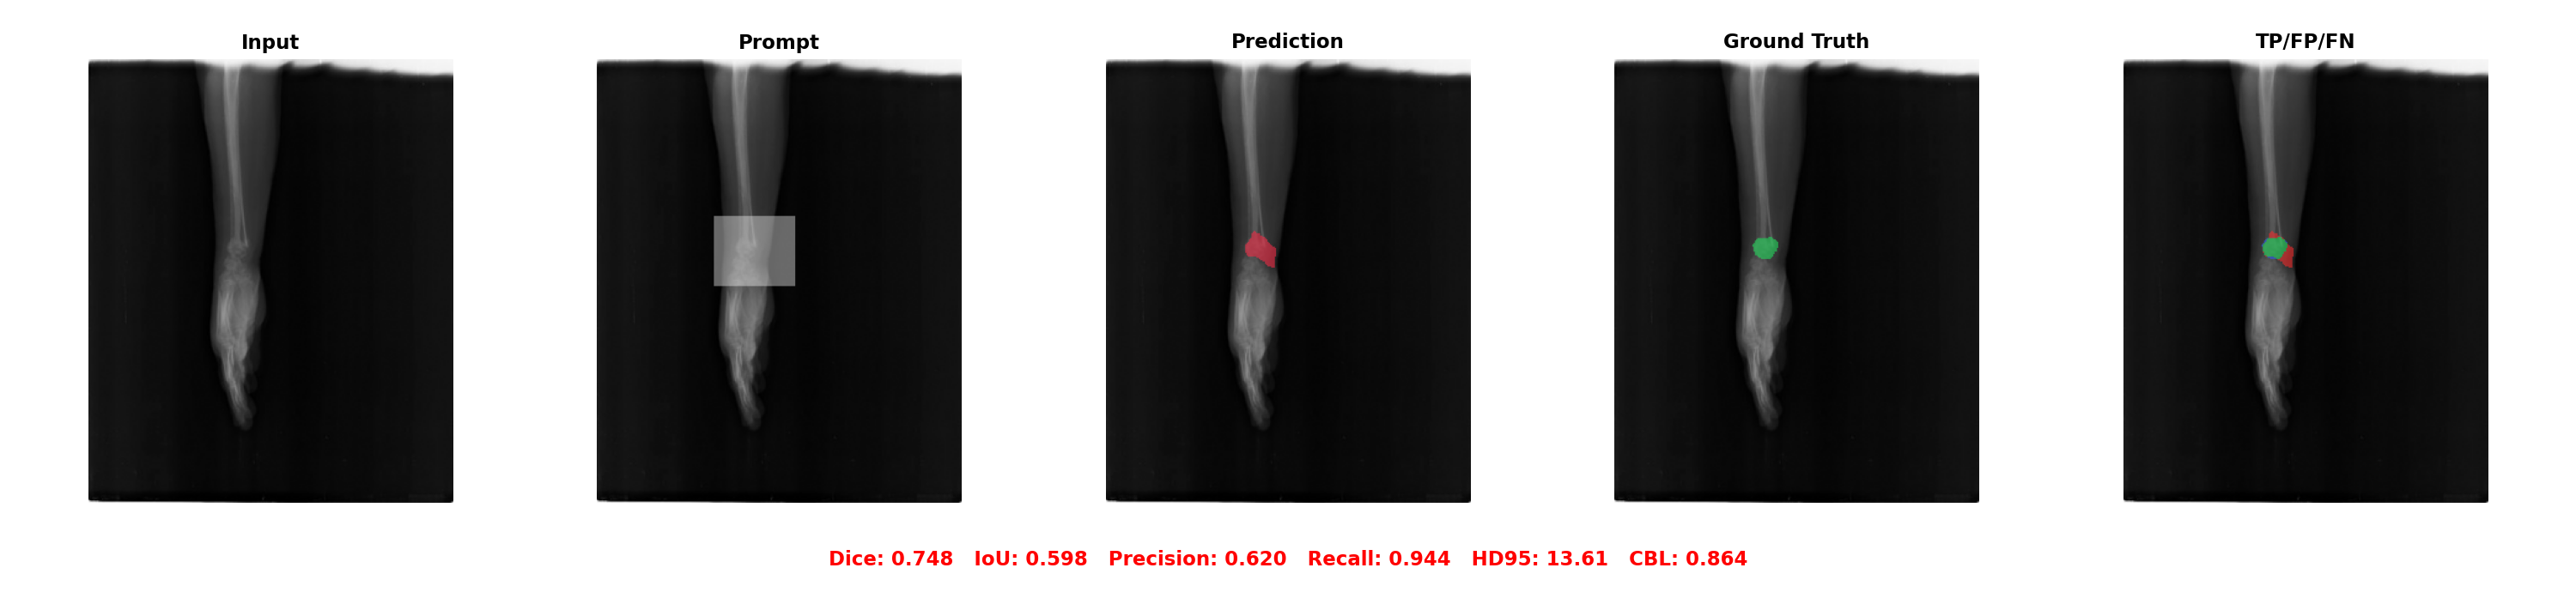

saved scribbleprompt_zeroshot_fracatlas_IMG0002021.png


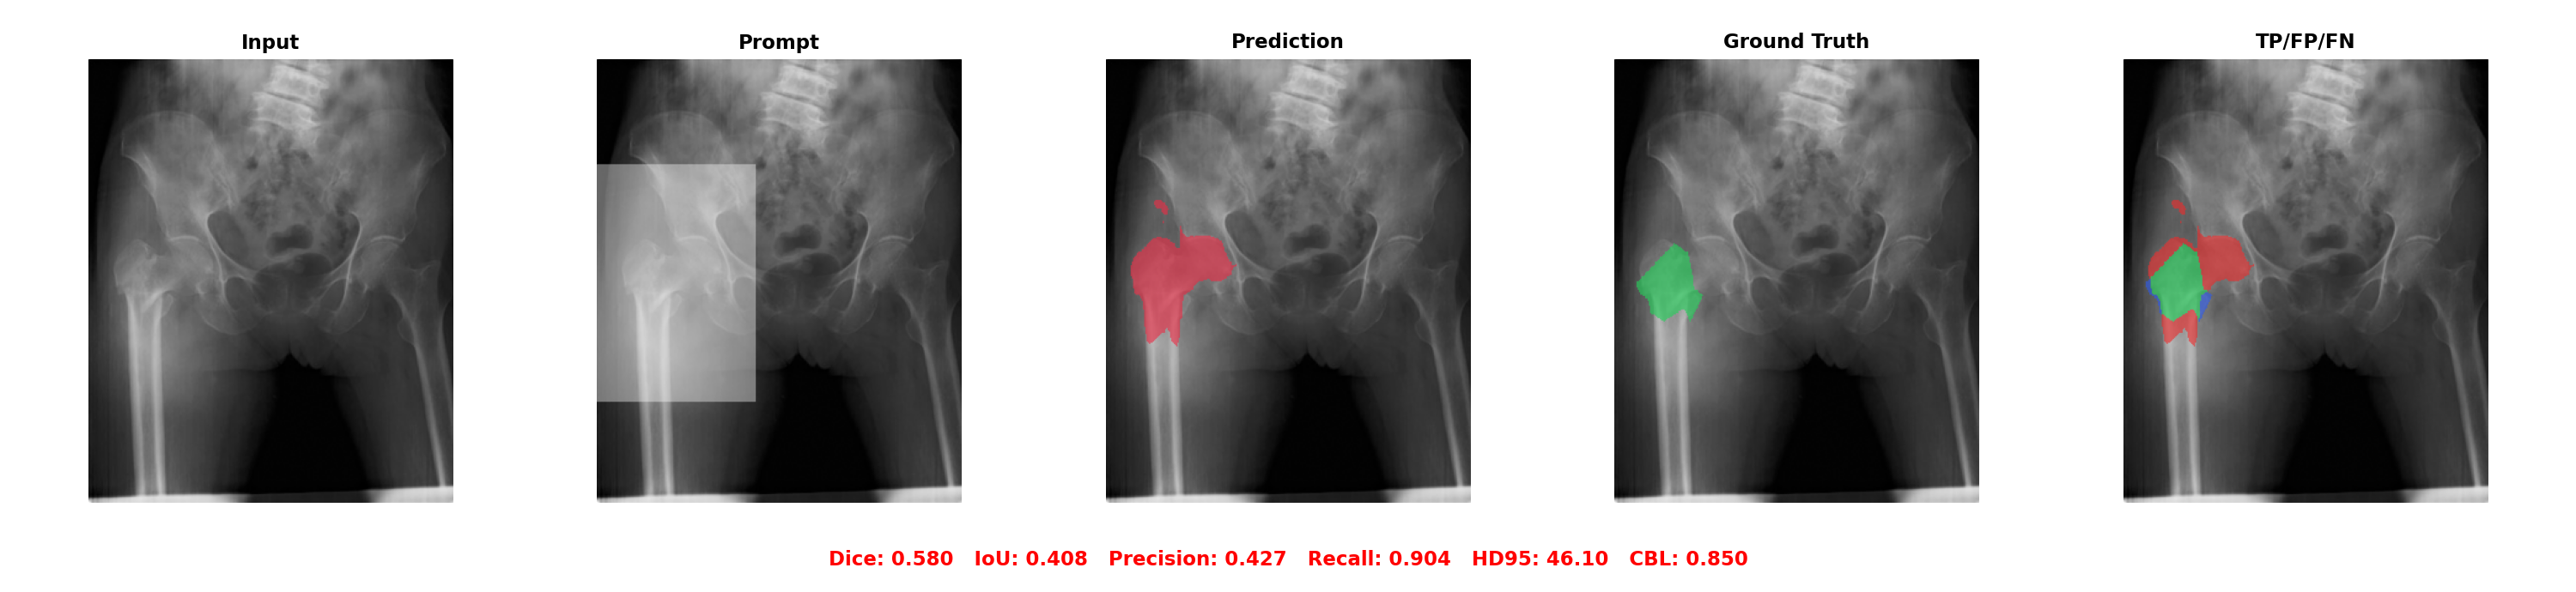

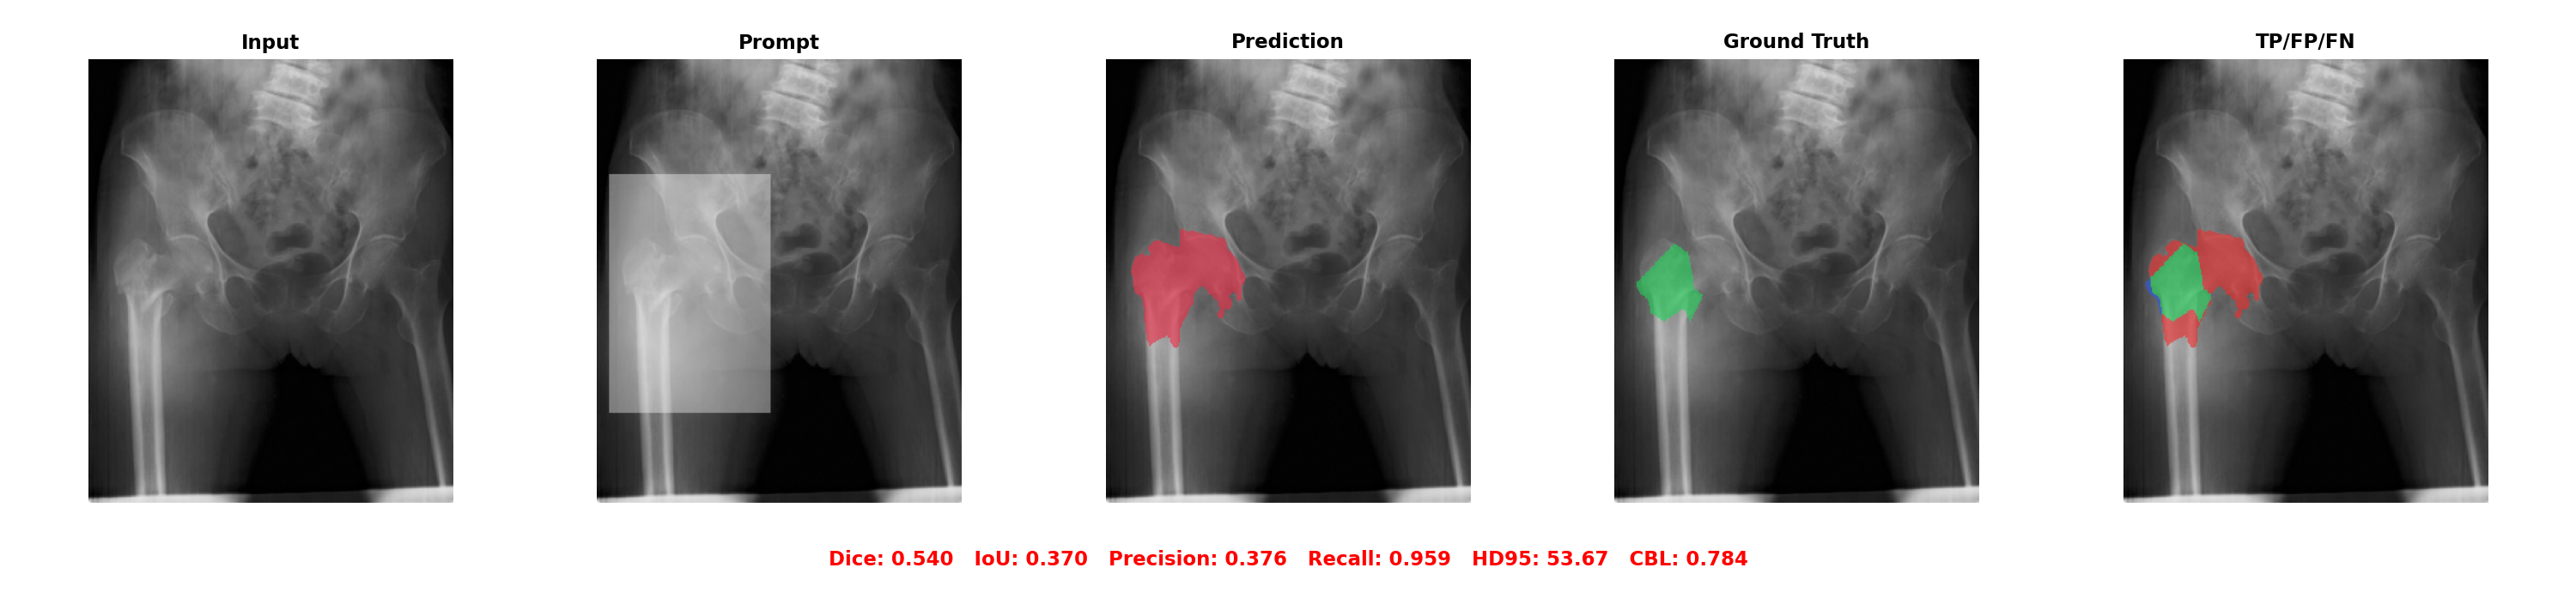

saved scribbleprompt_zeroshot_fracatlas_IMG0002180.png


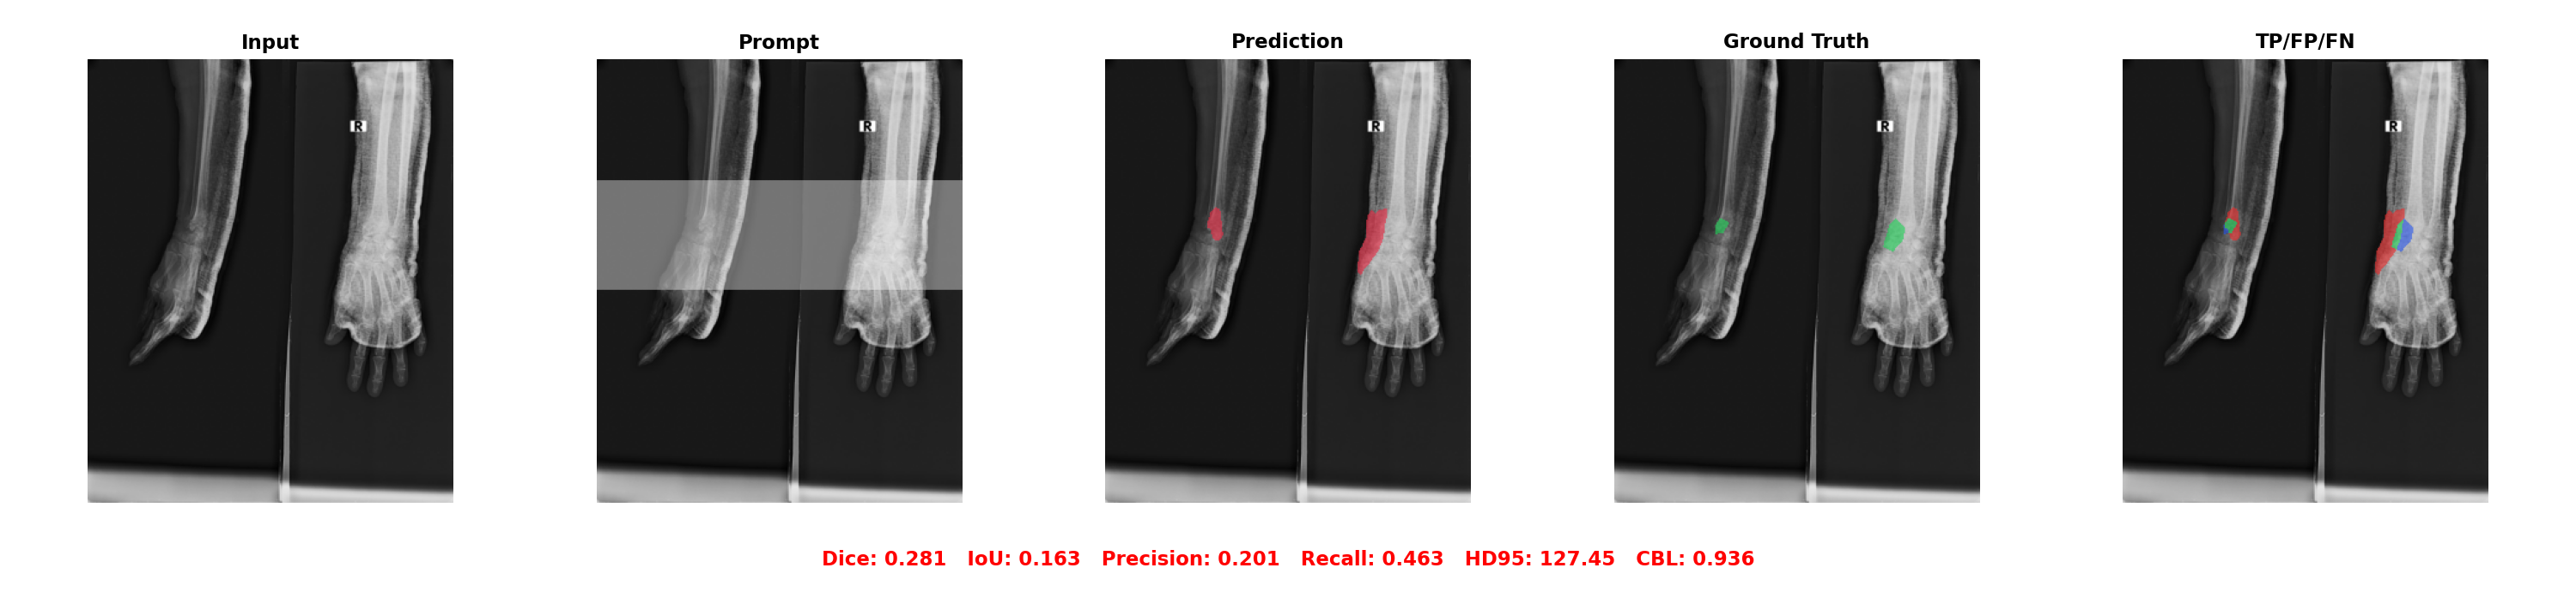

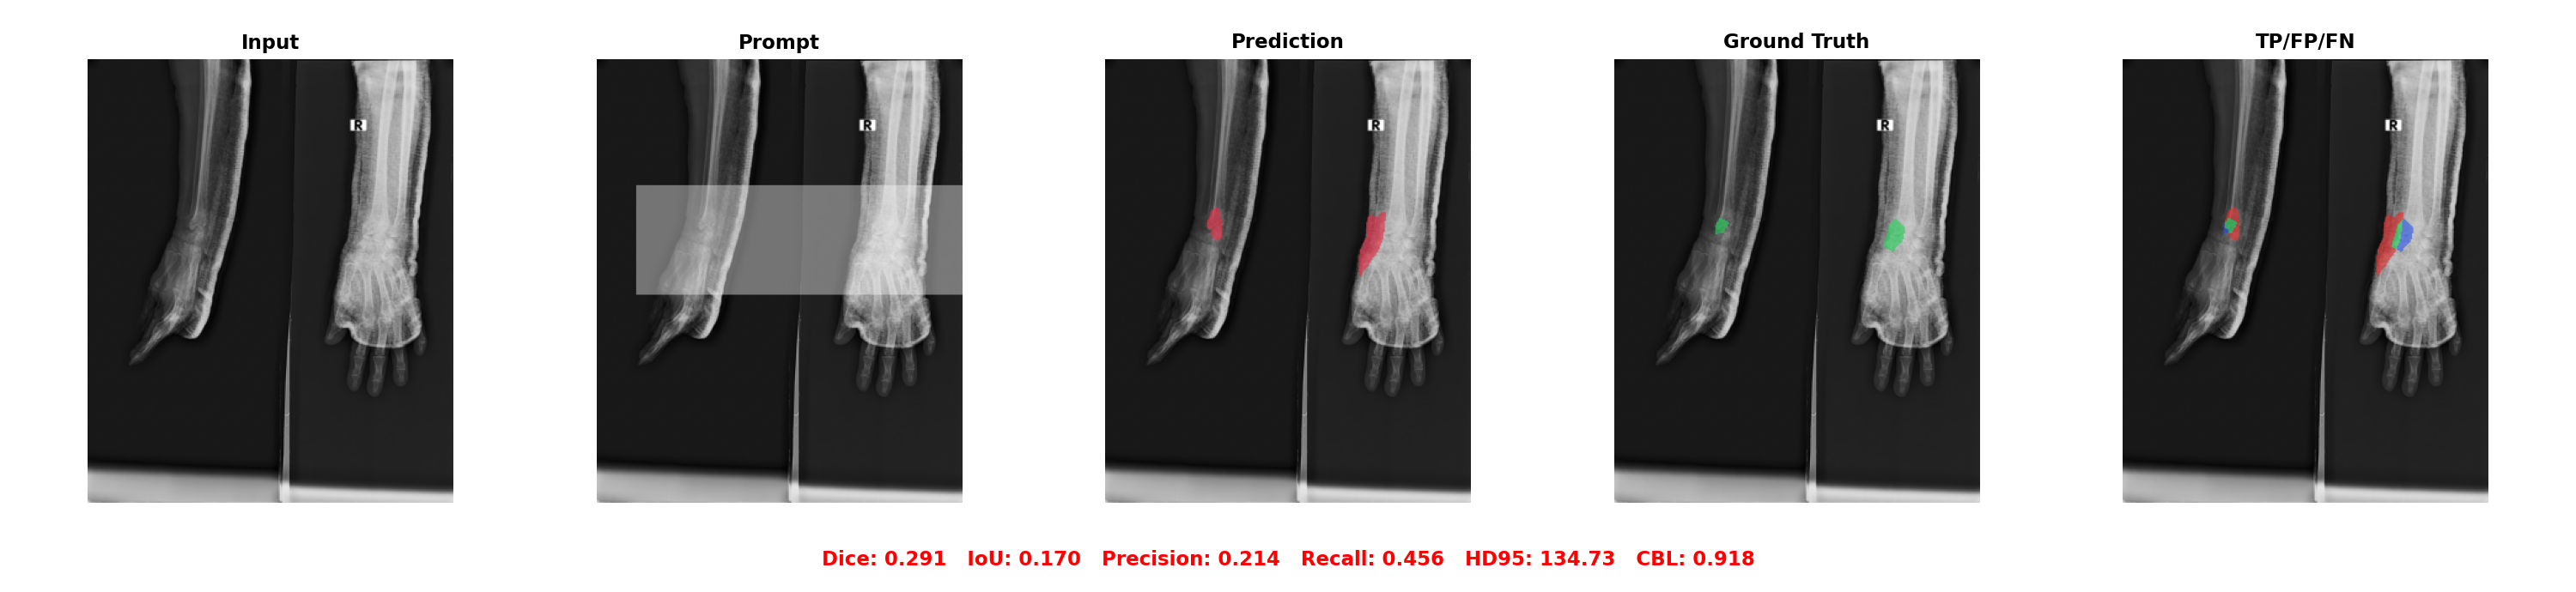

saved scribbleprompt_zeroshot_fracatlas_IMG0002300.png


In [3]:
# -- Part A: run + report --
rows_zeroshot, images_zeroshot = run_test('zero-shot')

# -- Qualitative figures (10 shared stems, same style as Finetune_SAMMed2D_test_robust.ipynb) --
visualize_qualitative(images_zeroshot, TEST_IMG, box_ds, 'ScribblePrompt-UNet (zero-shot)',
                      f'scribbleprompt_zeroshot_{DS_NAME.lower()}')

## Part B - fine-tune (full model)

The small ScribblePrompt-UNet is fine-tuned end to end from the official
pretrained weights. Boxes follow the same protocol as PGA-UNet and the
other fine-tuned baselines (`center_mixed`, 80% `center_shift` / 20%
`center_zoom` per sample); each baseline otherwise keeps its own official
recipe, and no flip or rotation augmentation is added here. Loss is
computed at the model's native $128\times128$ resolution against a
downsampled ground truth (full-resolution scoring is used only for
evaluation), one optimizer step per 4-polygon batch. Model selection is on
the validation split under the fixed off-center condition, early stopping
with patience 30 (the fine-tuned SAM-Med2D baseline's longer window, not
PGA-UNet's from-scratch 15), up to 150 epochs, `lr=1e-5`.

In [4]:
# -- Part B: fine-tuning setup --
import torch.nn.functional as F
import random
from scribbleprompt.models.unet import prepare_inputs

EPOCHS     = 150
PATIENCE   = 30     # matches the fine-tuned SAM-Med2D baseline in this article, not PGA's own from-scratch 15
BATCH_SIZE = 4      # matches PGA-UNet's and SAM-Med2D's batch size (loss averaged over 4 samples per step)
LR         = 1e-5
MIXED_SHIFT_PROB = 0.8   # matches PromptSegmentationDataset's own default
BEST_CKPT_PATH = f'{PGA_PATH}/checkpoints/scribbleprompt_finetuned_{DS_NAME.lower()}_best.pt'
os.makedirs(os.path.dirname(BEST_CKPT_PATH), exist_ok=True)

random.seed(22120196); np.random.seed(22120196); torch.manual_seed(22120196)
if torch.cuda.is_available(): torch.cuda.manual_seed_all(22120196)

train_box_ds = PromptSegmentationDataset(TRAIN_IMG, TRAIN_JSON, is_train=True, prompt_mode='center_mixed')
val_box_ds   = PromptSegmentationDataset(VAL_IMG, VAL_JSON, is_train=False, prompt_mode='center_shift')
print(f'{DS_NAME}: {len(train_box_ds.all_samples)} train polygons, {len(val_box_ds.all_samples)} val polygons')

sp_model.model.train(True)
optimizer = torch.optim.AdamW(sp_model.model.parameters(), lr=LR, weight_decay=1e-4)

def scribbleprompt_compute_loss(img_gray, box_xyxy, gt_mask_hw):
    # Returns the loss TENSOR (no backward/step here) so the training loop can
    # average it with 3 other samples first, matching PGA/SAM-Med2D's batch_size=4.
    canvas, sc, pl, pt, nw, nh = resize_and_pad(img_gray, SP_SIZE, cv2.INTER_LINEAR, 0)
    canvas = canvas.astype(np.float32)
    canvas = (canvas - canvas.min()) / np.clip(canvas.max() - canvas.min(), 1e-8, None)
    img_t = torch.from_numpy(canvas).float().unsqueeze(0).unsqueeze(0).to(DEVICE)
    x0, y0, x1, y1 = box_xyxy
    box_128 = [x0 * sc + pl, y0 * sc + pt, x1 * sc + pl, y1 * sc + pt]
    box_t = torch.as_tensor([[box_128]], dtype=torch.float32, device=DEVICE)
    gt_128, _, _, _, _, _ = resize_and_pad(gt_mask_hw.astype(np.float32), SP_SIZE, cv2.INTER_NEAREST, 0)
    gt_t = torch.from_numpy(gt_128).float().unsqueeze(0).unsqueeze(0).to(DEVICE)

    # predict() is @torch.no_grad(); for training, build the same 5-channel input
    # predict() would and run the underlying UNet directly, with grad enabled.
    x = prepare_inputs({'img': img_t, 'point_coords': None, 'point_labels': None,
                        'scribbles': None, 'box': box_t, 'mask_input': None}).float().to(DEVICE)
    prob = torch.sigmoid(sp_model.model(x)).clamp(1e-6, 1 - 1e-6)
    bce = F.binary_cross_entropy(prob, gt_t)
    inter = (prob * gt_t).sum()
    dice_loss = 1 - (2 * inter + 1e-5) / (prob.sum() + gt_t.sum() + 1e-5)
    return bce + dice_loss

@torch.no_grad()
def validate():
    sp_model.model.eval()
    names = sorted(set(n for n, _ in val_box_ds.all_samples))
    dices = []
    for img_name in names:
        base = os.path.splitext(img_name)[0]
        img_gray = cv2.imread(os.path.join(VAL_IMG, img_name), cv2.IMREAD_GRAYSCALE)
        H, W = img_gray.shape
        with open(os.path.join(VAL_JSON, base + '.json'), encoding='utf-8') as f:
            data = _json.load(f)
        pred = np.zeros((H, W), dtype=np.float32)
        gt = np.zeros((H, W), dtype=np.uint8)
        poly_idxs = [i for i, s in enumerate(data.get('shapes', [])) if s.get('shape_type') == 'polygon']
        for shape_idx in poly_idxs:
            points = np.array(data['shapes'][shape_idx]['points'])
            cv2.fillPoly(gt, [points.astype(np.int32)], 1)
            x_min, y_min = points.min(axis=0); x_max, y_max = points.max(axis=0)
            sample_idx = val_box_ds.all_samples.index((img_name, shape_idx))
            b = val_box_ds._center_shift_bbox(x_min, x_max, y_min, y_max, H, W, seed_idx=sample_idx)
            box_xyxy = [b[0], b[2], b[1], b[3]]
            prob = scribbleprompt_predict_prob(img_gray, box_xyxy, H, W)
            pred = np.maximum(pred, prob)
        m = calc_metrics_img((pred > 0.5).astype(np.uint8), gt)
        dices.append(m['dice'])
    sp_model.model.train(True)
    return float(np.mean(dices))

print('fine-tuning helpers ready')

FracAtlas: 730 train polygons, 95 val polygons
fine-tuning helpers ready


In [5]:
# -- Part B: training loop with early stopping ------------------------------
best_val_dice = -1.0
epochs_without_improve = 0
train_samples = list(train_box_ds.all_samples)

for epoch in range(1, EPOCHS + 1):
    random.shuffle(train_samples)
    losses = []
    img_cache = {}
    for batch_start in range(0, len(train_samples), BATCH_SIZE):
        batch = train_samples[batch_start:batch_start + BATCH_SIZE]
        batch_losses = []
        for img_name, shape_idx in batch:
            base = os.path.splitext(img_name)[0]
            if img_name not in img_cache:
                img_gray = cv2.imread(os.path.join(TRAIN_IMG, img_name), cv2.IMREAD_GRAYSCALE)
                with open(os.path.join(TRAIN_JSON, base + '.json'), encoding='utf-8') as f:
                    img_cache[img_name] = (img_gray, _json.load(f))
            img_gray, data = img_cache[img_name]
            H, W = img_gray.shape
            points = np.array(data['shapes'][shape_idx]['points'])
            gt = np.zeros((H, W), dtype=np.uint8)
            cv2.fillPoly(gt, [points.astype(np.int32)], 1)
            x_min, y_min = points.min(axis=0); x_max, y_max = points.max(axis=0)
            if random.random() < MIXED_SHIFT_PROB:
                b = train_box_ds._center_shift_bbox(x_min, x_max, y_min, y_max, H, W)
            else:
                b = train_box_ds._center_zoom_bbox(x_min, x_max, y_min, y_max, H, W)
            box_xyxy = [b[0], b[2], b[1], b[3]]
            batch_losses.append(scribbleprompt_compute_loss(img_gray, box_xyxy, gt))

        optimizer.zero_grad()
        batch_loss = torch.stack(batch_losses).mean()
        batch_loss.backward()
        optimizer.step()
        losses.append(float(batch_loss.item()))

    val_dice = validate()
    print(f'epoch {epoch:3d}/{EPOCHS} | train loss {np.mean(losses):.4f} | val Dice (off-center) {val_dice:.4f}')
    if val_dice > best_val_dice:
        best_val_dice = val_dice
        epochs_without_improve = 0
        torch.save(sp_model.model.state_dict(), BEST_CKPT_PATH)
        print(f'  -> new best, saved to {BEST_CKPT_PATH}')
    else:
        epochs_without_improve += 1
        if epochs_without_improve >= PATIENCE:
            print(f'early stopping at epoch {epoch} (no val improvement for {PATIENCE} epochs)')
            break

print(f'\nBest validation Dice (off-center): {best_val_dice:.4f}')

epoch   1/150 | train loss 0.6948 | val Dice (off-center) 0.4740
  -> new best, saved to /kaggle/working/PGA_Unet2D/Source/Prompt-Guided-XRay-Segmentation/checkpoints/scribbleprompt_finetuned_fracatlas_best.pt
epoch   2/150 | train loss 0.6075 | val Dice (off-center) 0.5043
  -> new best, saved to /kaggle/working/PGA_Unet2D/Source/Prompt-Guided-XRay-Segmentation/checkpoints/scribbleprompt_finetuned_fracatlas_best.pt
epoch   3/150 | train loss 0.5436 | val Dice (off-center) 0.5387
  -> new best, saved to /kaggle/working/PGA_Unet2D/Source/Prompt-Guided-XRay-Segmentation/checkpoints/scribbleprompt_finetuned_fracatlas_best.pt
epoch   4/150 | train loss 0.5176 | val Dice (off-center) 0.5609
  -> new best, saved to /kaggle/working/PGA_Unet2D/Source/Prompt-Guided-XRay-Segmentation/checkpoints/scribbleprompt_finetuned_fracatlas_best.pt
epoch   5/150 | train loss 0.4991 | val Dice (off-center) 0.5681
  -> new best, saved to /kaggle/working/PGA_Unet2D/Source/Prompt-Guided-XRay-Segmentation/check

## Part B - re-test the best fine-tuned checkpoint on the test split

Loads the best-validation-Dice weights and reruns the exact same test
procedure as Part A, so the two rows are directly comparable.

  25/72 images
  50/72 images

FracAtlas: ScribblePrompt-UNet fine-tuned, image-level merged

prompt          Dice     IoU    Prec  Recall    HD95     CBL
------------------------------------------------------------
covering       0.679   0.527   0.610   0.793    17.9   0.891
off-center     0.598   0.440   0.544   0.688    24.2   0.833


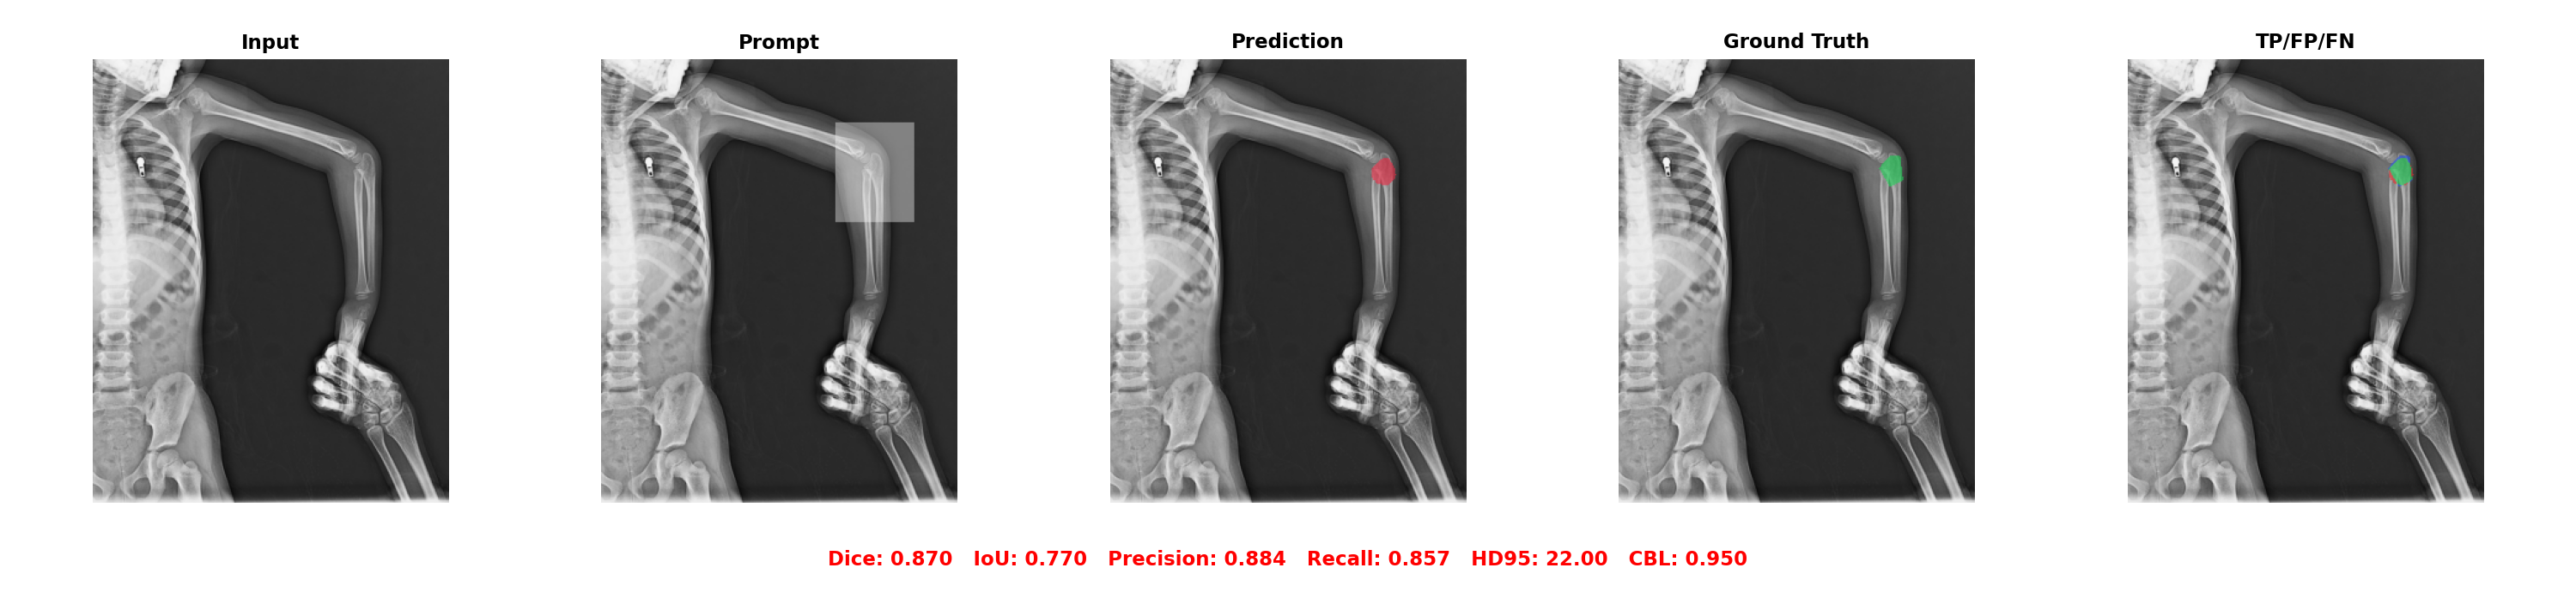

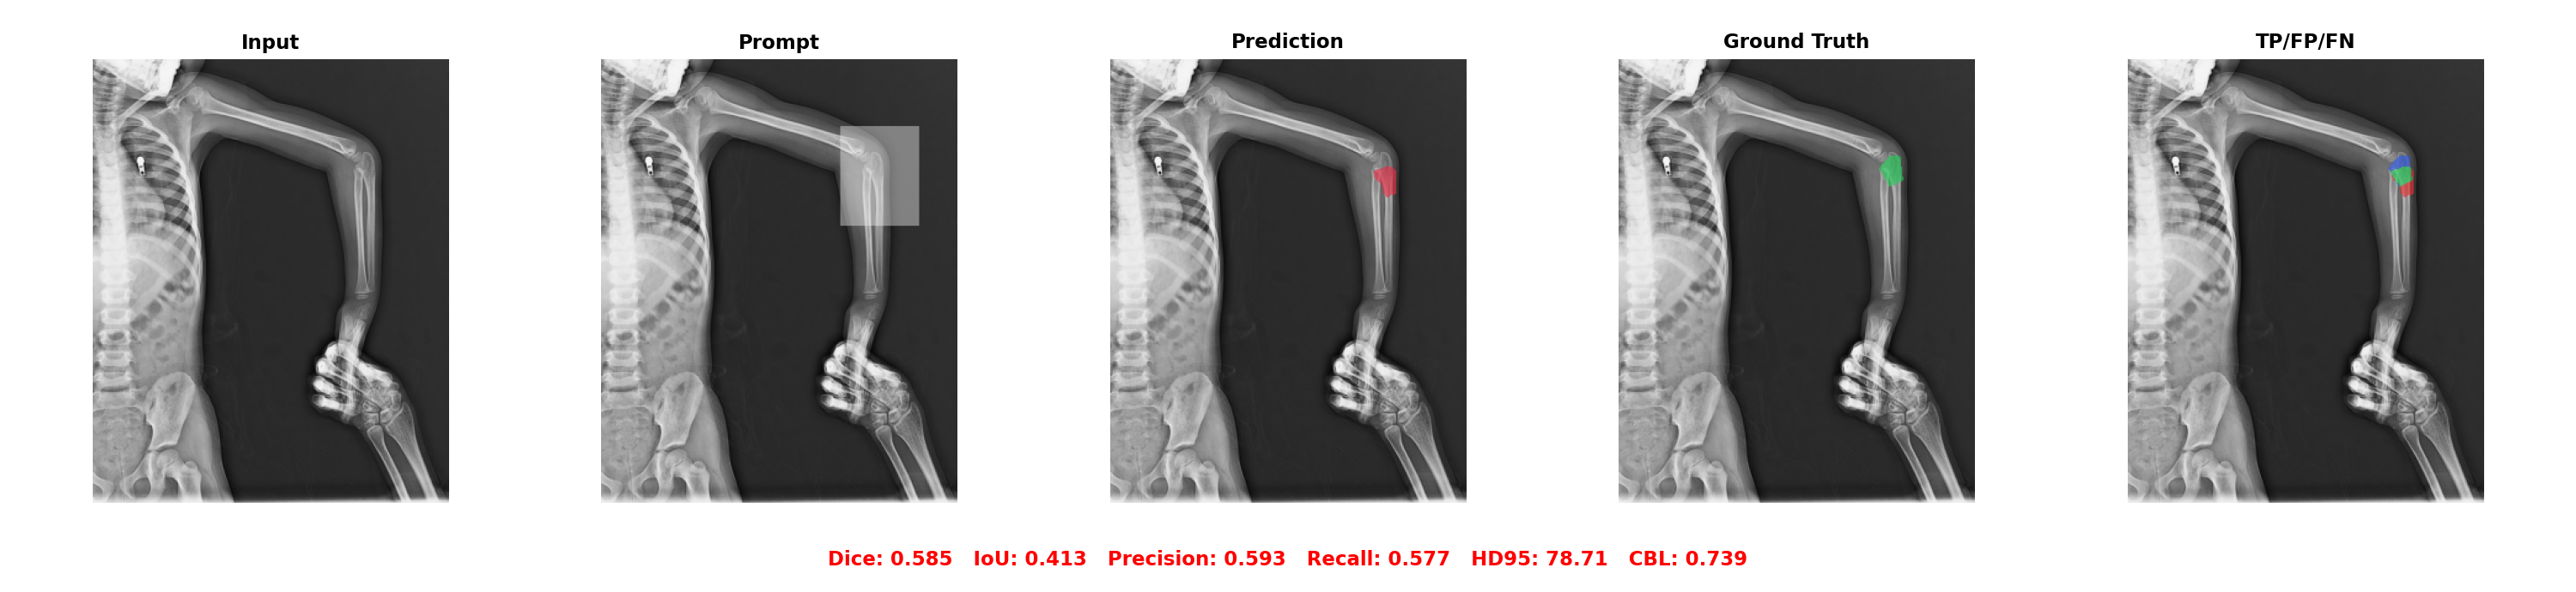

saved scribbleprompt_finetuned_fracatlas_IMG0000144.png


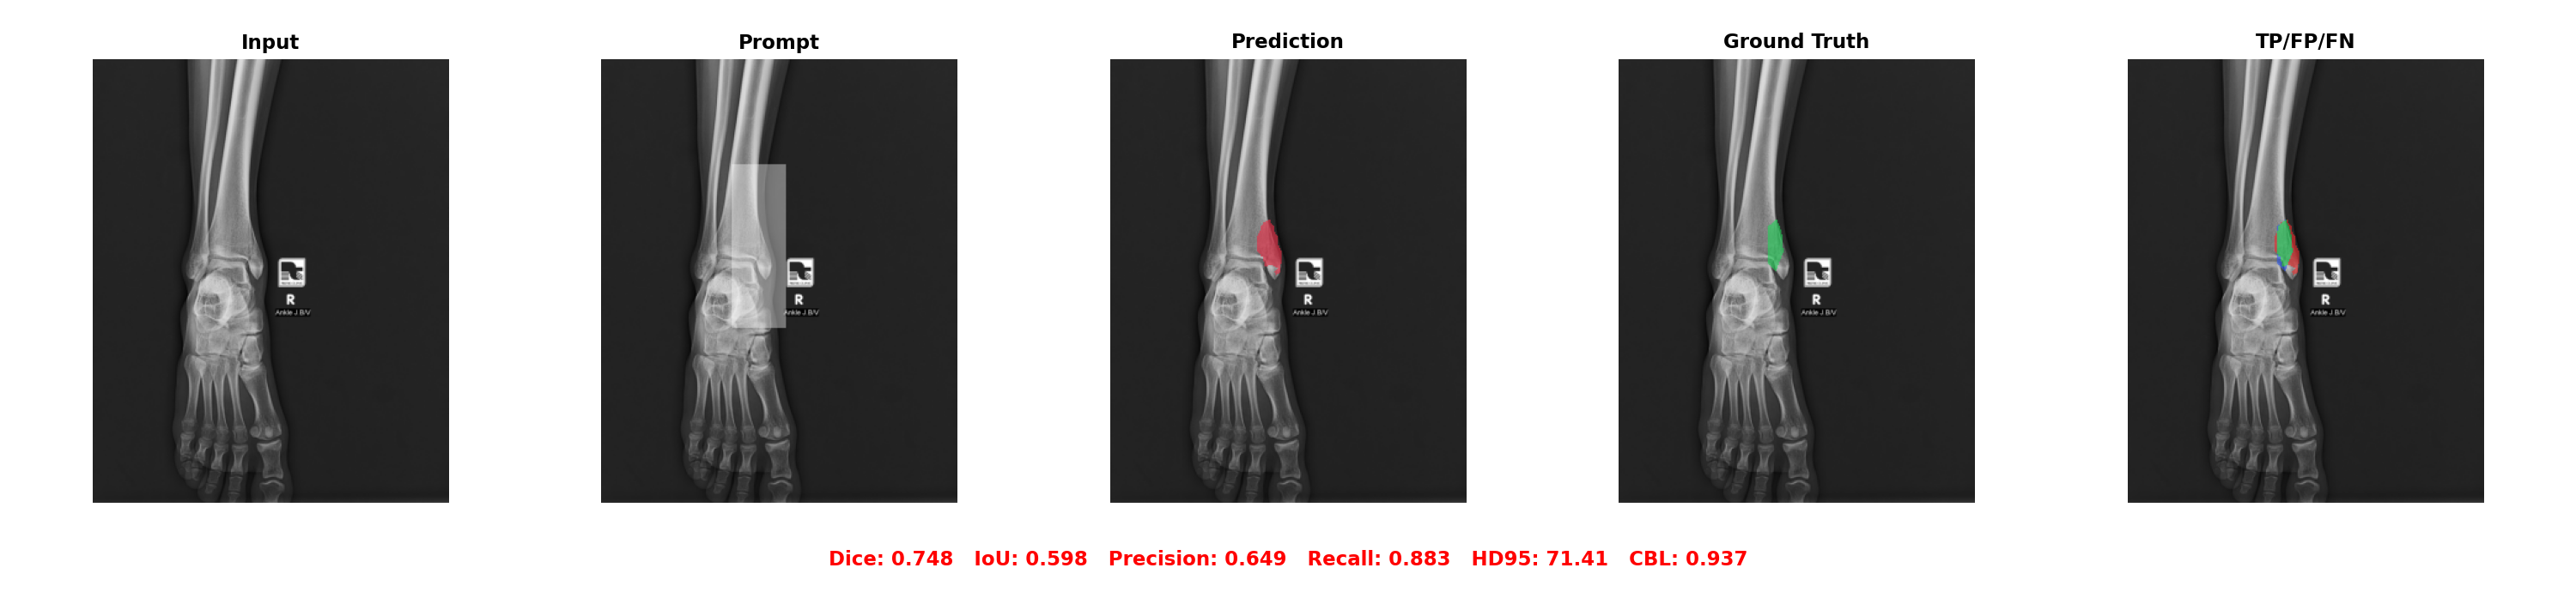

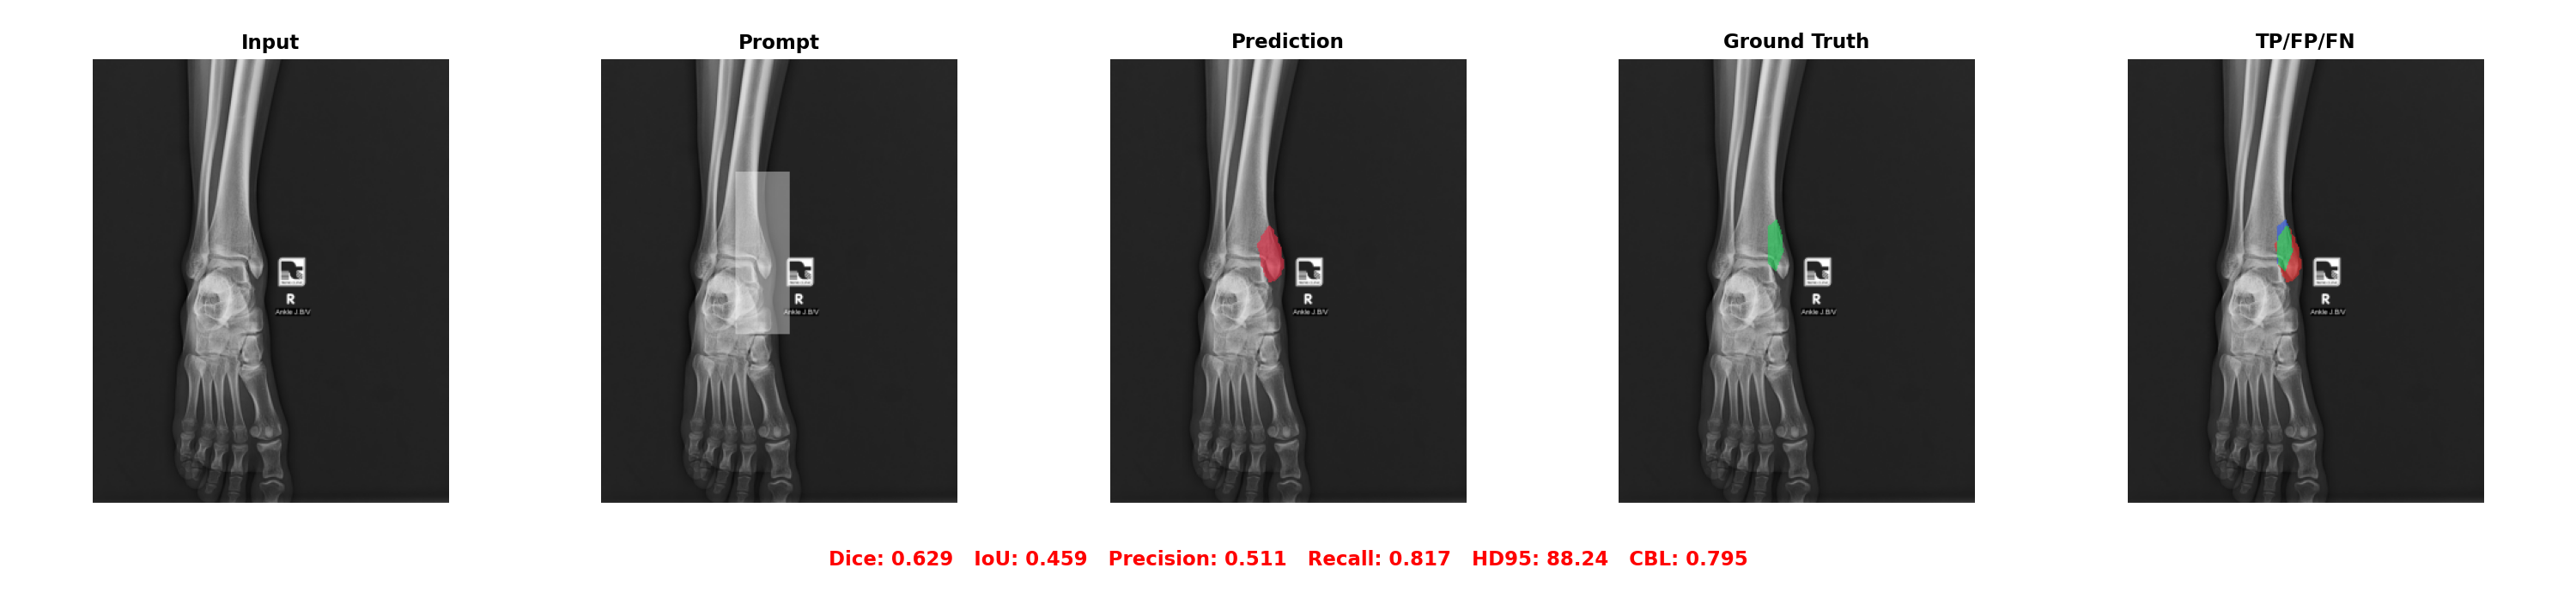

saved scribbleprompt_finetuned_fracatlas_IMG0000151.png


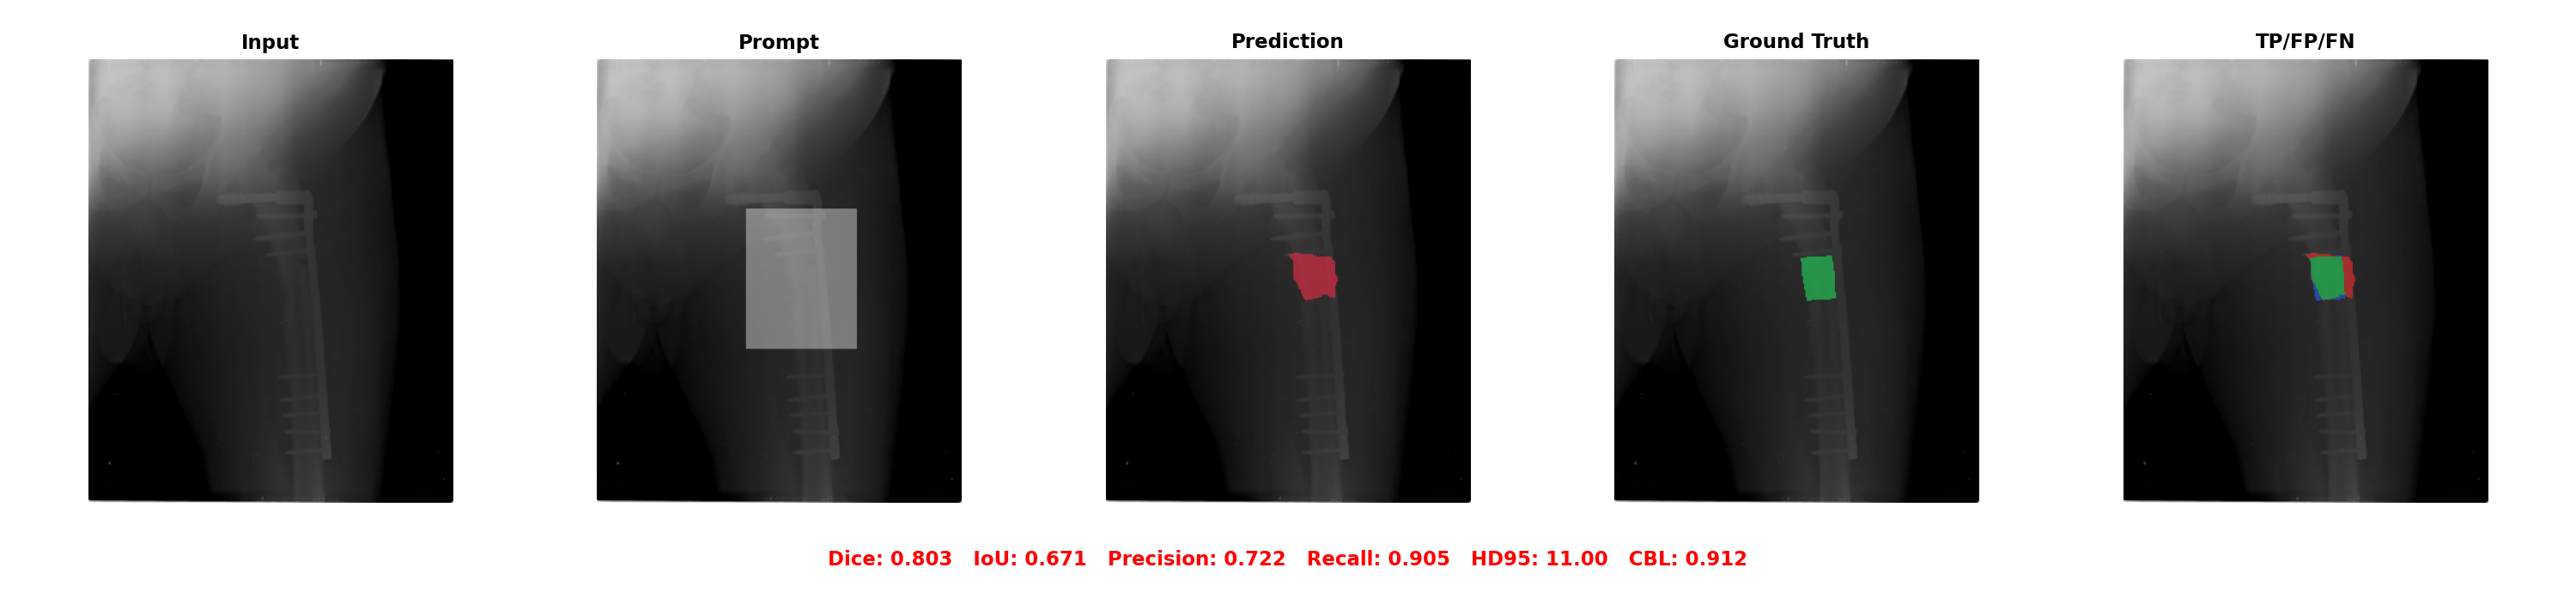

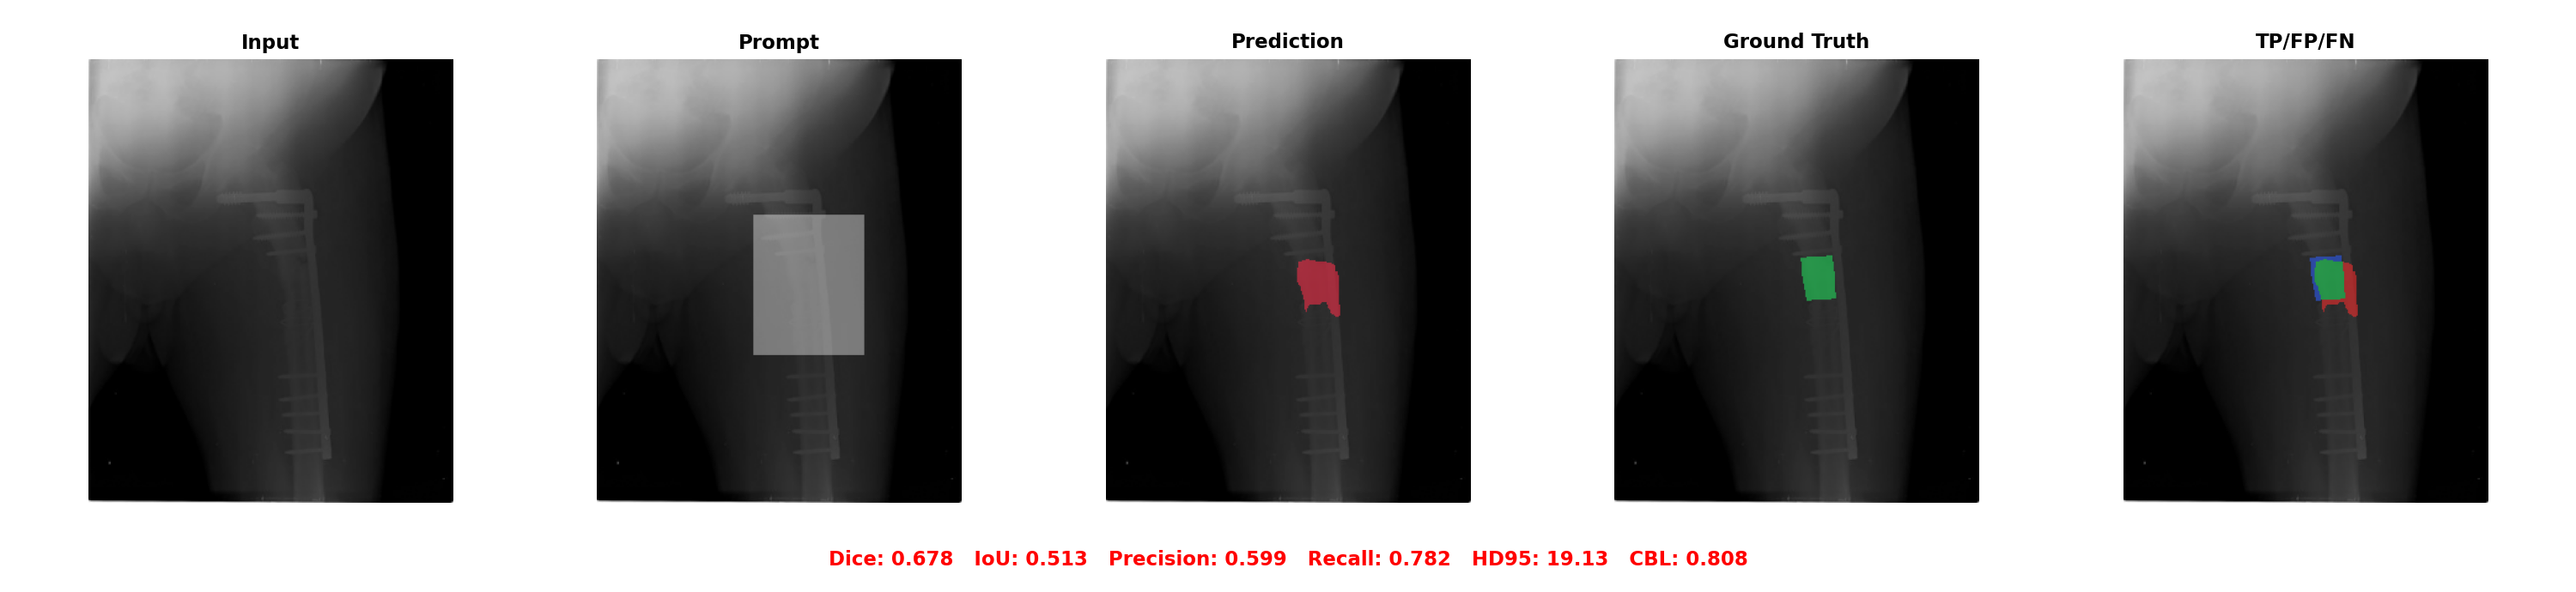

saved scribbleprompt_finetuned_fracatlas_IMG0000453.png


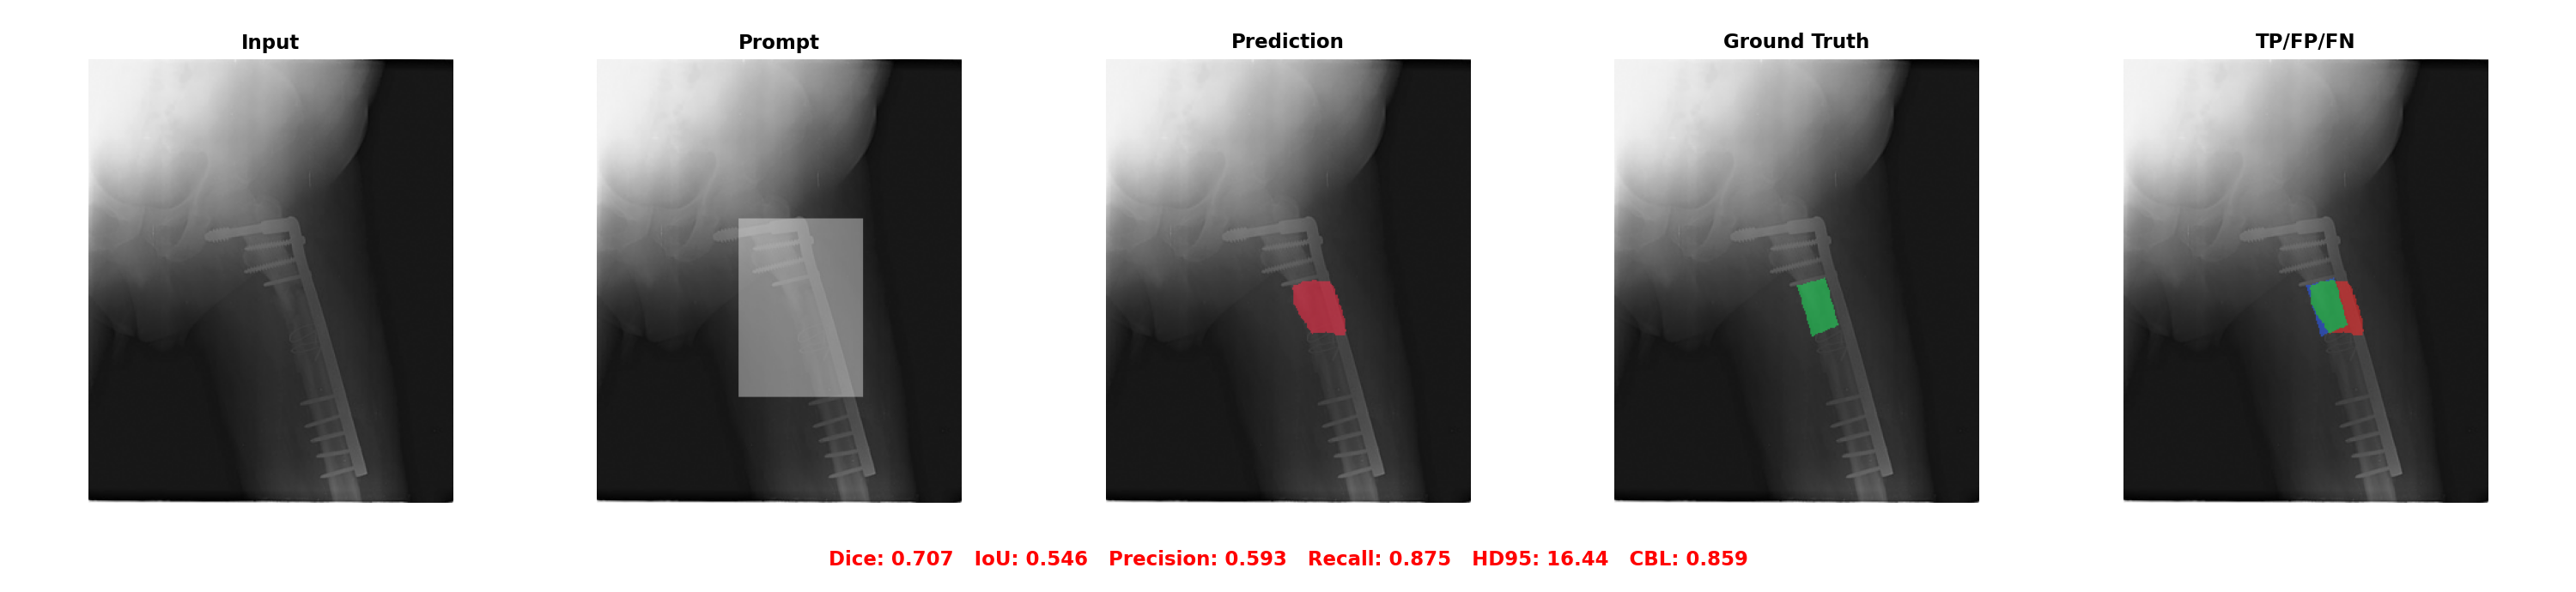

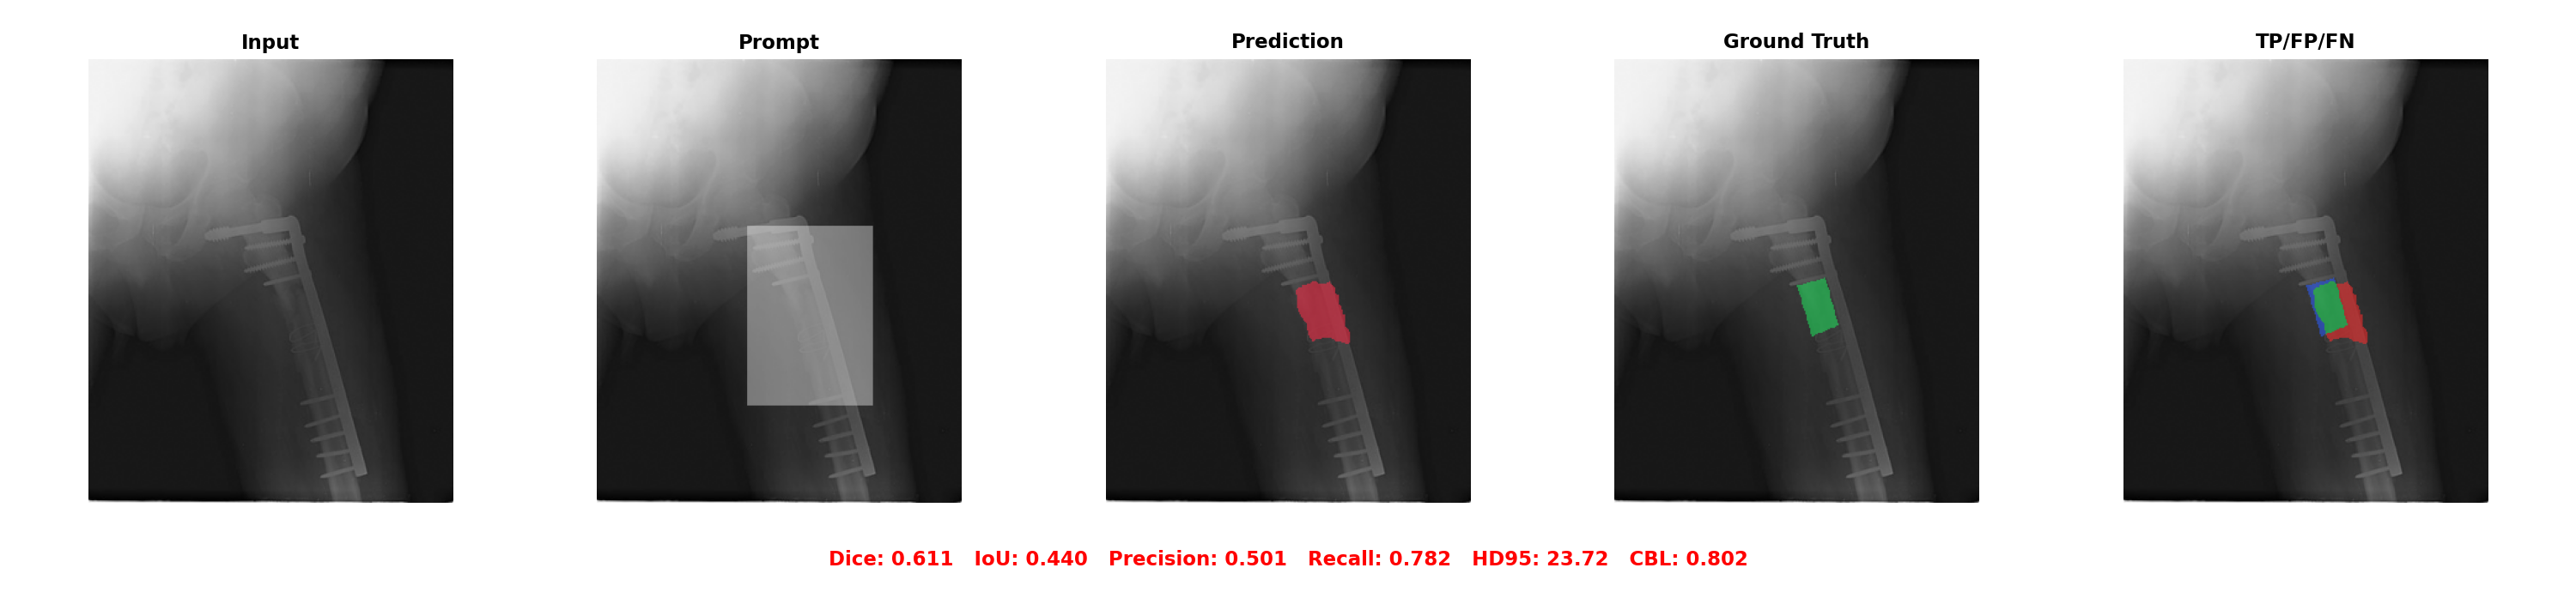

saved scribbleprompt_finetuned_fracatlas_IMG0000454.png


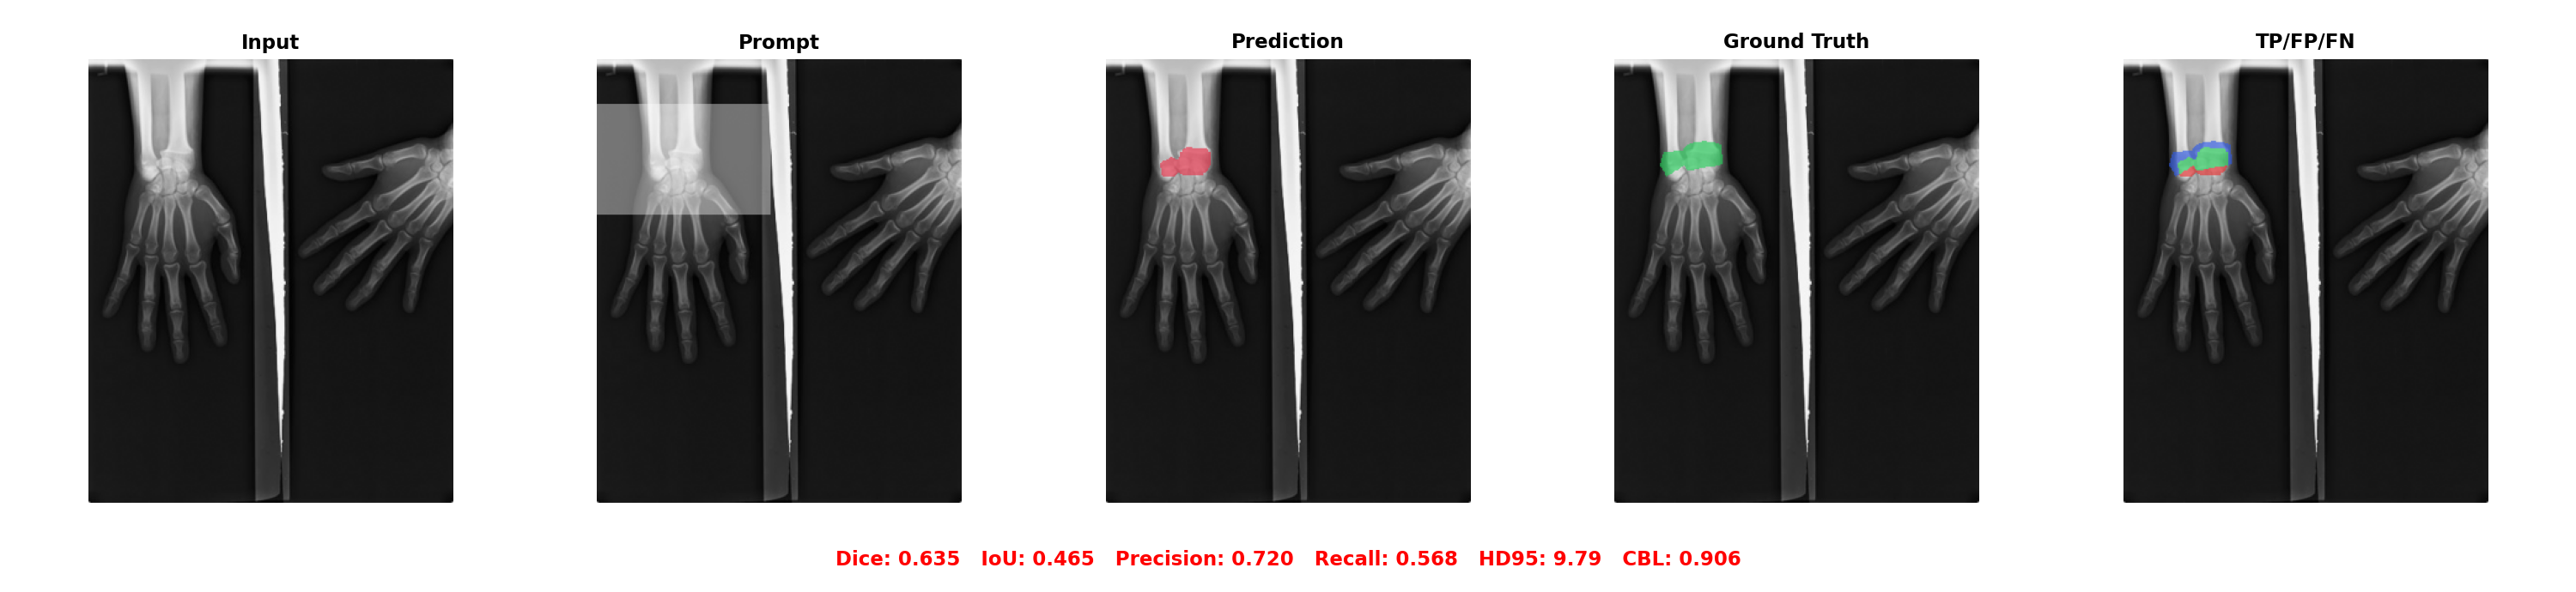

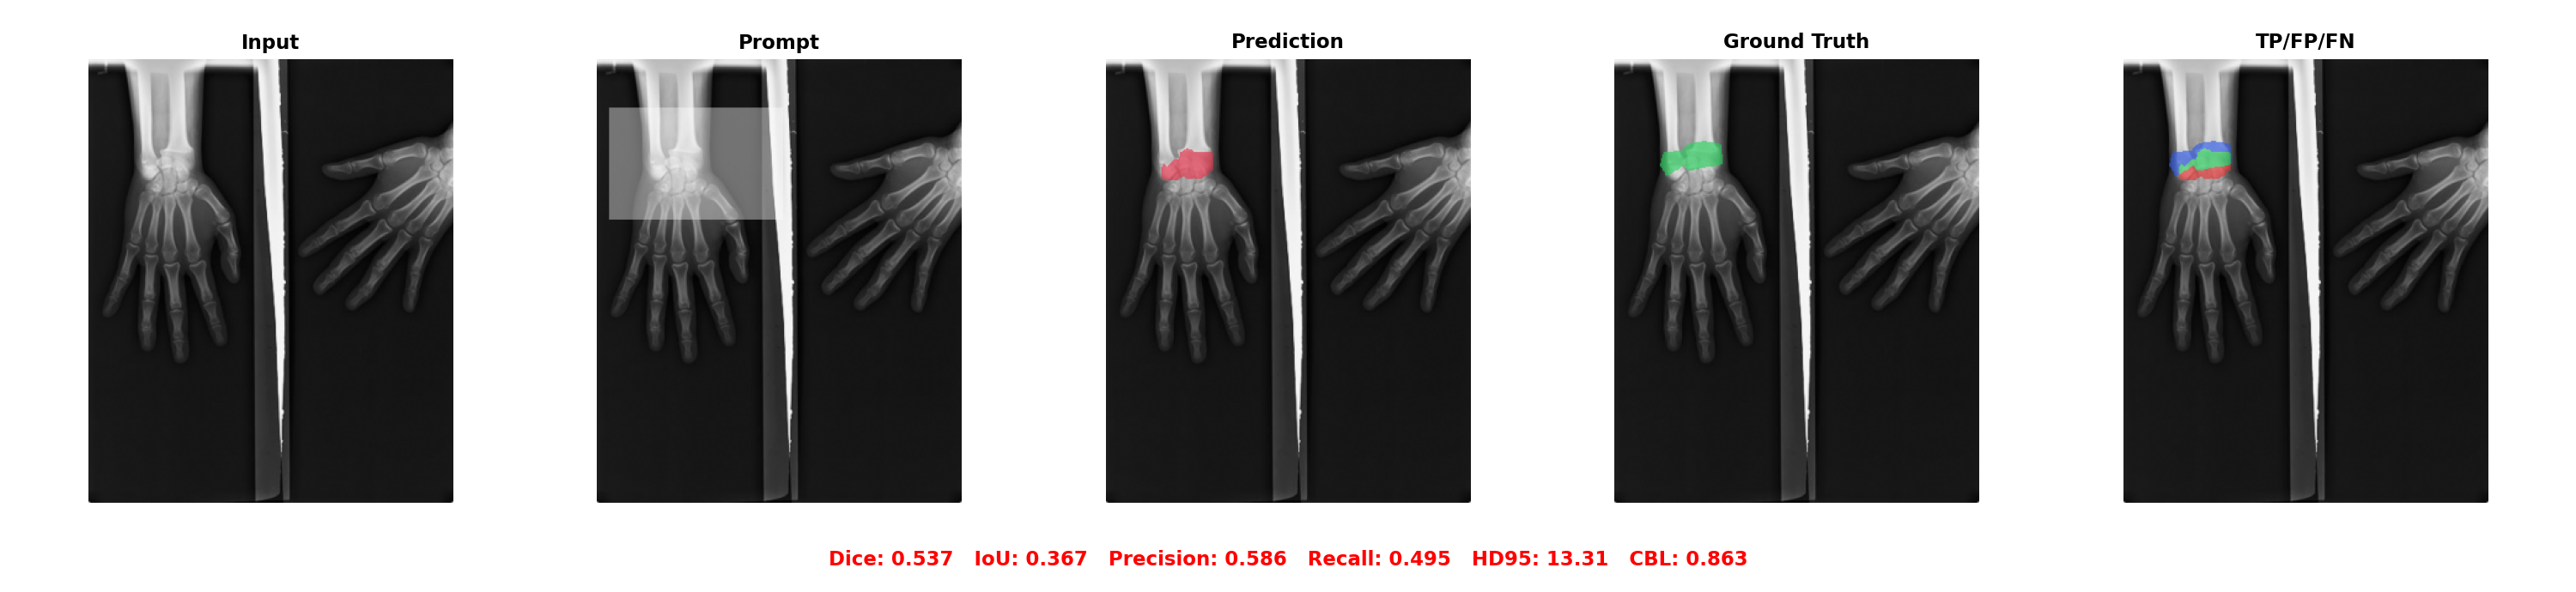

saved scribbleprompt_finetuned_fracatlas_IMG0001123.png


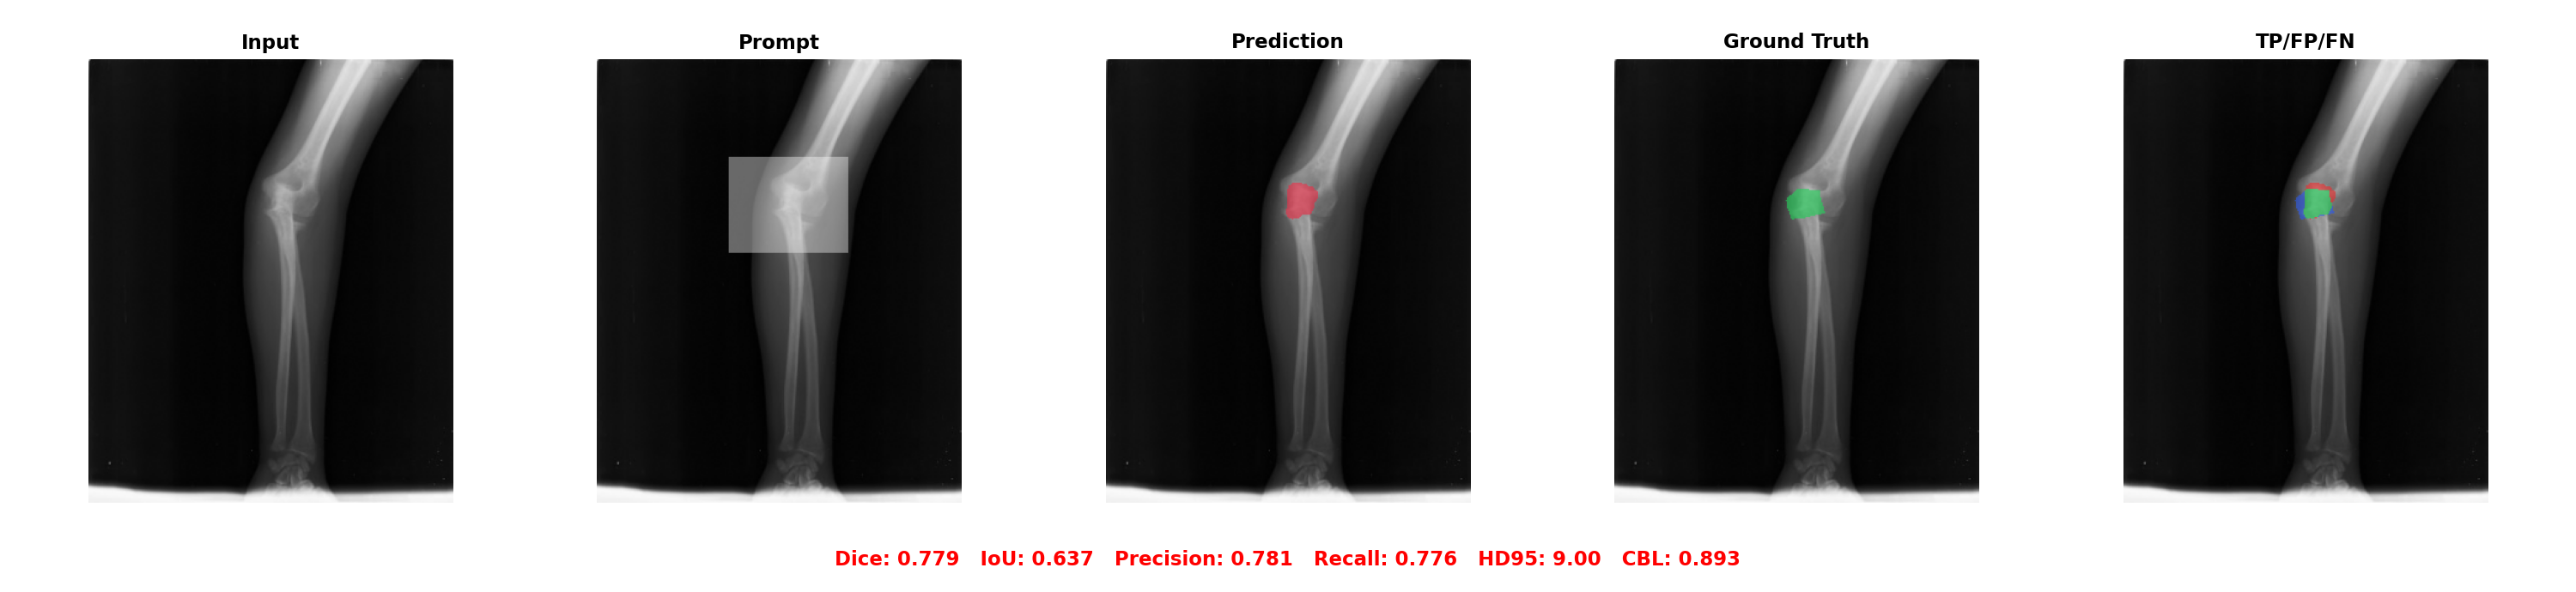

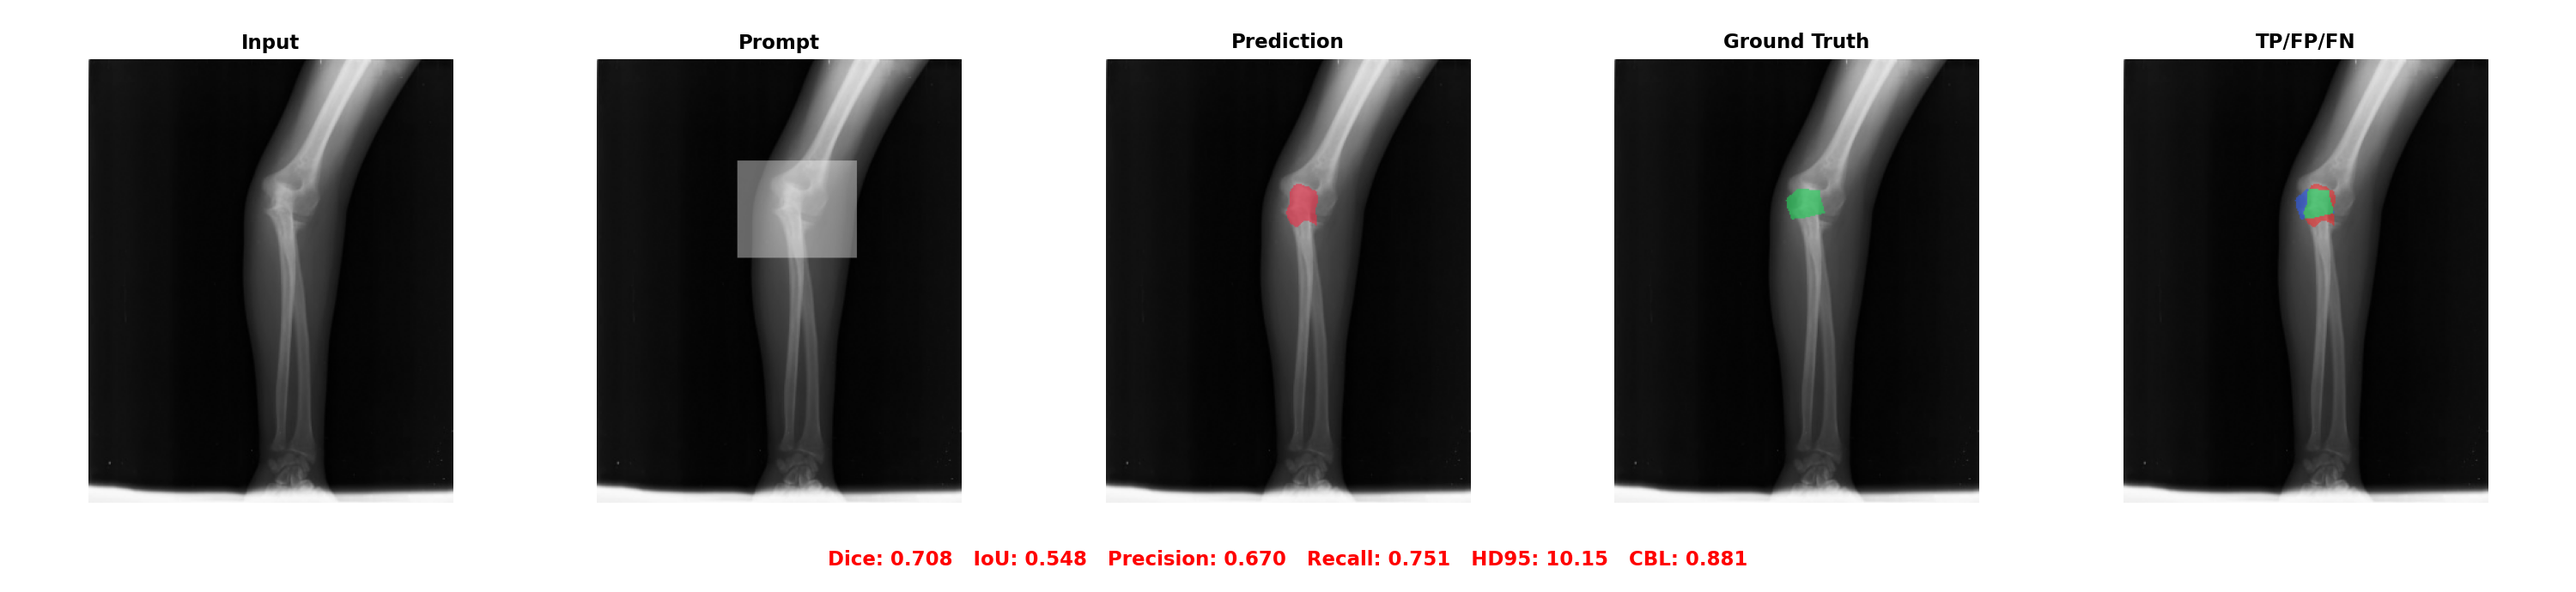

saved scribbleprompt_finetuned_fracatlas_IMG0001360.png


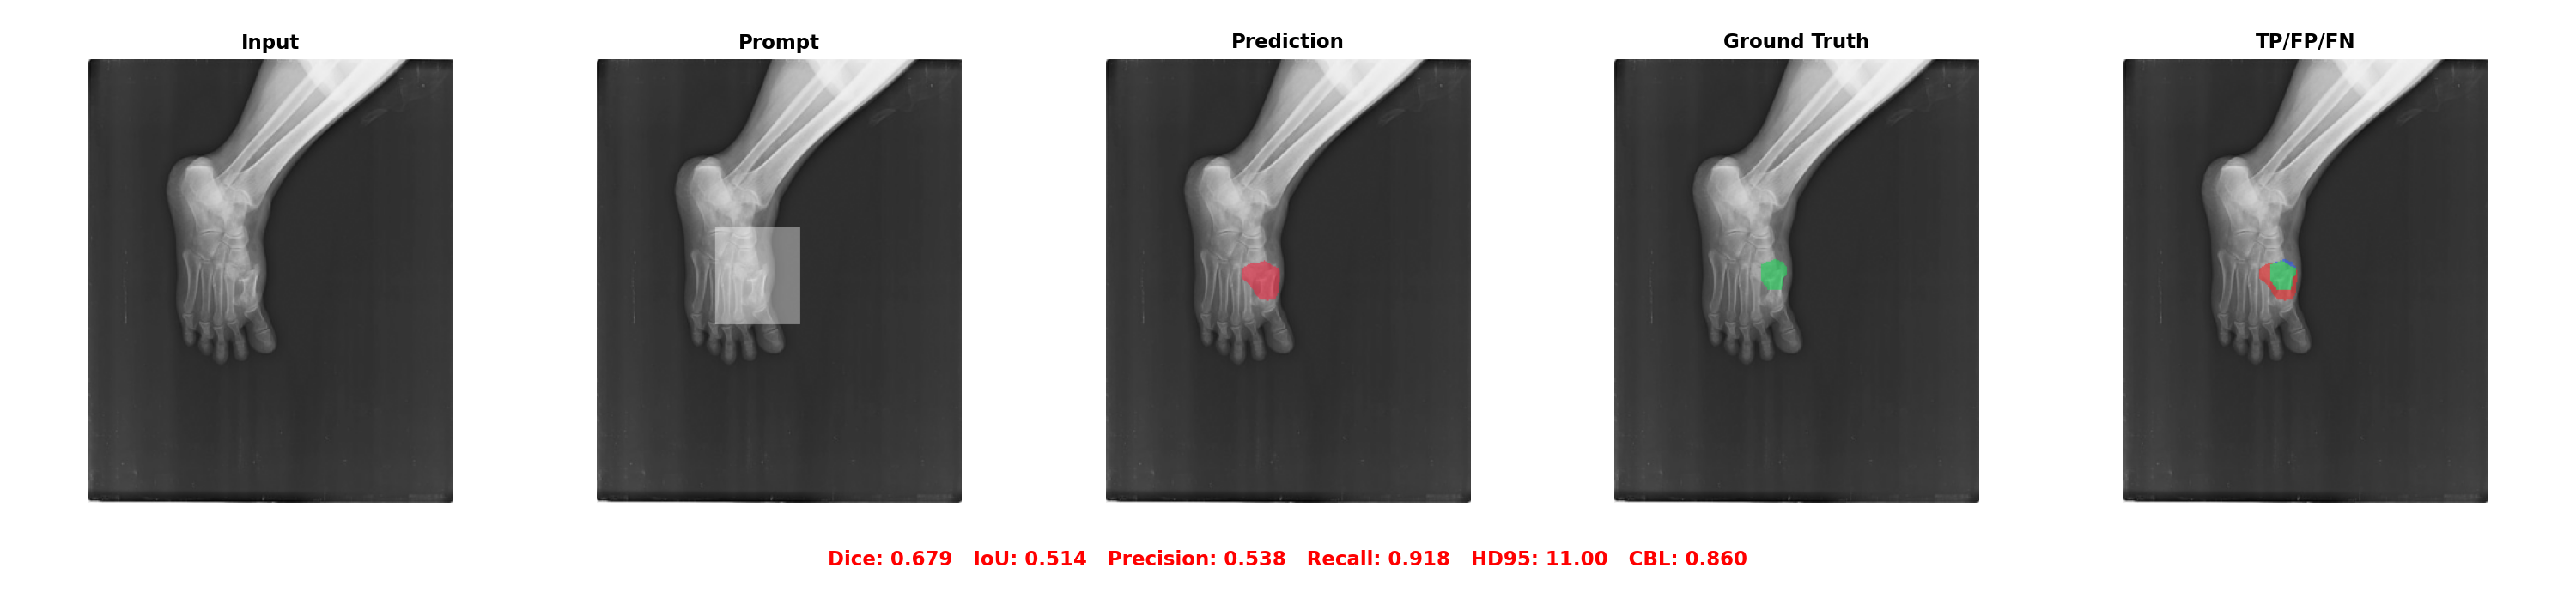

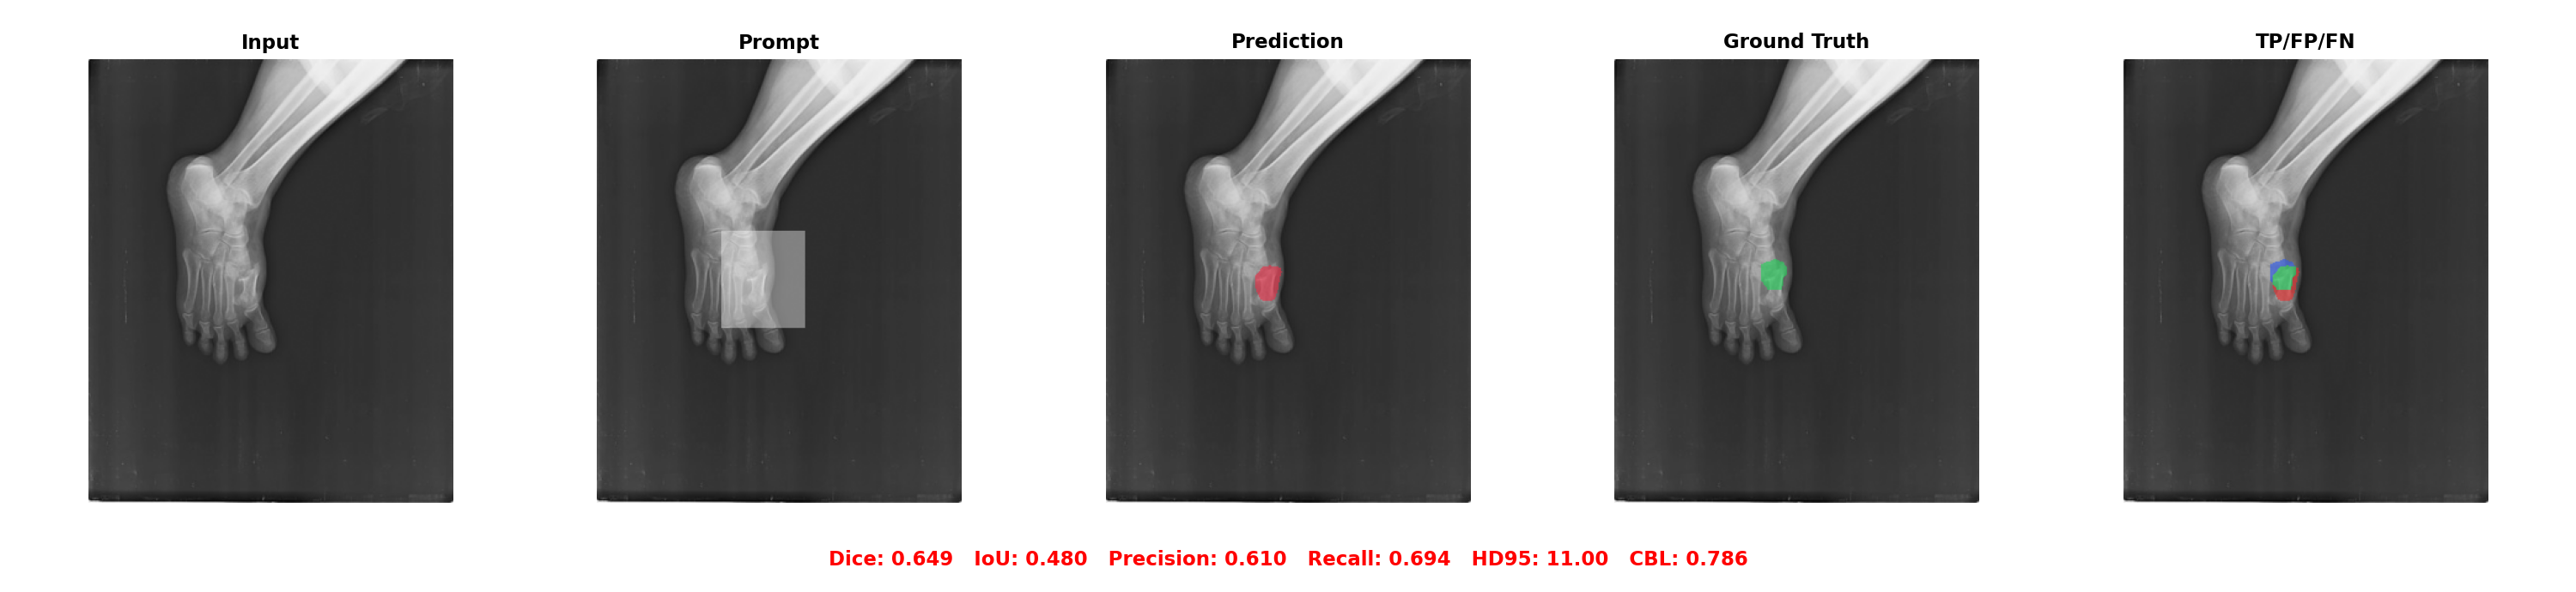

saved scribbleprompt_finetuned_fracatlas_IMG0001980.png


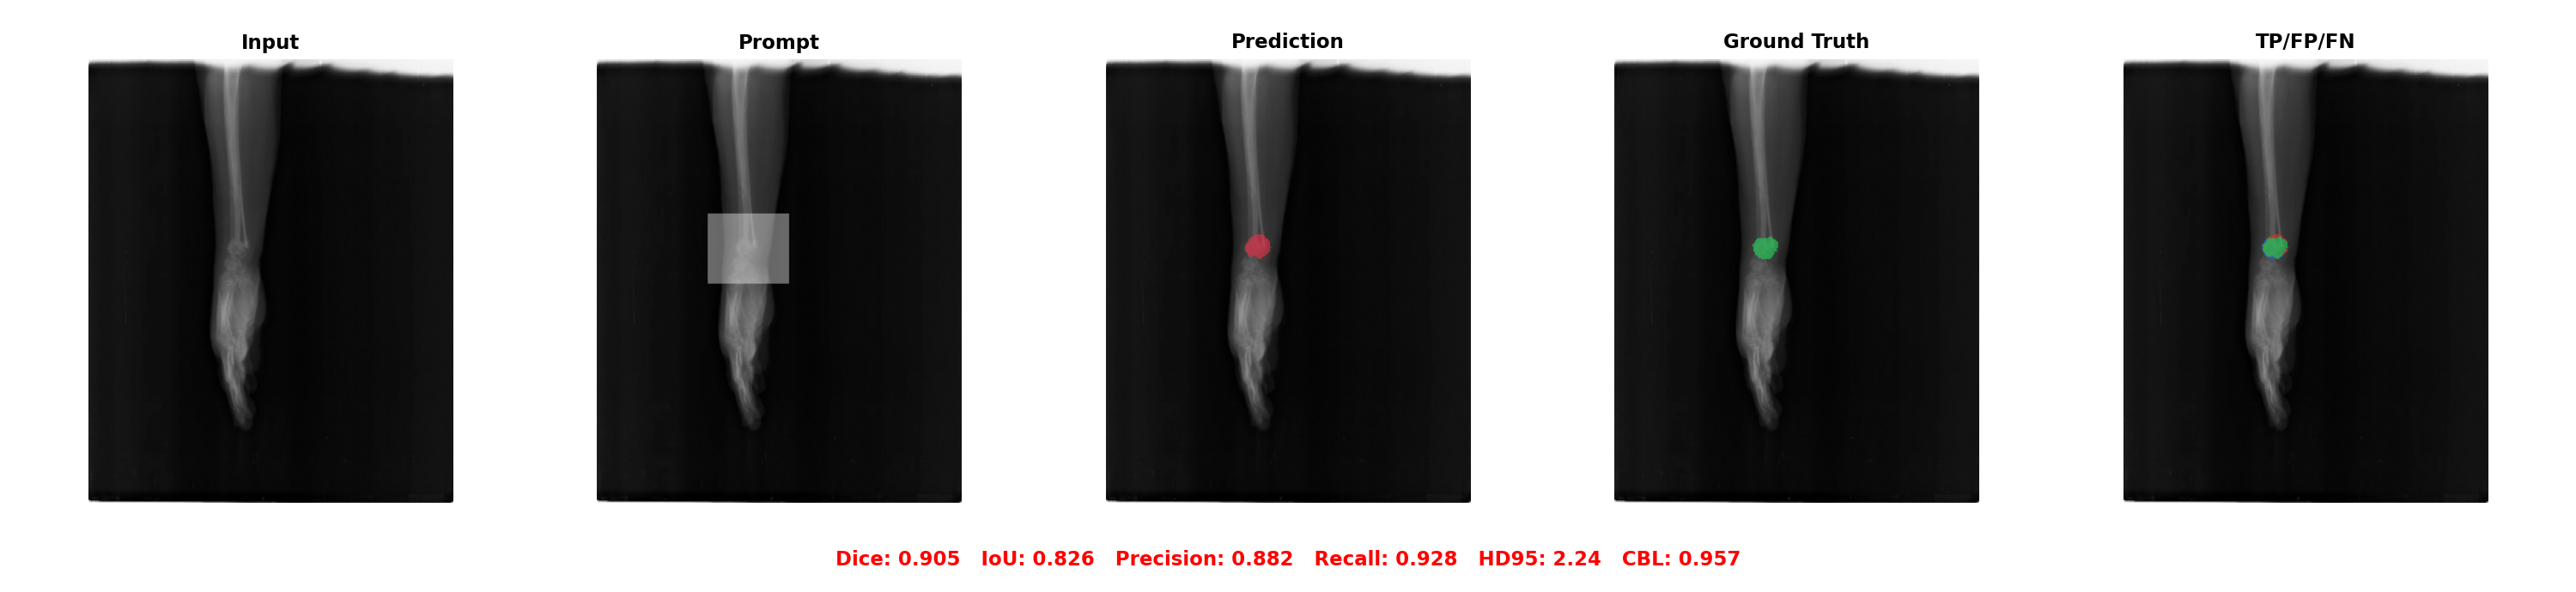

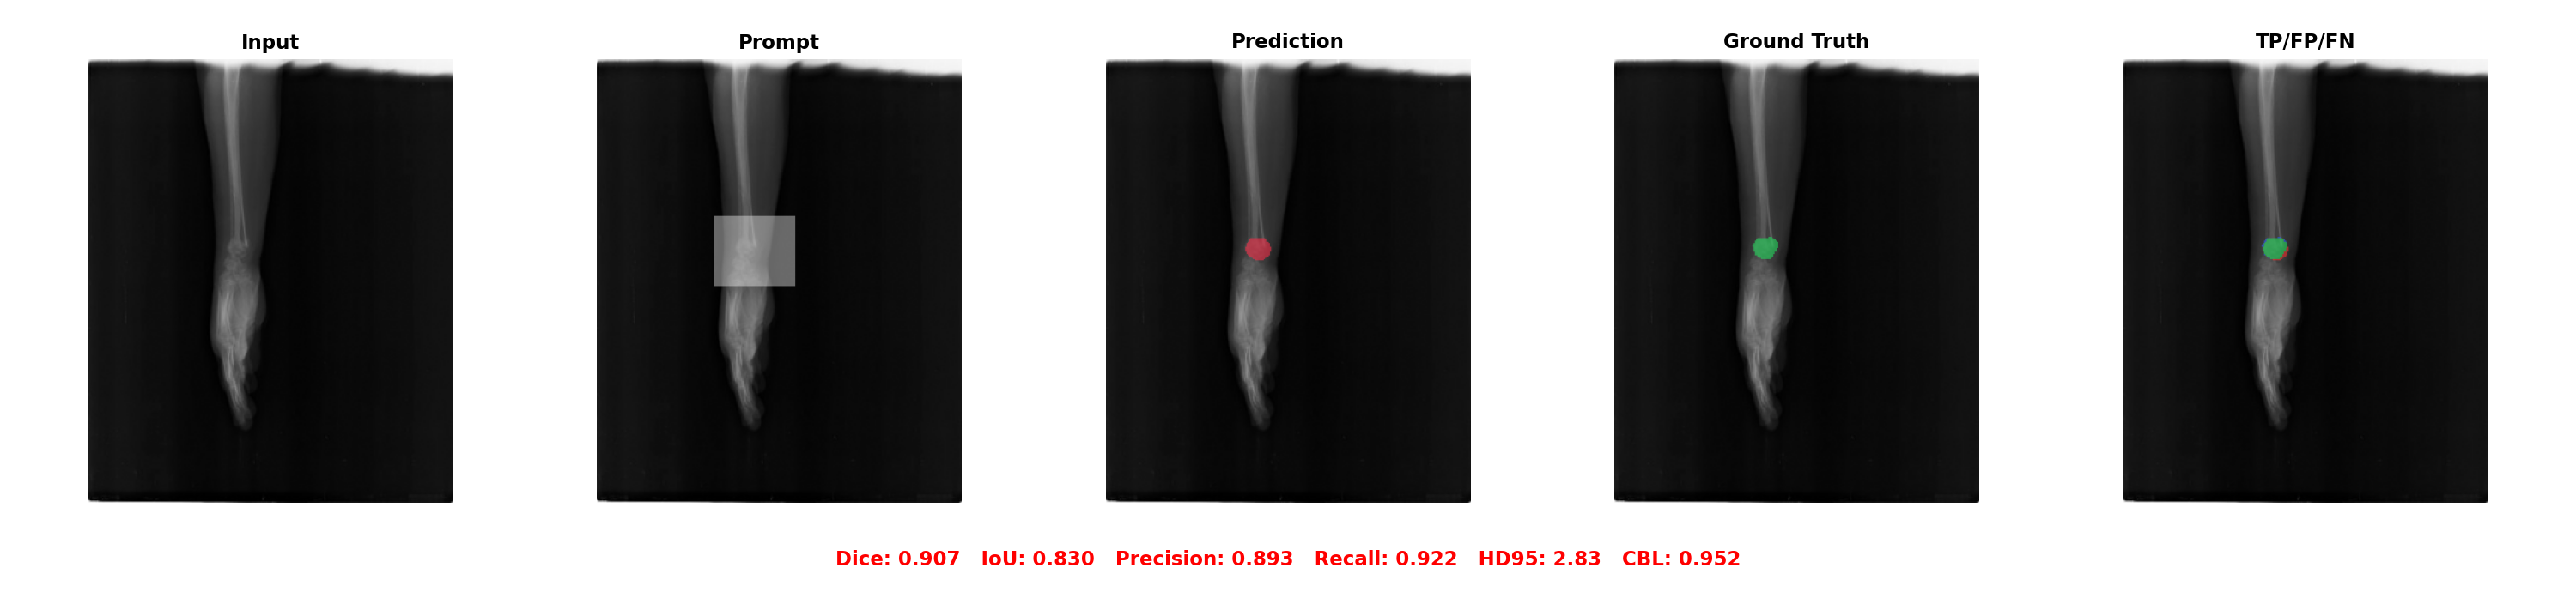

saved scribbleprompt_finetuned_fracatlas_IMG0002021.png


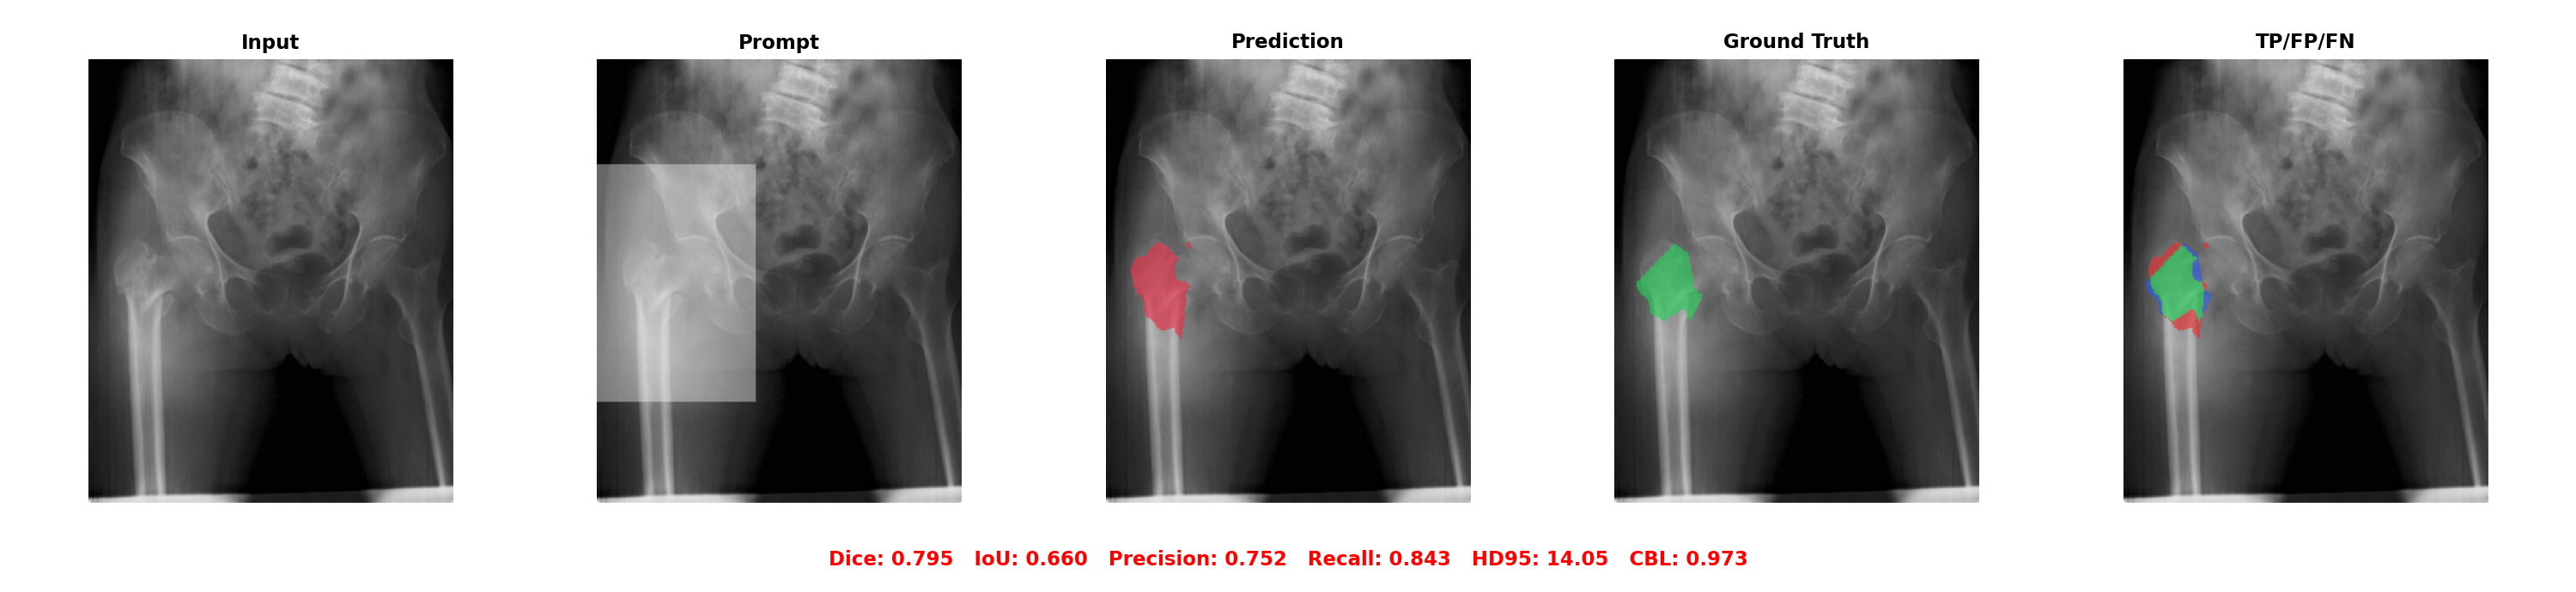

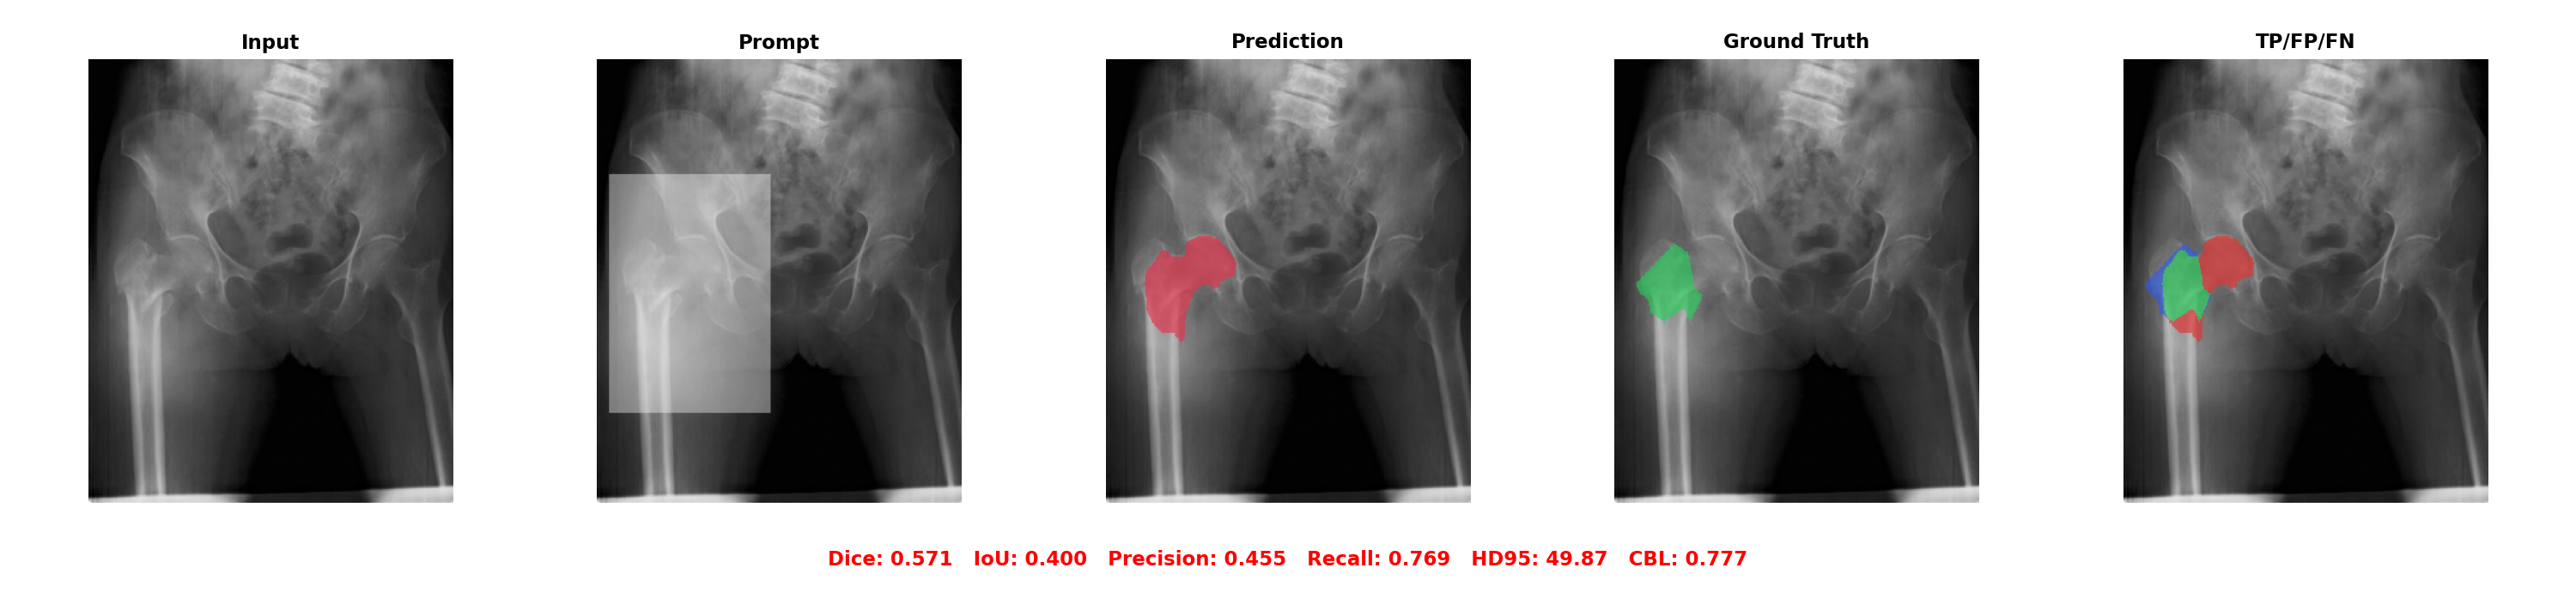

saved scribbleprompt_finetuned_fracatlas_IMG0002180.png


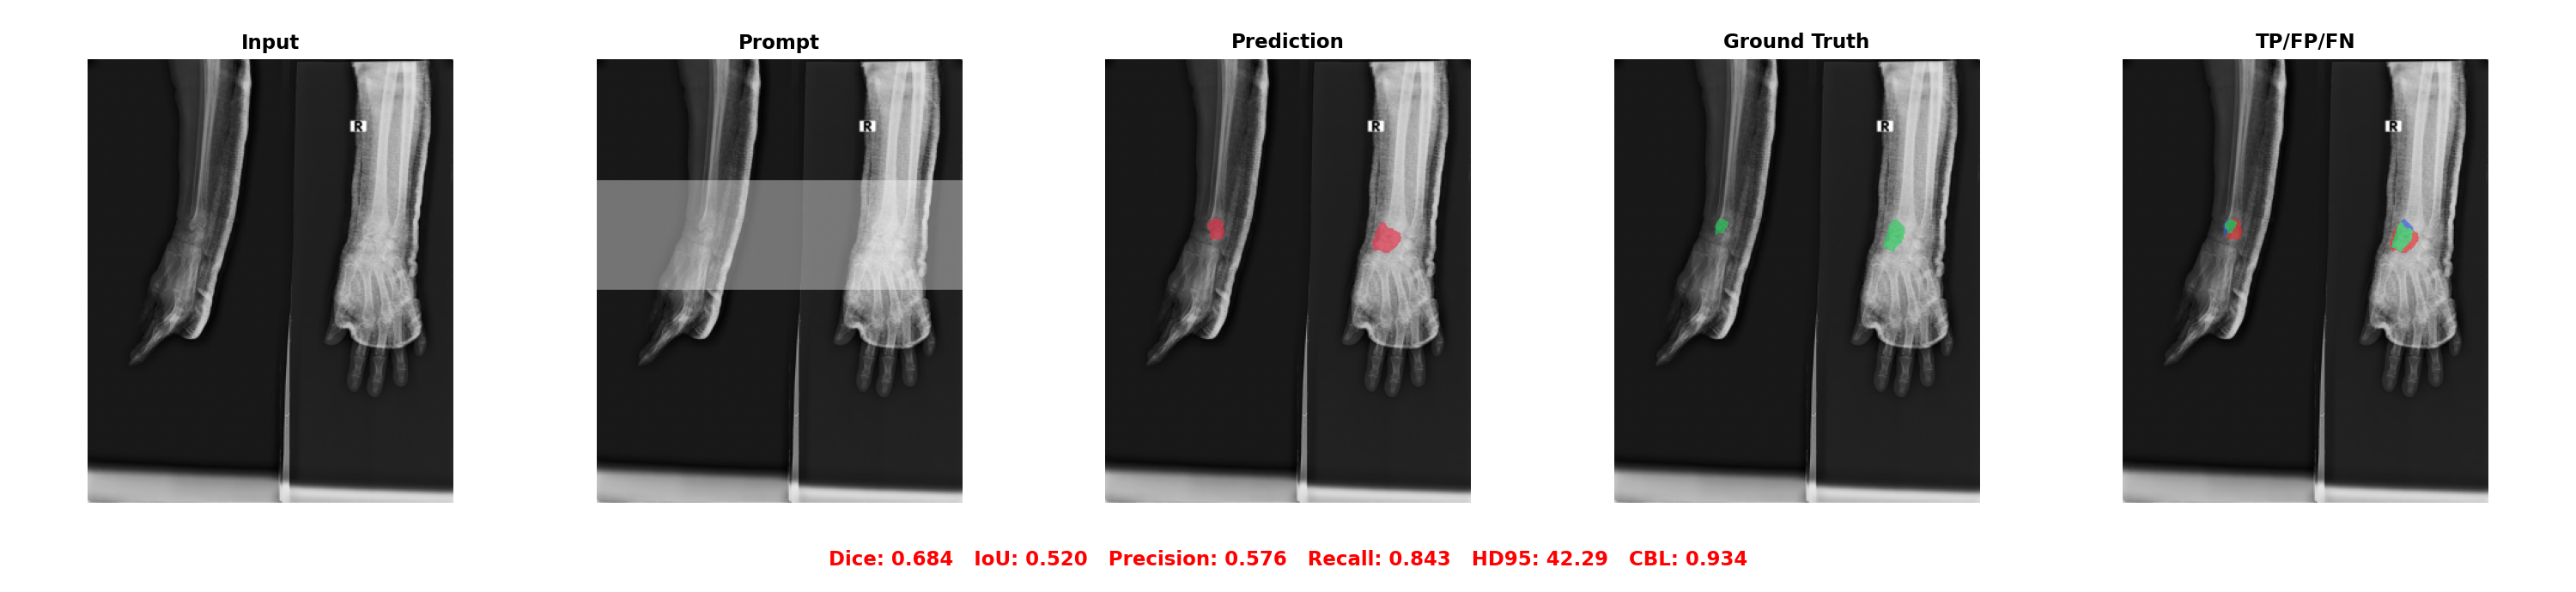

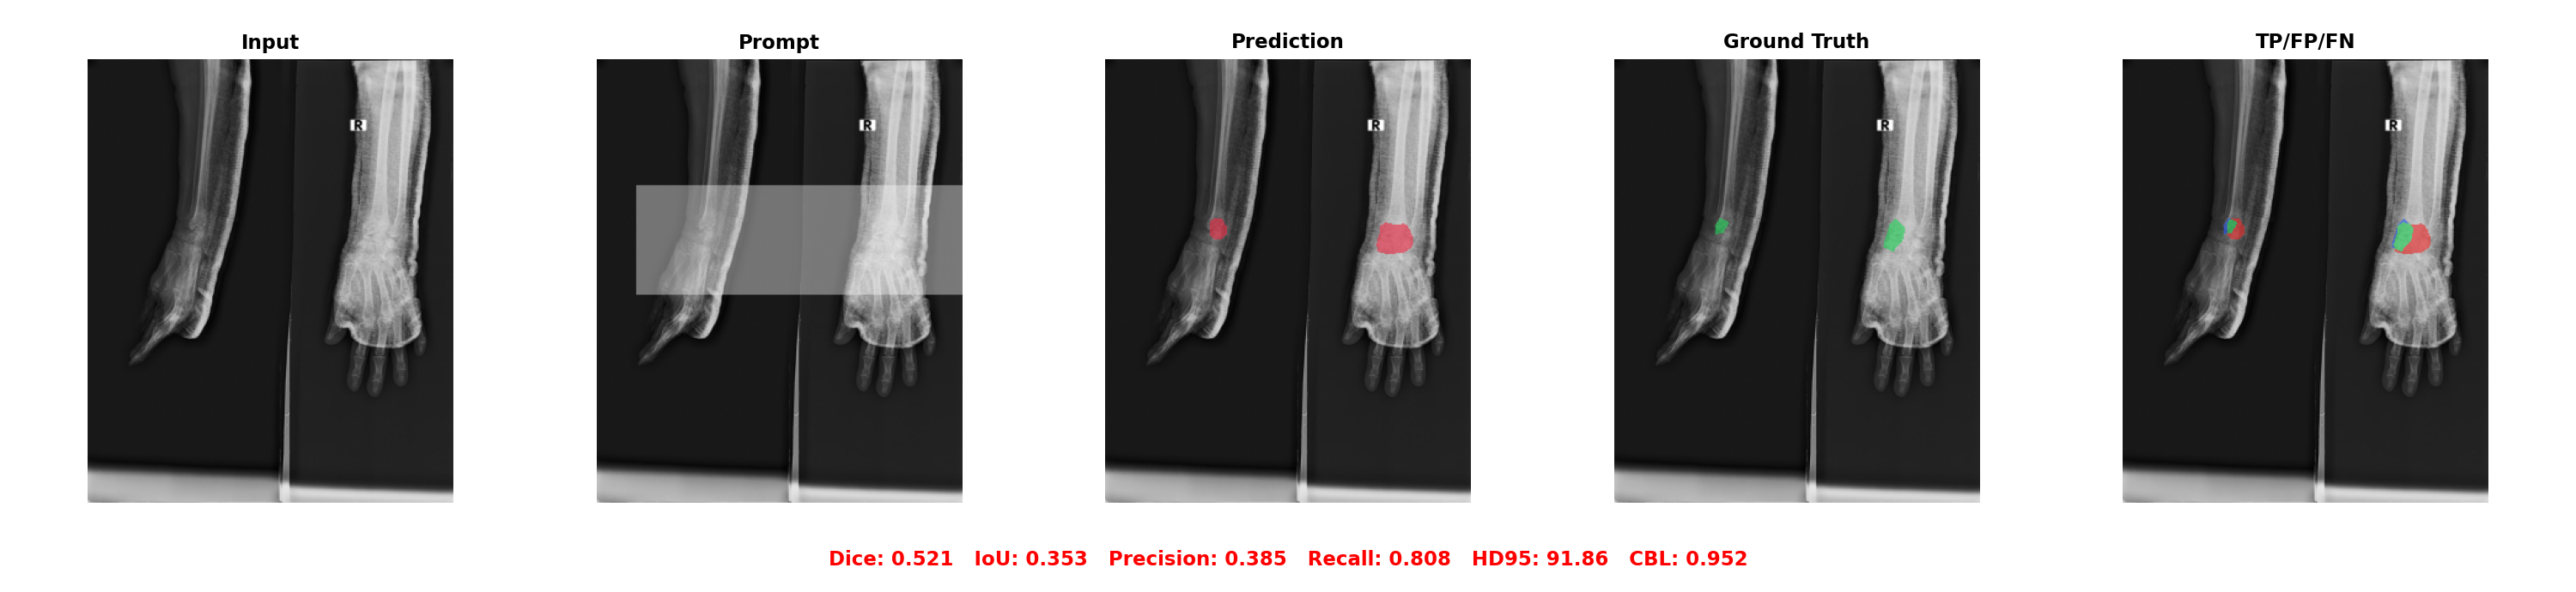

saved scribbleprompt_finetuned_fracatlas_IMG0002300.png


=== Zero-shot vs fine-tuned, side by side ===
covering     zero-shot Dice 0.432  ->  fine-tuned Dice 0.679  (delta +0.247)
off-center   zero-shot Dice 0.431  ->  fine-tuned Dice 0.598  (delta +0.166)


In [6]:
# -- Part B: load best checkpoint, test --
sp_model.model.load_state_dict(torch.load(BEST_CKPT_PATH, map_location=DEVICE, weights_only=True))
sp_model.model.eval()
rows_finetuned, images_finetuned = run_test('fine-tuned')

# -- Qualitative figures (10 shared stems, same style as Finetune_SAMMed2D_test_robust.ipynb) --
visualize_qualitative(images_finetuned, TEST_IMG, box_ds, 'ScribblePrompt-UNet (fine-tuned)',
                      f'scribbleprompt_finetuned_{DS_NAME.lower()}')

print('\n\n=== Zero-shot vs fine-tuned, side by side ===')
for rz, rf in zip(rows_zeroshot, rows_finetuned):
    assert rz['prompt'] == rf['prompt']
    print(f"{rz['prompt']:<12} zero-shot Dice {rz['dice']:.3f}  ->  fine-tuned Dice {rf['dice']:.3f}"
          f"  (delta {rf['dice']-rz['dice']:+.3f})")